In [ ]:
# Install required libraries (already done, but rerun for confirmation)
!pip install -q transformers>=4.35.0 pandas scikit-learn numpy matplotlib seaborn torch>=2.0.0
print("Dependencies installed successfully!")
# Import libraries for dataset preparation
import pandas as pd
import numpy as np

Dependencies installed successfully!


In [ ]:
# Mount Google Drive to save data and model
from google.colab import drive
drive.mount('/content/drive')

# Set working directory in Google Drive
import os
os.makedirs('/content/drive/MyDrive/MentalBERT_Project', exist_ok=True)
os.chdir('/content/drive/MyDrive/MentalBERT_Project')
print("Working directory set to /content/drive/MyDrive/MentalBERT_Project")

Mounted at /content/drive
Working directory set to /content/drive/MyDrive/MentalBERT_Project


In [ ]:
# Import libraries for dataset preparation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load and combine data from CSV files
files = {
    "depressed_mood_10K_v1.csv": [1, 0, 0, 0, 0],  # Depressive mood
    "insomnia_10K_v1.csv": [0, 1, 0, 0, 0],       # Insomnia
    "anhedonia_10K_v1.csv": [0, 0, 1, 0, 0],      # Anhedonia
    "guilt_10K_v1.csv": [0, 0, 0, 1, 0],          # Guilt
    "suicidal_ideation_10K_v1.csv": [0, 0, 0, 0, 1] # Suicidal ideation
}
symptoms = ["Depressive Mood", "Insomnia", "Anhedonia", "Guilt", "Suicidal Ideation"]

data = []
for file, label in files.items():
    df = pd.read_csv(f"/content/drive/MyDrive/MentalBERT_Project/data/{file}")
    for _, row in df.iterrows():
        text = (row["title"] + " " + (row["selftext"] or "")).strip()
        data.append({
            "text": text,
            "labels": label
        })

# Convert to DataFrame
df_all = pd.DataFrame(data)
texts = df_all["text"].tolist()
labels = np.array(df_all["labels"].tolist(), dtype=np.float32)

# Split into train (70%), validation (15%), test (15%) with stratification
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, stratify=labels, random_state=42
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"Dataset sizes: Train={len(train_texts)}, Val={len(val_texts)}, Test={len(test_texts)}")
print("Dataset preparation completed!")

Dataset sizes: Train=35000, Val=7500, Test=7500
Dataset preparation completed!


In [ ]:
# Import libraries for tokenization
import torch
from transformers import BertTokenizer
from huggingface_hub import login

# Log in to Hugging Face for gated repo access
login(new_session=False)  # Enter your Hugging Face token when prompted

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("mental/mental-bert-base-uncased")

# Tokenize function
def tokenize_data(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

# Tokenize datasets
train_encodings = tokenize_data(train_texts)
val_encodings = tokenize_data(val_texts)
test_encodings = tokenize_data(test_texts)

# Create PyTorch dataset
class RedditDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

train_dataset = RedditDataset(train_encodings, train_labels)
val_dataset = RedditDataset(val_encodings, val_labels)
test_dataset = RedditDataset(test_encodings, test_labels)

print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")
print("Tokenization completed!")

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Dataset sizes: Train=35000, Val=7500, Test=7500
Tokenization completed!


In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import precision_recall_fscore_support
import torch

# Define the base directory
base_dir = "/content/drive/MyDrive/MentalBERT_Project"

# Load the best model (CLF LR=5e-4, checkpoint-4376 - Epoch 2)
best_model_path = "/content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_clf_lr_0.0005/checkpoint-4376"
print(f"Loading best model from: {best_model_path}")

best_model = BertForSequenceClassification.from_pretrained(best_model_path)

# Setup trainer for evaluation
training_args = TrainingArguments(
    output_dir=f"{base_dir}/test_evaluation",
    per_device_eval_batch_size=16,
    report_to="none"
)

trainer = Trainer(
    model=best_model,
    args=training_args
)

# Evaluate on test set
print("\nEvaluating on test set...")
test_predictions = trainer.predict(test_dataset)
test_pred_probs = torch.sigmoid(torch.tensor(test_predictions.predictions)).numpy()
test_pred_labels = (test_pred_probs >= 0.5).astype(int)

# Get true labels
test_labels = np.array([item['labels'] for item in test_dataset])

# Define symptom names
symptoms = ["Depressive Mood", "Insomnia", "Anhedonia", "Guilt", "Suicidal Ideation"]

# Calculate per-symptom metrics
results_data = []

print("\n" + "="*80)
print("Per-Symptom Performance:")
print("="*80)

for i, symptom in enumerate(symptoms):
    y_true = test_labels[:, i]
    y_pred = test_pred_labels[:, i]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1
    )

    support = int(y_true.sum())

    results_data.append({
        'Symptom': symptom,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': support
    })

    print(f"{symptom:20s}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}, Support={support}")

# Calculate macro average
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    test_labels, test_pred_labels, average='macro'
)

results_data.append({
    'Symptom': '―' * 20,  # Separator
    'Precision': np.nan,
    'Recall': np.nan,
    'F1-Score': np.nan,
    'Support': ''
})

results_data.append({
    'Symptom': 'Macro Average',
    'Precision': macro_precision,
    'Recall': macro_recall,
    'F1-Score': macro_f1,
    'Support': len(test_labels)
})

# Calculate micro average
micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
    test_labels, test_pred_labels, average='micro'
)

results_data.append({
    'Symptom': 'Micro Average',
    'Precision': micro_precision,
    'Recall': micro_recall,
    'F1-Score': micro_f1,
    'Support': len(test_labels)
})

print("="*80)
print(f"Macro Average: Precision={macro_precision:.3f}, Recall={macro_recall:.3f}, F1={macro_f1:.3f}")
print(f"Micro Average: Precision={micro_precision:.3f}, Recall={micro_recall:.3f}, F1={micro_f1:.3f}")
print("="*80)

# Create DataFrame
df_results = pd.DataFrame(results_data)

# Save raw data
df_results.to_csv(f"{base_dir}/table1_test_performance_raw.csv", index=False)

# Create formatted version for paper
df_results_formatted = df_results.copy()
df_results_formatted['Precision'] = df_results_formatted['Precision'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else ''
)
df_results_formatted['Recall'] = df_results_formatted['Recall'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else ''
)
df_results_formatted['F1-Score'] = df_results_formatted['F1-Score'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else ''
)
df_results_formatted['Support'] = df_results_formatted['Support'].apply(
    lambda x: f"{int(x)}" if x != '' else ''
)

df_results_formatted.to_csv(f"{base_dir}/table1_test_performance_formatted.csv", index=False)

print(f"\n✅ Tables saved!")
print(f"   - Raw data: table1_test_performance_raw.csv")
print(f"   - Formatted: table1_test_performance_formatted.csv")

Loading best model from: /content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_clf_lr_0.0005/checkpoint-4376

Evaluating on test set...



Per-Symptom Performance:
Depressive Mood     : Precision=0.794, Recall=0.697, F1=0.743, Support=1500
Insomnia            : Precision=0.972, Recall=0.973, F1=0.973, Support=1500
Anhedonia           : Precision=0.949, Recall=0.912, F1=0.930, Support=1500
Guilt               : Precision=0.848, Recall=0.845, F1=0.847, Support=1500
Suicidal Ideation   : Precision=0.776, Recall=0.773, F1=0.774, Support=1500
Macro Average: Precision=0.868, Recall=0.840, F1=0.853
Micro Average: Precision=0.869, Recall=0.840, F1=0.854

✅ Tables saved!
   - Raw data: table1_test_performance_raw.csv
   - Formatted: table1_test_performance_formatted.csv


Dependencies installed successfully!


In [ ]:
# Import libraries
import torch
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from torch.optim import AdamW
from sklearn.metrics import precision_recall_fscore_support
import os
from google.colab import drive
import json

In [ ]:


# Set working directory
os.chdir('/content/drive/MyDrive/MentalBERT_Project')
print("Working directory set to /content/drive/MyDrive/MentalBERT_Project")

# Set random seed for reproducibility
torch.manual_seed(42)

Working directory set to /content/drive/MyDrive/MentalBERT_Project


In [ ]:
def train_with_custom_lr(encoder_lr=1e-5, classifier_lr=5e-4, output_dir_suffix=""):
    # Load the model
    model = BertForSequenceClassification.from_pretrained(
        "mental/mental-bert-base-uncased",
        num_labels=5,
        problem_type="multi_label_classification"
    )

    # Define parameter groups
    optimizer_grouped_parameters = [
        {"params": [p for n, p in model.bert.named_parameters() if p.requires_grad], "lr": encoder_lr},
        {"params": [p for n, p in model.classifier.named_parameters() if p.requires_grad], "lr": classifier_lr}
    ]

    # Custom optimizer
    optimizer = AdamW(optimizer_grouped_parameters, weight_decay=0.01)

    # Unique output directory for each run
    output_dir = f"/content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_{output_dir_suffix}"
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_dir=f"/content/drive/MyDrive/MentalBERT_Project/logs_clf_lr_{output_dir_suffix}",
        logging_steps=100,
        report_to="none"
    )

    # Define compute_metrics
    def compute_metrics(pred):
        preds = torch.sigmoid(torch.tensor(pred.predictions)).numpy()  # Apply sigmoid
        preds = (preds >= 0.5).astype(float)  # Threshold at 0.5
        labels = pred.label_ids
        precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
        return {"precision": precision, "recall": recall, "f1": f1}

    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,  # Your training dataset
        eval_dataset=val_dataset,    # Your validation dataset
        compute_metrics=compute_metrics,
        optimizers=(optimizer, None)
    )

    # Train the model
    trainer.train()

    # Save the final model explicitly (including best model)
    best_model_path = os.path.join(output_dir, "best_model")
    trainer.save_model(best_model_path)
    print(f"Best model saved to {best_model_path}")

    # Save the trainer state for log history
    trainer_state = trainer.state
    with open(os.path.join(output_dir, "trainer_state.json"), "w") as f:
        import json
        json.dump(trainer_state.__dict__, f, indent=2)
    print(f"Trainer state saved to {output_dir}/trainer_state.json")

    return trainer, output_dir

In [ ]:
# List of classifier LRs to try
classifier_lrs = [1e-4, 5e-4, 1e-3]

# Dictionary to store results
results = {}

for idx, clf_lr in enumerate(classifier_lrs):
    print(f"\nTraining with classifier LR: {clf_lr}")
    trainer, output_dir = train_with_custom_lr(
        encoder_lr=1e-5,
        classifier_lr=clf_lr,
        output_dir_suffix=f"clf_lr_{clf_lr}"
    )

    # Evaluate and store results
    eval_results = trainer.evaluate()
    results[clf_lr] = {
        "eval_f1": eval_results["eval_f1"],
        "best_checkpoint": trainer.state.best_model_checkpoint
    }
    print(f"Validation F1 for classifier LR {clf_lr}: {eval_results['eval_f1']:.4f}")
    print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")


Training with classifier LR: 0.0001


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.147500,0.143127,0.874647,0.838267,0.854118
2,0.129900,0.136075,0.880563,0.854667,0.867124
3,0.109700,0.142978,0.875700,0.853467,0.864271


Best model saved to /content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_clf_lr_0.0005/best_model
Trainer state saved to /content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_clf_lr_0.0005/trainer_state.json


Validation F1 for classifier LR 0.0005: 0.8671
Best checkpoint: /content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_clf_lr_0.0005/checkpoint-4376

Training with classifier LR: 0.001


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.147500,0.145588,0.871533,0.837333,0.851272
2,0.128700,0.137156,0.880523,0.852800,0.865872


In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

# Load best model
best_model = BertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_clf_lr_0.0005/checkpoint-4376"
)

# Reinitialize Trainer for evaluation (use your test_dataset)
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/MentalBERT_Project/eval_results",
    per_device_eval_batch_size=16,
    report_to="none"
)

def compute_metrics(pred):
    preds = torch.sigmoid(torch.tensor(pred.predictions)).numpy()  # Apply sigmoid
    preds = (preds >= 0.5).astype(float)  # Threshold at 0.5
    labels = pred.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    return {"precision": precision, "recall": f1, "f1": f1}

trainer = Trainer(
    model=best_model,
    args=training_args,
    eval_dataset=test_dataset,  # Your test dataset
    compute_metrics=compute_metrics
)

test_results = trainer.evaluate()
print("Test Results:", test_results)

Test Results: {'eval_loss': 0.14683924615383148, 'eval_model_preparation_time': 0.0095, 'eval_precision': 0.8677758517998869, 'eval_recall': 0.8532516322839667, 'eval_f1': 0.8532516322839667, 'eval_runtime': 50.3389, 'eval_samples_per_second': 148.99, 'eval_steps_per_second': 9.317}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory set to /content/drive/MyDrive/MentalBERT_Project
F1 scores, precision, recall, and loss data saved to f1_scores.csv


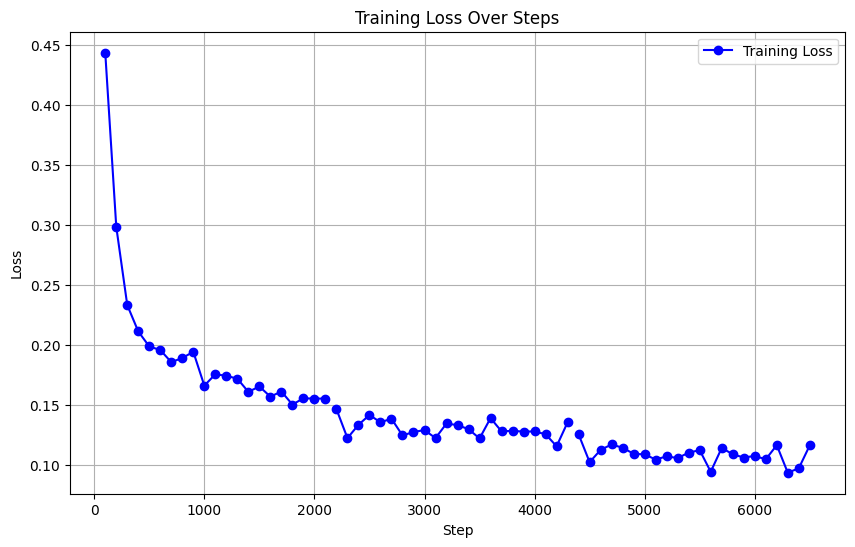

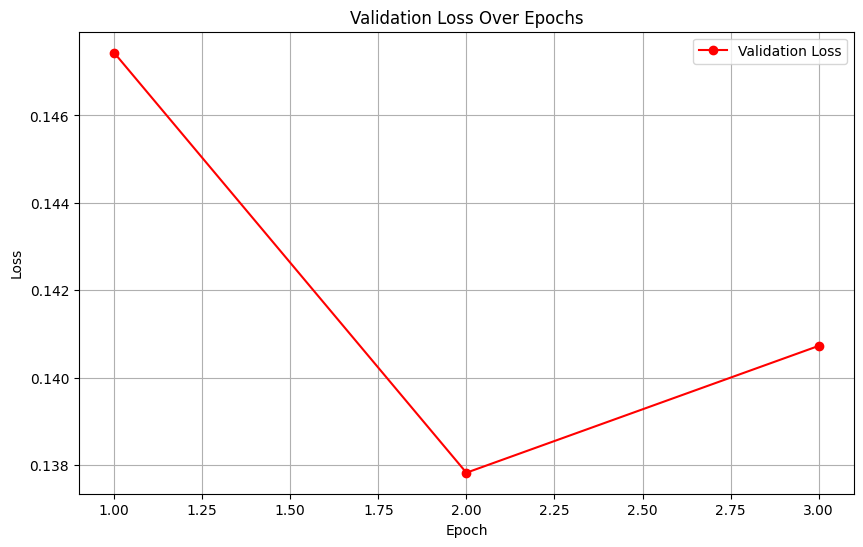

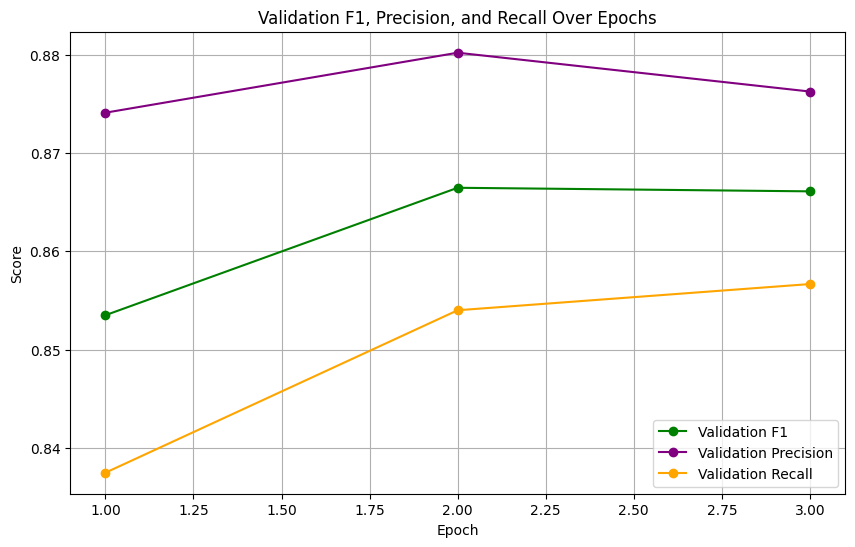

In [ ]:
# Install required libraries
!pip install -q pandas matplotlib

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set working directory
import os
os.chdir('/content/drive/MyDrive/MentalBERT_Project')
print("Working directory set to /content/drive/MyDrive/MentalBERT_Project")

# Import necessary libraries
import pandas as pd
import json
import matplotlib.pyplot as plt

# Load the trainer_state.json from the last checkpoint
trainer_state_path = "/content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_ep3/checkpoint-6564/trainer_state.json"
with open(trainer_state_path, 'r') as f:
    trainer_state = json.load(f)
log_history = trainer_state.get('log_history', [])

# Extract relevant data
data = []
for entry in log_history:
    row = {
        'epoch': entry.get('epoch', -1),
        'step': entry.get('step', -1),
        'train_loss': entry.get('loss', None),  # Training loss when available
        'eval_f1': entry.get('eval_f1', None),  # Validation F1 at epoch end
        'eval_loss': entry.get('eval_loss', None),
        'eval_precision': entry.get('eval_precision', None),  # Validation precision
        'eval_recall': entry.get('eval_recall', None)        # Validation recall
    }
    data.append(row)

# Convert to DataFrame
df_logs = pd.DataFrame(data)
df_logs = df_logs.sort_values('step').reset_index(drop=True)

# Save to CSV for future use
df_logs.to_csv("/content/drive/MyDrive/MentalBERT_Project/f1_scores.csv", index=False)
print("F1 scores, precision, recall, and loss data saved to f1_scores.csv")

# Plot 1: Training Loss vs. Step
plt.figure(figsize=(10, 6))
plt.plot(df_logs['step'], df_logs['train_loss'], label='Training Loss', color='blue', marker='o')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss Over Steps')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Validation Loss vs. Epoch
plt.figure(figsize=(10, 6))
plt.plot(df_logs[df_logs['eval_loss'].notna()]['epoch'], df_logs[df_logs['eval_loss'].notna()]['eval_loss'],
         label='Validation Loss', color='red', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: Validation F1, Precision, and Recall vs. Epoch
plt.figure(figsize=(10, 6))
plt.plot(df_logs[df_logs['eval_f1'].notna()]['epoch'], df_logs[df_logs['eval_f1'].notna()]['eval_f1'],
         label='Validation F1', color='green', marker='o')
plt.plot(df_logs[df_logs['eval_precision'].notna()]['epoch'], df_logs[df_logs['eval_precision'].notna()]['eval_precision'],
         label='Validation Precision', color='purple', marker='o')
plt.plot(df_logs[df_logs['eval_recall'].notna()]['epoch'], df_logs[df_logs['eval_recall'].notna()]['eval_recall'],
         label='Validation Recall', color='orange', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation F1, Precision, and Recall Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Collect metrics from trainer logs for plotting
train_losses = []
val_losses = []
val_f1s = []
log_history = trainer.state.log_history
for log in log_history:
    if 'loss' in log:
        train_losses.append(log['loss'])
    if 'eval_loss' in log:
        val_losses.append(log['eval_loss'])
        val_f1s.append(log['eval_f1'])

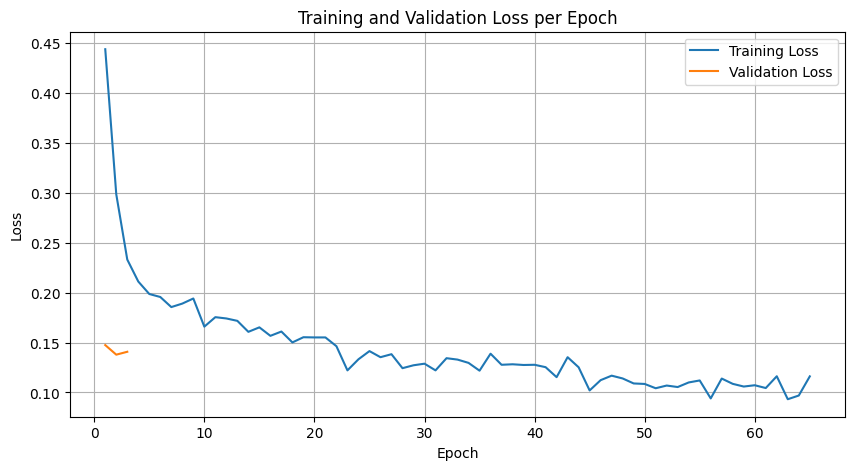

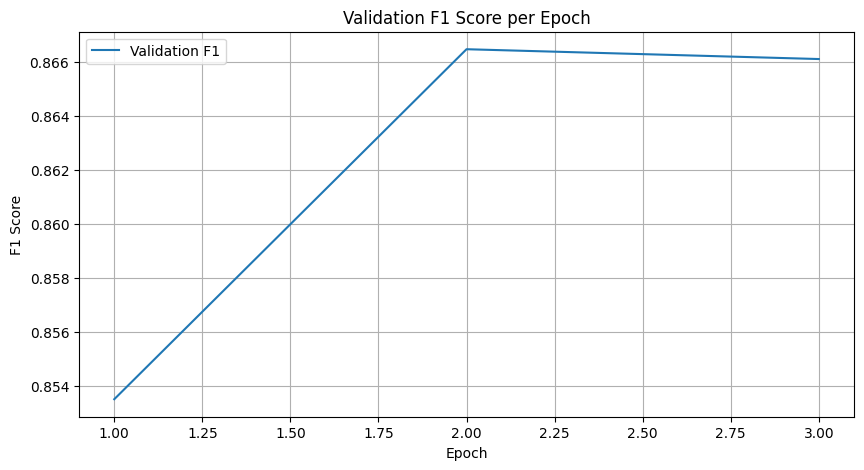

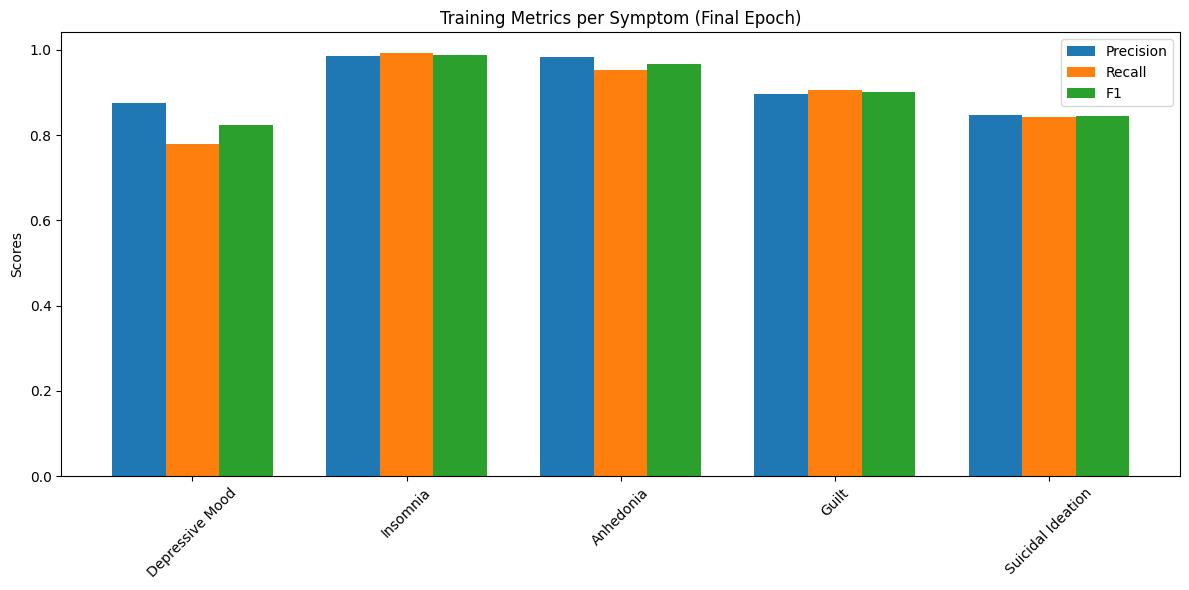

In [ ]:
# Import libraries for plotting
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support
import torch

# Get number of epochs from training arguments (set manually in Cell 5)
num_epochs = trainer.args.num_train_epochs

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Plot validation F1
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(val_f1s) + 1), val_f1s, label='Validation F1')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Validation F1 Score per Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Compute per-symptom metrics for training at final epoch
trainer.model.eval()
train_predictions = trainer.predict(train_dataset)
train_pred_probs = torch.sigmoid(torch.tensor(train_predictions.predictions)).numpy()
train_pred_labels = (train_pred_probs >= 0.5).astype(int)
per_label_precision_train = []
per_label_recall_train = []
per_label_f1_train = []
symptoms = ["Depressive Mood", "Insomnia", "Anhedonia", "Guilt", "Suicidal Ideation"]
for i in range(5):
    p, r, f, _ = precision_recall_fscore_support(
        train_labels[:, i], train_pred_labels[:, i], average="binary"
    )
    per_label_precision_train.append(p)
    per_label_recall_train.append(r)
    per_label_f1_train.append(f)

# Bar plot for per-symptom training metrics
x = np.arange(len(symptoms))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, per_label_precision_train, width, label='Precision')
ax.bar(x, per_label_recall_train, width, label='Recall')
ax.bar(x + width, per_label_f1_train, width, label='F1')
ax.set_ylabel('Scores')
ax.set_title('Training Metrics per Symptom (Final Epoch)')
ax.set_xticks(x)
ax.set_xticklabels(symptoms, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Import libraries for predictions
import torch
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Predict on test set for metrics
print("Evaluating on test set...")
test_predictions = trainer.predict(test_dataset)
test_pred_probs = torch.sigmoid(torch.tensor(test_predictions.predictions)).numpy()
test_pred_labels = (test_pred_probs >= 0.5).astype(int)  # Threshold at 0.5

# Compute test metrics
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_labels, test_pred_labels, average="macro"
)
print("\nTest Metrics:")
print(f"Precision: {test_precision:.2f}")
print(f"Recall: {test_recall:.2f}")
print(f"F1 Score: {test_f1:.2f}")

# Show validation metrics
val_metrics = trainer.evaluate()
print("\nValidation Metrics:")
print(f"Precision: {val_metrics['eval_precision']:.2f}")
print(f"Recall: {val_metrics['eval_recall']:.2f}")
print(f"F1 Score: {val_metrics['eval_f1']:.2f}")

Evaluating on test set...



Test Metrics:
Precision: 0.87
Recall: 0.84
F1 Score: 0.85



Validation Metrics:
Precision: 0.88
Recall: 0.85
F1 Score: 0.87


Evaluating on test set...



Test Metrics:
Precision: 0.87
Recall: 0.84
F1 Score: 0.85


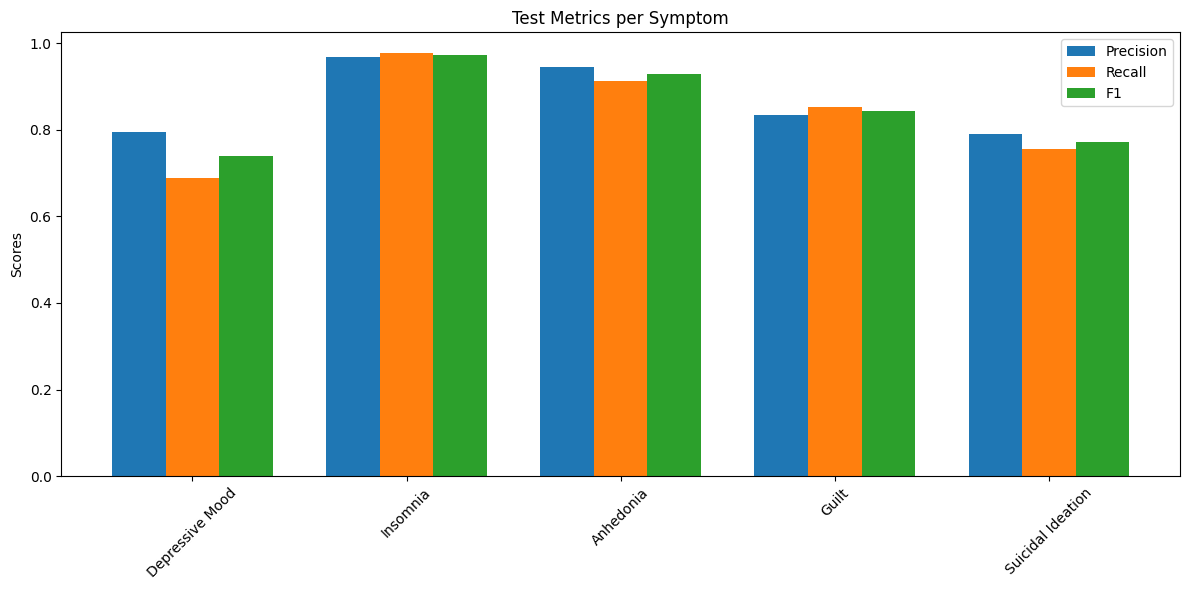


Validation Metrics:
Precision: 0.88
Recall: 0.85
F1 Score: 0.87


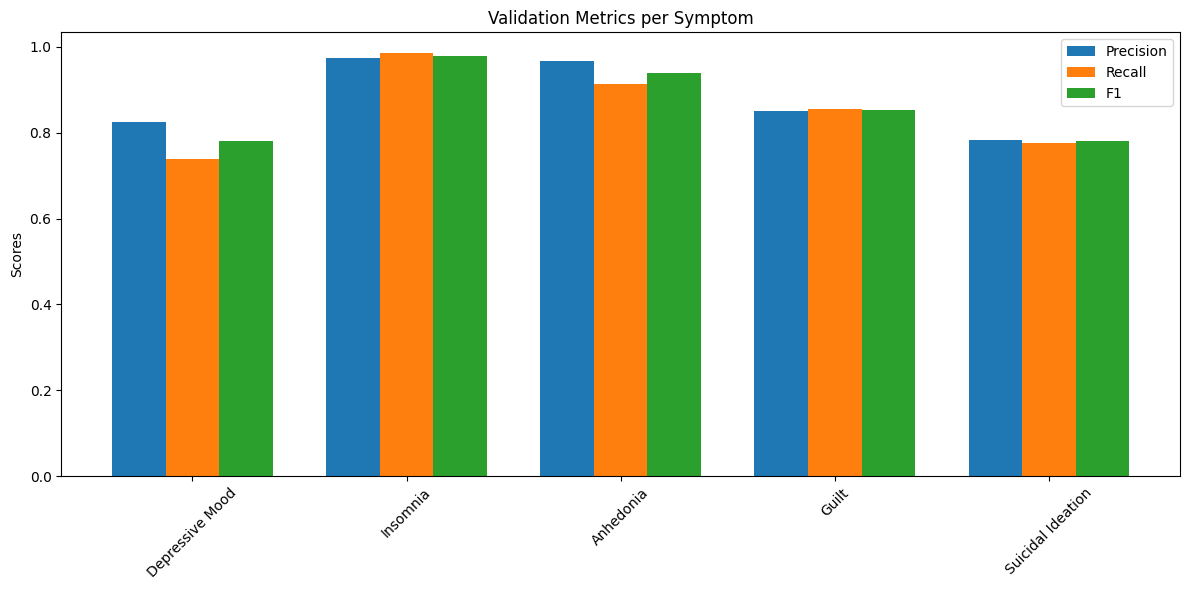

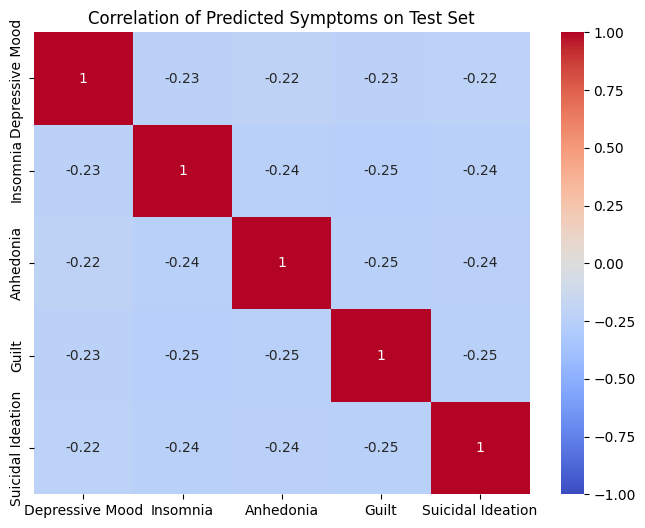

In [ ]:
# Import libraries for predictions
import torch
import numpy as np
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Predict on test set for metrics
print("Evaluating on test set...")
test_predictions = trainer.predict(test_dataset)
test_pred_probs = torch.sigmoid(torch.tensor(test_predictions.predictions)).numpy()
test_pred_labels = (test_pred_probs >= 0.5).astype(int)  # Threshold at 0.5

# Compute test metrics
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_labels, test_pred_labels, average="macro"
)
print("\nTest Metrics:")
print(f"Precision: {test_precision:.2f}")
print(f"Recall: {test_recall:.2f}")
print(f"F1 Score: {test_f1:.2f}")

# Compute per-label metrics for test
per_label_precision_test = []
per_label_recall_test = []
per_label_f1_test = []
for i in range(5):
    p, r, f, _ = precision_recall_fscore_support(
        test_labels[:, i], test_pred_labels[:, i], average="binary"
    )
    per_label_precision_test.append(p)
    per_label_recall_test.append(r)
    per_label_f1_test.append(f)

# Bar plot for per-symptom metrics on test
x = np.arange(len(symptoms))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, per_label_precision_test, width, label='Precision')
ax.bar(x, per_label_recall_test, width, label='Recall')
ax.bar(x + width, per_label_f1_test, width, label='F1')
ax.set_ylabel('Scores')
ax.set_title('Test Metrics per Symptom')
ax.set_xticks(x)
ax.set_xticklabels(symptoms, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Predict on validation set for per-label metrics (trainer.evaluate() already computes macro)
val_predictions = trainer.predict(val_dataset)
val_pred_probs = torch.sigmoid(torch.tensor(val_predictions.predictions)).numpy()
val_pred_labels = (val_pred_probs >= 0.5).astype(int)

# Show validation metrics
val_metrics = trainer.evaluate()
print("\nValidation Metrics:")
print(f"Precision: {val_metrics['eval_precision']:.2f}")
print(f"Recall: {val_metrics['eval_recall']:.2f}")
print(f"F1 Score: {val_metrics['eval_f1']:.2f}")

# Compute per-label metrics for validation
per_label_precision_val = []
per_label_recall_val = []
per_label_f1_val = []
for i in range(5):
    p, r, f, _ = precision_recall_fscore_support(
        val_labels[:, i], val_pred_labels[:, i], average="binary"
    )
    per_label_precision_val.append(p)
    per_label_recall_val.append(r)
    per_label_f1_val.append(f)

# Bar plot for per-symptom metrics on validation
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, per_label_precision_val, width, label='Precision')
ax.bar(x, per_label_recall_val, width, label='Recall')
ax.bar(x + width, per_label_f1_val, width, label='F1')
ax.set_ylabel('Scores')
ax.set_title('Validation Metrics per Symptom')
ax.set_xticks(x)
ax.set_xticklabels(symptoms, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Correlation heatmap of predicted symptoms on test set (insights into co-predictions)
pred_df = pd.DataFrame(test_pred_labels, columns=symptoms)
corr = pred_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Predicted Symptoms on Test Set')
plt.show()

In [ ]:
# Import libraries
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from huggingface_hub import login

# Remount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set working directory
import os
os.chdir('/content/drive/MyDrive/MentalBERT_Project')
print("Working directory set to /content/drive/MyDrive/MentalBERT_Project")

# Log in to Hugging Face for tokenizer access
login(new_session=False)  # Enter your Hugging Face token when prompted

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained("mental/mental-bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("/content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_ep3", num_labels=5, problem_type="multi_label_classification")
model.eval()  # Set to evaluation mode

# Define symptoms
symptoms = ["Depressive Mood", "Insomnia", "Anhedonia", "Guilt", "Suicidal Ideation"]

# Get text input from user
texts = []
while True:
    text = input("Enter a Reddit post text (or 'done' to finish): ")
    if text.lower() == 'done':
        break
    texts.append(text)

# Tokenize input
if texts:
    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    # Get predictions
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits).numpy()  # Probabilities for each symptom
        preds = (probs >= 0.5).astype(int)  # Binary predictions (threshold 0.5)

    # Display results
    for i, text in enumerate(texts):
        print(f"\nText: {text[:500]}")  # Truncate for display
        print("Predicted Symptoms and Probabilities:")
        for j, symptom in enumerate(symptoms):
            print(f"  {symptom}: Probability = {probs[i][j]:.3f}, Predicted = {bool(preds[i][j])}")
else:
    print("No text entered.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory set to /content/drive/MyDrive/MentalBERT_Project


tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Enter a Reddit post text (or 'done' to finish): i know i write alot in this subreddit but the whole “anhedonia” feeling makes no sense to me, how can a brain just stop having pleasure out of nowhere and not even attempt to get used to that feeling, theres no comfortability in having this feeling, i wish i could just get over it like people tell me, but i always tell them that its easier said than done but like WHY is it easier said than done, why cant i just flip a switch and everything is back to normal
Enter a Reddit post text (or 'done' to finish): done

Text: i know i write alot in this subreddit but the whole “anhedonia” feeling makes no sense to me, how can a brain just stop having pleasure out of nowhere and not even attempt to get used to that feeling, theres no comfortability in having this feeling, i wish i could just get over it like people tell me, but i always tell them that its easier said than done but like WHY is it easier said than done, why cant i just flip a switch a

In [ ]:
# Import libraries
import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from huggingface_hub import login
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set working directory
os.chdir('/content/drive/MyDrive/MentalBERT_Project')
print("Working directory set to /content/drive/MyDrive/MentalBERT_Project")

# Log in to Hugging Face for tokenizer access
login(new_session=False)  # Enter your Hugging Face token when prompted

# Load tokenizer and model
print("Loading tokenizer and model...")
tokenizer = BertTokenizer.from_pretrained("mental/mental-bert-base-uncased")
model = BertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_ep3",
    num_labels=5,
    problem_type="multi_label_classification"
)
model.eval()  # Set to evaluation mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded on {device}")

# Define symptoms
symptoms = ["Depressive Mood", "Insomnia", "Anhedonia", "Guilt", "Suicidal Ideation"]

# Load dataset (limit to 10 records for testing)
data_path = "/content/drive/MyDrive/MentalBERT_Project/data/depression_2y_v1.csv"
print(f"Loading dataset from {data_path}...")
df = pd.read_csv(data_path)
df = df.head(10)  # Limit to first 10 records
print(f"Dataset loaded, {len(df)} records")

# Combine title and selftext, ensure all are strings
print("Preprocessing texts...")
df['text'] = df['title'].astype(str) + " " + df['selftext'].fillna("").astype(str)
texts = df['text'].tolist()
print(f"Sample texts (first 3, truncated):")
for i, text in enumerate(texts[:3]):
    print(f"Text {i+1}: {text[:100]}...")

# Custom dataset for batching
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]  # Return raw text, tokenize in collate_fn

# Custom collate function for dynamic batch padding
def collate_fn(batch):
    # Ensure batch is a list of strings
    batch = [str(text) for text in batch]
    print(f"Tokenizing batch of {len(batch)} texts...")
    encodings = tokenizer(
        batch,
        padding="longest",  # Pad to longest sequence in batch
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    return {key: val for key, val in encodings.items()}

# Create DataLoader for batch processing
print("Creating DataLoader...")
dataset = TextDataset(texts)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)  # Smaller batch size for testing
print(f"DataLoader created with {len(dataset)} texts, batch size 4")

# Predict in batches
all_probs = []
all_preds = []
print("Starting predictions...")
with torch.no_grad():
    for i, batch in enumerate(dataloader):
        print(f"Processing batch {i+1}/{len(dataloader)}")
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.append(probs)
        all_preds.append(preds)

# Concatenate predictions
print("Concatenating predictions...")
all_probs = np.concatenate(all_probs, axis=0)
all_preds = np.concatenate(all_preds, axis=0)
print(f"Predictions completed: {all_probs.shape[0]} records")

# Create output DataFrame
output_df = df.copy()
for i, symptom in enumerate(symptoms):
    output_df[f"{symptom.replace(' ', '_')}_Prob"] = all_probs[:, i]
    output_df[f"{symptom.replace(' ', '_')}_Pred"] = all_preds[:, i]

# Save predictions to CSV
output_path = "/content/drive/MyDrive/MentalBERT_Project/data/depression_2y_v1_predictions_ep3.csv"
output_df.to_csv(output_path, index=False)
print(f"Predictions saved to {output_path}")

# Display sample of predictions
print("\nSample of predictions (first 5 rows):")
print(output_df[['id', 'title'] + [f"{symptom.replace(' ', '_')}_Prob" for symptom in symptoms] + [f"{symptom.replace(' ', '_')}_Pred" for symptom in symptoms]].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory set to /content/drive/MyDrive/MentalBERT_Project
Loading tokenizer and model...
Model loaded on cuda
Loading dataset from /content/drive/MyDrive/MentalBERT_Project/data/depression_2y_v1.csv...
Dataset loaded, 10 records
Preprocessing texts...
Sample texts (first 3, truncated):
Text 1: I’m tired of pretending that I’m fine I’ve been battling depression since high school, and only star...
Text 2: im 22 but i look like im 30 and sound like 15 I just have a terrible voice. I sound like im weak and...
Text 3: I just want a second opinion Hi everyone, recently my workplace is closed for 6 weeks so I’m off wor...
Creating DataLoader...
DataLoader created with 10 texts, batch size 4
Starting predictions...
Tokenizing batch of 4 texts...
Processing batch 1/3
Tokenizing batch of 4 texts...
Processing batch 2/3
Tokenizing batch of 2 texts...
Processing

In [ ]:
# Create PyTorch dataset
class RedditDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

In [ ]:
# Load Dataset
# Set working directory
os.chdir('/content/drive/MyDrive/MentalBERT_Project')

# Load your r/depression dataset (update the path to your actual file)
dataset_path = "/content/drive/MyDrive/MentalBERT_Project/data/depression_2y_v1_sample.csv"  # Adjust this path
df = pd.read_csv(dataset_path)

# Combine title and selftext for inference (handle NaN in selftext)
df['selftext'] = df['selftext'].fillna("")  # Replace NaN with empty string
depression_posts = (df["title"] + " " + df["selftext"]).str.strip().tolist()

depression_posts



['I’m tired of pretending that I’m fine I’ve been battling depression since high school, and only started receiving help 2 years ago. I got put on medication and began seeing a therapist. Everything was fine until I started realizing last year that my mind was slowly crumbling away. I couldn’t bear with the pain that I was going through and ultimately had the darkest day of my life. Upon waking up, I was a mess. I felt like life was out to get me, yet I felt that I was so insignificant that it wouldn’t bat an eye at my existence. I ultimately ended up attempting to take my life that night. The fear and pain I experienced after I made my choice shakes me to this day, and it’s very difficult for me to open up about what I felt with the people that are closest to me. I began to muster up the courage to talk about that day and talk to my partner about it, only to be told that what I did was toxic and manipulative when all I wanted was for someone I could let out my misery and pain to. Mayb

In [ ]:
# Import libraries for tokenization
import torch
from transformers import BertTokenizer
from huggingface_hub import login

# Log in to Hugging Face for gated repo access
login(new_session=False)  # Enter your Hugging Face token when prompted

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("mental/mental-bert-base-uncased")

# Tokenize function
def tokenize_data(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

depression_encodings = tokenizer(depression_posts, padding=True, truncation=True, max_length=128, return_tensors="pt")


# Create PyTorch dataset
class RedditDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.encodings["input_ids"])

depression_dataset = RedditDataset(depression_encodings)  # No labels

print(f"Dataset sizes: {len(depression_dataset)}")
print("Tokenization completed!")



Dataset sizes: 5
Tokenization completed!


In [ ]:
# Import libraries
import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from huggingface_hub import login
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.metrics import precision_recall_fscore_support

# Disable W&B to prevent any login prompts
os.environ["WANDB_MODE"] = "disabled"

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set working directory
os.chdir('/content/drive/MyDrive/MentalBERT_Project')
print("Working directory set to /content/drive/MyDrive/MentalBERT_Project")

# Log in to Hugging Face for tokenizer access
login(new_session=False)  # Enter your Hugging Face token when prompted

# Load tokenizer and best model
print("Loading tokenizer and model...")
tokenizer = BertTokenizer.from_pretrained("mental/mental-bert-base-uncased")
model = BertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_clf_lr_0.0005/checkpoint-4376",  # Best model
    num_labels=5,
    problem_type="multi_label_classification"
)
model.eval()  # Set to evaluation mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded on {device}")

# Define symptoms
symptoms = ["Depressive Mood", "Insomnia", "Anhedonia", "Guilt", "Suicidal Ideation"]

# Load dataset
data_path = "/content/drive/MyDrive/MentalBERT_Project/data/depression_2y_v1.csv"
print(f"Loading dataset from {data_path}...")
df = pd.read_csv(data_path)
print(f"Dataset loaded, {len(df)} records")

# Combine title and selftext, ensure all are strings
print("Preprocessing texts...")
df['selftext'] = df['selftext'].fillna("")  # Handle NaN
df['title'] = df['title'].astype(str)  # Ensure title is string
df['text'] = df['title'] + " " + df['selftext']
# Filter out empty or invalid texts
df = df[df['text'].str.strip() != ""]
texts = df['text'].tolist()
print(f"Filtered dataset, {len(texts)} valid texts")
print(f"Sample texts (first 3, truncated):")
for i, text in enumerate(texts[:3]):
    print(f"Text {i+1}: {text[:100]}...")

# Custom dataset for batching
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]  # Return raw text, tokenize in collate_fn

# Custom collate function for dynamic batch padding
def collate_fn(batch):
    # Filter out any invalid texts in the batch
    batch = [str(text) for text in batch if str(text).strip() != ""]
    if not batch:  # Handle empty batch
        return None
    print(f"Tokenizing batch of {len(batch)} texts...")
    encodings = tokenizer(
        batch,
        padding="longest",  # Pad to longest sequence in batch
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )
    return {key: val for key, val in encodings.items()}

# Create DataLoader for batch processing
print("Creating DataLoader...")
dataset = TextDataset(texts)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
print(f"DataLoader created with {len(dataset)} texts, batch size 16")

# Predict in batches
all_probs = []
all_preds = []
print("Starting predictions...")
with torch.no_grad():
    for i, batch in enumerate(dataloader):
        if batch is None:  # Skip empty batches
            continue
        print(f"Processing batch {i+1}/{len(dataloader)}")
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)  # Threshold at 0.5
        all_probs.append(probs)
        all_preds.append(preds)

# Concatenate predictions
print("Concatenating predictions...")
all_probs = np.concatenate(all_probs, axis=0)
all_preds = np.concatenate(all_preds, axis=0)
print(f"Predictions completed: {all_probs.shape[0]} records")

# Create output DataFrame
output_df = df.copy()
for i, symptom in enumerate(symptoms):
    output_df[f"{symptom.replace(' ', '_')}_Prob"] = all_probs[:, i]
    output_df[f"{symptom.replace(' ', '_')}_Pred"] = all_preds[:, i]

# Save predictions to CSV
output_path = "/content/drive/MyDrive/MentalBERT_Project/data/depression_2y_v1_predictions_best_model.csv"
output_df.to_csv(output_path, index=False)
print(f"Predictions saved to {output_path}")

# Display sample of predictions
print("\nSample of predictions (first 5 rows):")
print(output_df[['id', 'title'] + [f"{symptom.replace(' ', '_')}_Prob" for symptom in symptoms] + [f"{symptom.replace(' ', '_')}_Pred" for symptom in symptoms]].head())

Streaming output truncated to the last 5000 lines.
Tokenizing batch of 16 texts...
Processing batch 7183/9666
Tokenizing batch of 16 texts...
Processing batch 7184/9666
Tokenizing batch of 16 texts...
Processing batch 7185/9666
Tokenizing batch of 16 texts...
Processing batch 7186/9666
Tokenizing batch of 16 texts...
Processing batch 7187/9666
Tokenizing batch of 16 texts...
Processing batch 7188/9666
Tokenizing batch of 16 texts...
Processing batch 7189/9666
Tokenizing batch of 16 texts...
Processing batch 7190/9666
Tokenizing batch of 16 texts...
Processing batch 7191/9666
Tokenizing batch of 16 texts...
Processing batch 7192/9666
Tokenizing batch of 16 texts...
Processing batch 7193/9666
Tokenizing batch of 16 texts...
Processing batch 7194/9666
Tokenizing batch of 16 texts...
Processing batch 7195/9666
Tokenizing batch of 16 texts...
Processing batch 7196/9666
Tokenizing batch of 16 texts...
Processing batch 7197/9666
Tokenizing batch of 16 texts...
Processing batch 7198/9666
Token

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Per-Symptom Performance:
                   precision    recall  f1-score  support
Depressive Mood     0.794229  0.697333  0.742634   1500.0
Insomnia            0.972037  0.973333  0.972685   1500.0
Anhedonia           0.948682  0.912000  0.929980   1500.0
Guilt               0.848161  0.845333  0.846745   1500.0
Suicidal Ideation   0.775770  0.772667  0.774215   1500.0


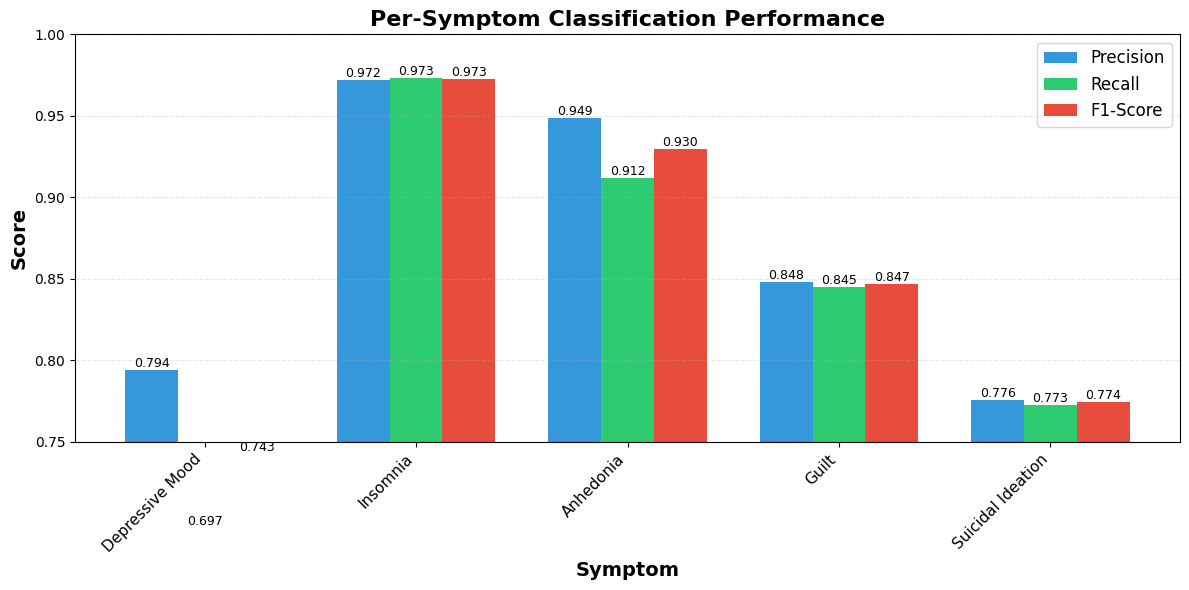


✓ Per-symptom performance graph saved!


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Get predictions on test set (you already have this from earlier)
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
import torch

# Load best model
best_model = BertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_clf_lr_0.0005/checkpoint-4376"
)

# Trainer for predictions
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/MentalBERT_Project/eval_results",
    per_device_eval_batch_size=16,
    report_to="none"
)

trainer = Trainer(
    model=best_model,
    args=training_args,
    eval_dataset=test_dataset
)

# Get predictions
predictions = trainer.predict(test_dataset)
preds = torch.sigmoid(torch.tensor(predictions.predictions)).numpy()
preds_binary = (preds >= 0.5).astype(int)

# Generate per-symptom report
symptom_names = ["Depressive Mood", "Insomnia", "Anhedonia", "Guilt", "Suicidal Ideation"]
report = classification_report(test_labels, preds_binary, target_names=symptom_names, output_dict=True)

# Create DataFrame
df_report = pd.DataFrame(report).transpose()
df_report = df_report.iloc[:5]  # Only symptom rows

print("Per-Symptom Performance:")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(symptom_names))
width = 0.25

bars1 = ax.bar(x - width, df_report['precision'][:5], width, label='Precision', color='#3498db')
bars2 = ax.bar(x, df_report['recall'][:5], width, label='Recall', color='#2ecc71')
bars3 = ax.bar(x + width, df_report['f1-score'][:5], width, label='F1-Score', color='#e74c3c')

ax.set_xlabel('Symptom', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('Per-Symptom Classification Performance', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12)
ax.set_ylim([0.75, 1.0])
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MentalBERT_Project/per_symptom_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Per-symptom performance graph saved!")

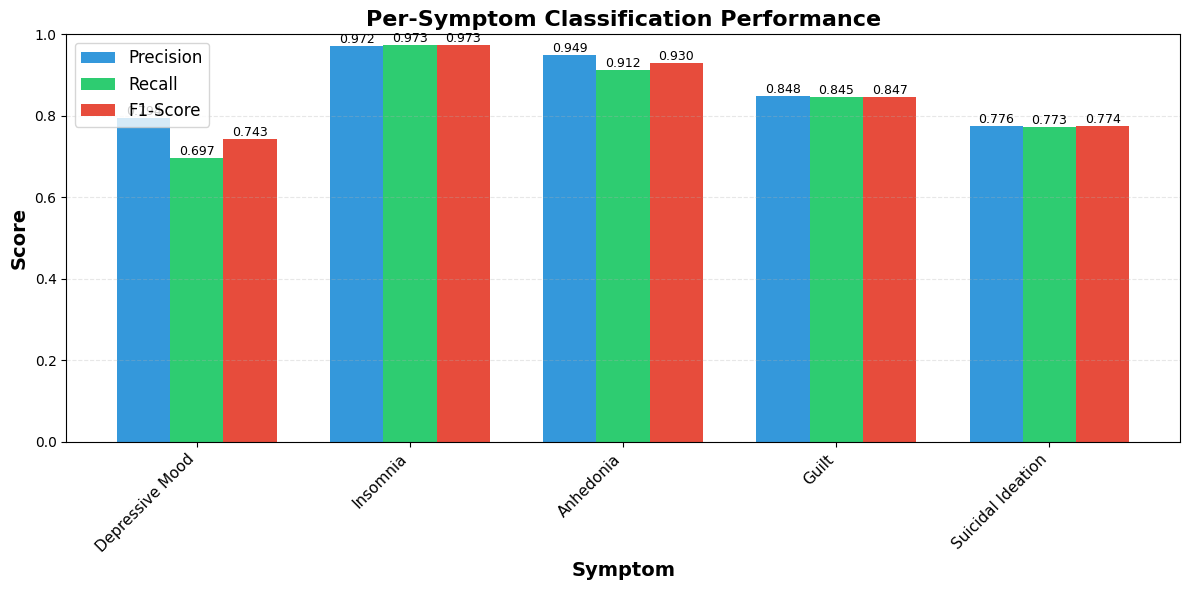


✓ Per-symptom performance graph saved!


In [ ]:

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(symptom_names))
width = 0.25

bars1 = ax.bar(x - width, df_report['precision'][:5], width, label='Precision', color='#3498db')
bars2 = ax.bar(x, df_report['recall'][:5], width, label='Recall', color='#2ecc71')
bars3 = ax.bar(x + width, df_report['f1-score'][:5], width, label='F1-Score', color='#e74c3c')

ax.set_xlabel('Symptom', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('Per-Symptom Classification Performance', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12)
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MentalBERT_Project/per_symptom_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Per-symptom performance graph saved!")

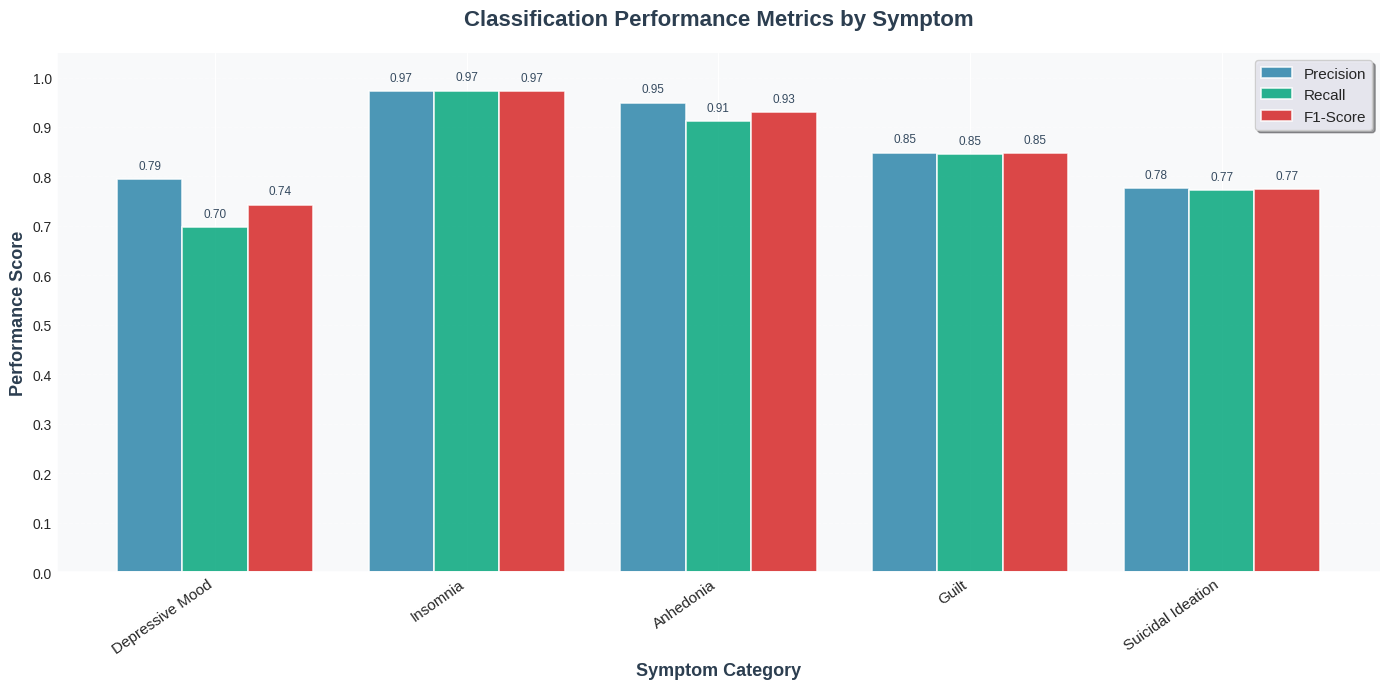


✓ Enhanced per-symptom performance graph saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(symptom_names))
width = 0.26

# Use a more sophisticated color palette
colors = {
    'precision': '#2E86AB',  # Professional blue
    'recall': '#06A77D',     # Clean green
    'f1': '#D62828'          # Strong red
}

bars1 = ax.bar(x - width, df_report['precision'][:5], width,
               label='Precision', color=colors['precision'],
               edgecolor='white', linewidth=1.2, alpha=0.85)
bars2 = ax.bar(x, df_report['recall'][:5], width,
               label='Recall', color=colors['recall'],
               edgecolor='white', linewidth=1.2, alpha=0.85)
bars3 = ax.bar(x + width, df_report['f1-score'][:5], width,
               label='F1-Score', color=colors['f1'],
               edgecolor='white', linewidth=1.2, alpha=0.85)

# Enhanced labels and title
ax.set_xlabel('Symptom Category', fontsize=13, fontweight='600', color='#2c3e50')
ax.set_ylabel('Performance Score', fontsize=13, fontweight='600', color='#2c3e50')
ax.set_title('Classification Performance Metrics by Symptom',
             fontsize=16, fontweight='bold', color='#2c3e50', pad=20)

# Improved x-axis labels
ax.set_xticks(x)
ax.set_xticklabels(symptom_names, rotation=35, ha='right', fontsize=11, fontweight='500')

# Enhanced legend
ax.legend(fontsize=11, frameon=True, shadow=True, fancybox=True,
          loc='upper right', framealpha=0.95)

# Y-axis configuration
ax.set_ylim([0, 1.05])
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Cleaner value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only show label if there's a value
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.015,
                    f'{height:.2f}',  # Changed to 2 decimal places for cleaner look
                    ha='center', va='bottom', fontsize=8.5,
                    fontweight='500', color='#34495e')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# Add subtle background color
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

print("\n✓ Enhanced per-symptom performance graph saved!")

In [ ]:
import torch
from transformers import BertForSequenceClassification, BertTokenizer
import numpy as np

# Load best model and tokenizer
model = BertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_clf_lr_0.0005/checkpoint-4376"
)
tokenizer = BertTokenizer.from_pretrained("mental/mental-bert-base-uncased")

symptom_names = ["Depressive Mood", "Insomnia", "Anhedonia", "Guilt", "Suicidal Ideation"]

# Function to predict on a single text
def predict_symptoms(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits).numpy()[0]

    predictions = (probs >= 0.5).astype(int)

    print("=" * 60)
    print("TEXT:")
    print(text)
    print("\n" + "=" * 60)
    print("PREDICTIONS:")
    for i, (symptom, prob, pred) in enumerate(zip(symptom_names, probs, predictions)):
        status = "✓ DETECTED" if pred == 1 else "✗ Not detected"
        print(f"{symptom:20s} | Prob: {prob:.3f} | {status}")
    print("=" * 60)

    return probs, predictions

# Let's find examples from test set with multiple labels
print("Searching for multi-label examples in test set...\n")

# Get some test examples with multiple true labels
multi_label_indices = []
for i in range(len(test_labels)):
    if test_labels[i].sum() >= 1:  # At least 3 symptoms
        multi_label_indices.append(i)
        if len(multi_label_indices) >= 10:  # Get first 10
            break

print(f"Found {len(multi_label_indices)} examples with 3+ symptoms")

# Check predictions on these examples
for idx in multi_label_indices[:3]:  # Show first 3
    text = test_texts[idx]
    true_labels = test_labels[idx]

    print("\n" + "="*60)
    print(f"EXAMPLE {multi_label_indices.index(idx) + 1}")
    print("="*60)
    print(f"TEXT: {text[:300]}...")  # Show first 300 chars
    print(f"\nTRUE LABELS: {[symptom_names[i] for i, label in enumerate(true_labels) if label == 1]}")

    probs, preds = predict_symptoms(text)
    print(f"PREDICTED: {[symptom_names[i] for i, pred in enumerate(preds) if pred == 1]}")
    print()

Searching for multi-label examples in test set...

Found 10 examples with 3+ symptoms

EXAMPLE 1
TEXT: NYU Langone Health Depression Research Study - Recruiting Participants Suffering from Depression? Help us find new treatments!

What is SGLT2-MDD?

This is an in-person research study that aims to understand the effect of empagliflozin, a medication part of the class of sodium-glucose cotransporter-...

TRUE LABELS: ['Anhedonia']
TEXT:
NYU Langone Health Depression Research Study - Recruiting Participants Suffering from Depression? Help us find new treatments!

What is SGLT2-MDD?

This is an in-person research study that aims to understand the effect of empagliflozin, a medication part of the class of sodium-glucose cotransporter-2 (SGLT2) inhibitors, in depression. Since this medication simulates the metabolic effects of the “ketogenic diet,” which some studies suggest improves mood, this study will also help us understand how problems with mood might relate to how the brain uses ene

In [ ]:
example_text = """
I can't do this anymore. I haven't slept in three days, just lying awake
staring at the ceiling. Nothing brings me joy anymore - I used to love hiking
and photography but now I can't even get out of bed. I feel so guilty for
being such a burden on my family. They'd probably be better off without me.
I just feel completely empty inside, like there's no point to any of this.
I'm sorry for being so negative but I had to get this out somewhere.
"""

print("ANALYZING EXAMPLE POST:")
probs, preds = predict_symptoms(example_text)

ANALYZING EXAMPLE POST:
TEXT:

I can't do this anymore. I haven't slept in three days, just lying awake 
staring at the ceiling. Nothing brings me joy anymore - I used to love hiking 
and photography but now I can't even get out of bed. I feel so guilty for 
being such a burden on my family. They'd probably be better off without me. 
I just feel completely empty inside, like there's no point to any of this. 
I'm sorry for being so negative but I had to get this out somewhere.


PREDICTIONS:
Depressive Mood      | Prob: 0.005 | ✗ Not detected
Insomnia             | Prob: 0.001 | ✗ Not detected
Anhedonia            | Prob: 0.008 | ✗ Not detected
Guilt                | Prob: 0.870 | ✓ DETECTED
Suicidal Ideation    | Prob: 0.056 | ✗ Not detected


In [ ]:
# Get the row and display all columns
post = df[df['id'] == '1fr30hx']

# Display with all columns visible
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
print(post)

Empty DataFrame
Columns: [id, created_at, title, selftext, author, score, upvote_ratio, num_comments, over_18, symptom]
Index: []


In [ ]:
### Run for comments

In [ ]:
# --------------------------------------------------------------
#  MentalBERT inference on COMMENTS (depression_comments_cleaned.csv)
# --------------------------------------------------------------

import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from huggingface_hub import login
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.metrics import precision_recall_fscore_support
from google.colab import drive

# Disable W&B
os.environ["WANDB_MODE"] = "disabled"

# Mount Drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/MentalBERT_Project')
print("Working directory set")

# Hugging Face login (token will be prompted)
login(new_session=False)

# Load tokenizer & fine-tuned model
print("Loading tokenizer and model...")
tokenizer = BertTokenizer.from_pretrained("mental/mental-bert-base-uncased")
model = BertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/MentalBERT_Project/mentalbert_finetuned_clf_lr_clf_lr_0.0005/checkpoint-4376",
    num_labels=5,
    problem_type="multi_label_classification"
)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded on {device}")

symptoms = ["Depressive Mood", "Insomnia", "Anhedonia", "Guilt", "Suicidal Ideation"]

# ------------------- LOAD COMMENTS -------------------
data_path = "/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_cleaned.csv"
df = pd.read_csv(data_path)

text_column = 'body'
if text_column not in df.columns:
    raise ValueError(f"Column '{text_column}' not found")

df[text_column] = df[text_column].fillna("")
df['text'] = df[text_column].astype(str)

# NO MIN LENGTH — KEEP ALL
df = df[df['text'].str.strip() != ""]
df = df[~df['text'].str.contains('deleted|removed', case=False, na=False)]

texts = df['text'].tolist()
print(f"Keeping ALL {len(texts)} valid OP replies (no length filter)")

# ------------------- Dataset & DataLoader -------------------
class TextDataset(Dataset):
    def __init__(self, texts): self.texts = texts
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx): return self.texts[idx]

def collate_fn(batch):
    batch = [str(t) for t in batch if str(t).strip() != ""]
    if not batch: return None
    encodings = tokenizer(
        batch,
        padding="longest",
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )
    return encodings

dataset = TextDataset(texts)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

# ------------------- Inference -------------------
all_probs = []
with torch.no_grad():
    for i, batch in enumerate(dataloader):
        if batch is None: continue
        print(f"Batch {i+1}/{len(dataloader)}")
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()
        all_probs.append(probs)

all_probs = np.concatenate(all_probs, axis=0)
print(f"Predictions: {all_probs.shape[0]} comments")

# ------------------- Save Results -------------------
output_df = df.copy()
for i, sym in enumerate(symptoms):
    col_prob = f"{sym.replace(' ', '_')}_Prob"
    col_pred = f"{sym.replace(' ', '_')}_Pred"
    output_df[col_prob] = all_probs[:, i]
    output_df[col_pred] = (all_probs[:, i] >= 0.5).astype(int)

output_path = "/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_with_probs.csv"
output_df.to_csv(output_path, index=False)
print(f"Saved predictions to {output_path}")

print("\nSample (first 3):")
print(output_df[['link_id', text_column] +
                [f"{s.replace(' ', '_')}_Prob" for s in symptoms]].head(3))

Streaming output truncated to the last 5000 lines.
Batch 2014/6995
Batch 2015/6995
Batch 2016/6995
Batch 2017/6995
Batch 2018/6995
Batch 2019/6995
Batch 2020/6995
Batch 2021/6995
Batch 2022/6995
Batch 2023/6995
Batch 2024/6995
Batch 2025/6995
Batch 2026/6995
Batch 2027/6995
Batch 2028/6995
Batch 2029/6995
Batch 2030/6995
Batch 2031/6995
Batch 2032/6995
Batch 2033/6995
Batch 2034/6995
Batch 2035/6995
Batch 2036/6995
Batch 2037/6995
Batch 2038/6995
Batch 2039/6995
Batch 2040/6995
Batch 2041/6995
Batch 2042/6995
Batch 2043/6995
Batch 2044/6995
Batch 2045/6995
Batch 2046/6995
Batch 2047/6995
Batch 2048/6995
Batch 2049/6995
Batch 2050/6995
Batch 2051/6995
Batch 2052/6995
Batch 2053/6995
Batch 2054/6995
Batch 2055/6995
Batch 2056/6995
Batch 2057/6995
Batch 2058/6995
Batch 2059/6995
Batch 2060/6995
Batch 2061/6995
Batch 2062/6995
Batch 2063/6995
Batch 2064/6995
Batch 2065/6995
Batch 2066/6995
Batch 2067/6995
Batch 2068/6995
Batch 2069/6995
Batch 2070/6995
Batch 2071/6995
Batch 2072/6995
Batch

Loading data...
✓ Posts with OP comments: 35,792
✓ Total OP comments: 111,915

ANALYSIS 1: SYMPTOM COUNT DISTRIBUTION


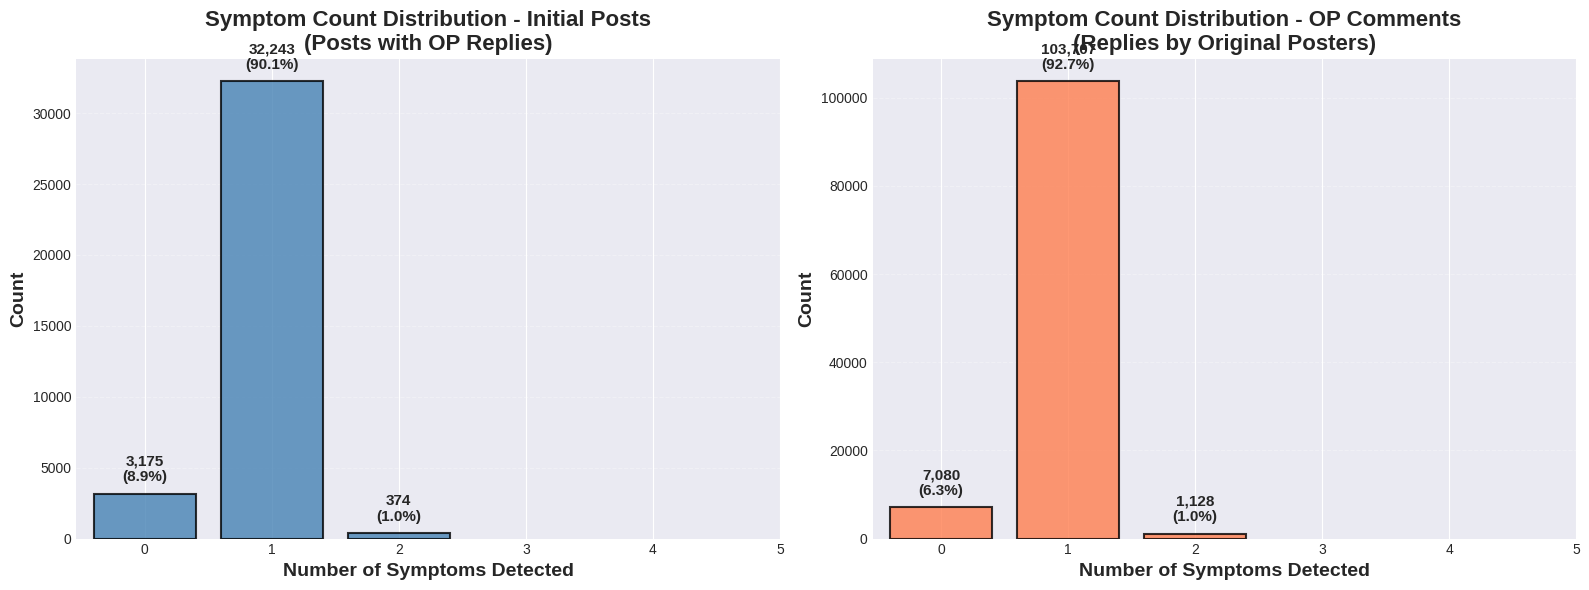


POSTS (Initial):
  0 symptoms: 3,175 (8.9%)
  1 symptoms: 32,243 (90.1%)
  2 symptoms: 374 (1.0%)
  3 symptoms: 0 (0.0%)
  4 symptoms: 0 (0.0%)
  5 symptoms: 0 (0.0%)

  Posts with ≥1 symptom: 32,617 (91.1%)
  Posts with ≥2 symptoms: 374 (1.0%)
  Average symptoms per post: 0.92

OP COMMENTS (Replies):
  0 symptoms: 7,080 (6.3%)
  1 symptoms: 103,707 (92.7%)
  2 symptoms: 1,128 (1.0%)
  3 symptoms: 0 (0.0%)
  4 symptoms: 0 (0.0%)
  5 symptoms: 0 (0.0%)

  Comments with ≥1 symptom: 104,835 (93.7%)
  Comments with ≥2 symptoms: 1,128 (1.0%)
  Average symptoms per comment: 0.95

ANALYSIS 2: SYMPTOM PREVALENCE COMPARISON

          Symptom  Posts_Count  Posts_Pct  Comments_Count  Comments_Pct  Change_Pct
  Depressive Mood        15804  44.155118            6221      5.558683  -38.596436
         Insomnia          469   1.310349             949      0.847965   -0.462384
        Anhedonia          884   2.469826           79895     71.389001   68.919175
            Guilt         4063  11.3516

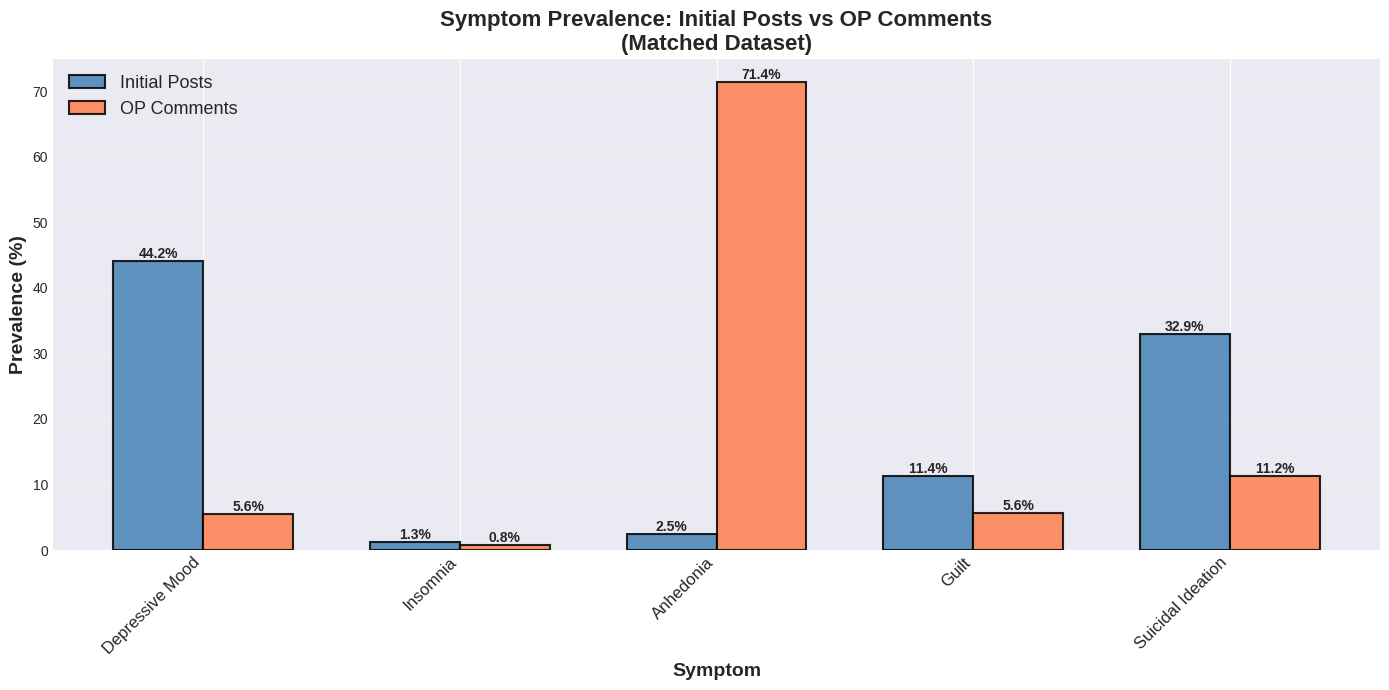


ANALYSIS 3: SYMPTOM CO-OCCURRENCE PATTERNS


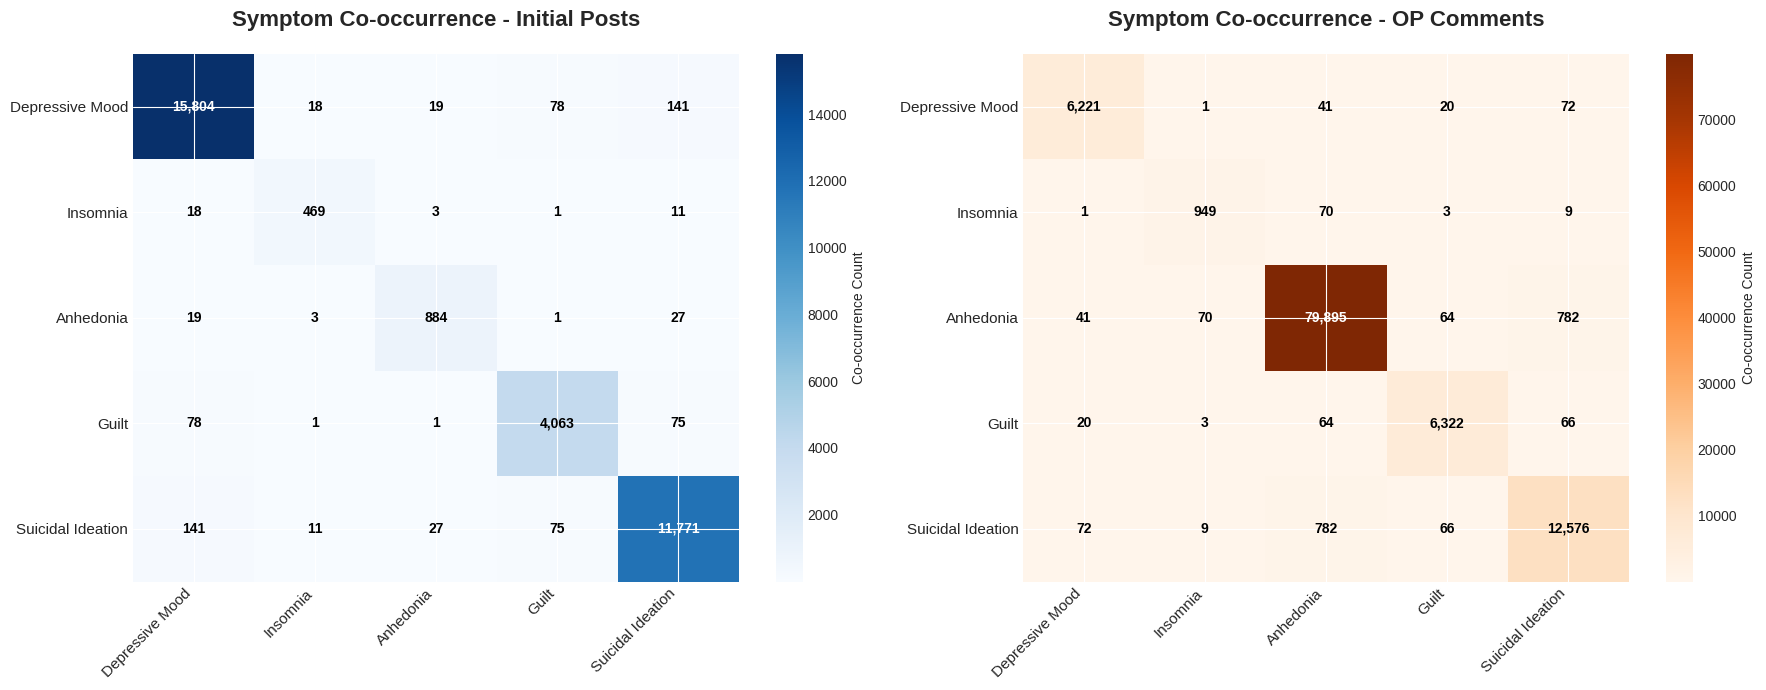


Top Co-occurring Symptom Pairs (Posts):
  Depressive Mood + Suicidal Ideation: 141 (0.4%)
  Depressive Mood + Guilt: 78 (0.2%)
  Guilt + Suicidal Ideation: 75 (0.2%)
  Anhedonia + Suicidal Ideation: 27 (0.1%)
  Depressive Mood + Anhedonia: 19 (0.1%)

Top Co-occurring Symptom Pairs (Comments):
  Anhedonia + Suicidal Ideation: 782 (0.7%)
  Depressive Mood + Suicidal Ideation: 72 (0.1%)
  Insomnia + Anhedonia: 70 (0.1%)
  Guilt + Suicidal Ideation: 66 (0.1%)
  Anhedonia + Guilt: 64 (0.1%)

ANALYSIS 4: ENGAGEMENT ANALYSIS

Comment engagement statistics:
  Mean comments per post: 2.37
  Median comments per post: 1
  Max comments per post: 150
  Min comments per post: 1
  Std dev: 3.50


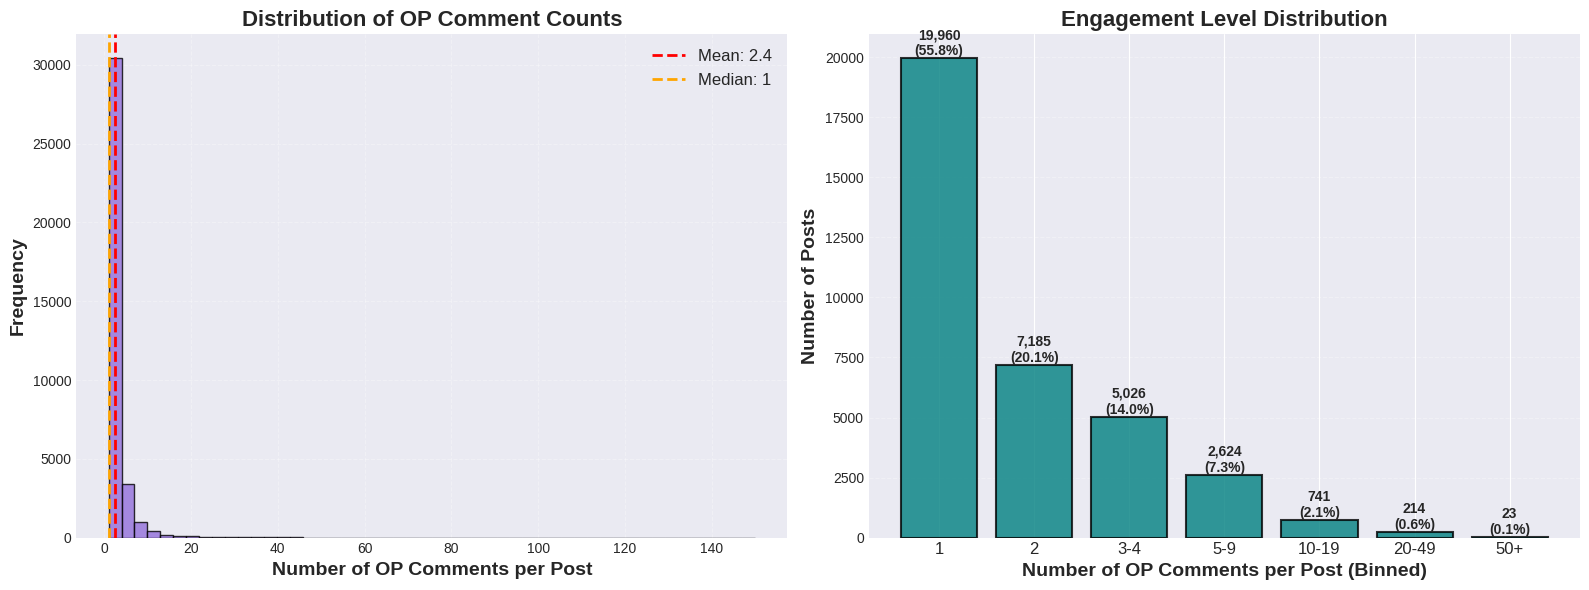


Engagement bins:
  1 comments: 19,960 posts (55.8%)
  2 comments: 7,185 posts (20.1%)
  3-4 comments: 5,026 posts (14.0%)
  5-9 comments: 2,624 posts (7.3%)
  10-19 comments: 741 posts (2.1%)
  20-49 comments: 214 posts (0.6%)
  50+ comments: 23 posts (0.1%)

SUMMARY STATISTICS

                  Metric           Initial Posts       OP Comments
           Total Records                  35,792           111,915
 Avg Symptoms per Record                    0.92              0.95
 Records with 0 symptoms            3,175 (8.9%)      7,080 (6.3%)
  Records with 1 symptom          32,243 (90.1%)   103,707 (92.7%)
Records with 2+ symptoms              374 (1.0%)      1,128 (1.0%)
     Most Common Symptom Depressive Mood (44.2%) Anhedonia (71.4%)
    Least Common Symptom         Insomnia (1.3%)   Insomnia (0.8%)
   Avg Comments per Post                    2.37               N/A

✅ ALL ANALYSES COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# LOAD DATA (Already Filtered)
# ============================================================

print("Loading data...")
posts_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_posts_with_OP_comments.csv')
comments_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_with_probs.csv')

print(f"✓ Posts with OP comments: {len(posts_df):,}")
print(f"✓ Total OP comments: {len(comments_df):,}")

# ============================================================
# PREPARE SYMPTOM COLUMNS
# ============================================================

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']
symptom_prob_cols = ['Depressive_Mood_Prob', 'Insomnia_Prob', 'Anhedonia_Prob',
                     'Guilt_Prob', 'Suicidal_Ideation_Prob']
symptom_names = ['Depressive Mood', 'Insomnia', 'Anhedonia', 'Guilt', 'Suicidal Ideation']

# Calculate total symptoms
posts_df['total_symptoms'] = posts_df[symptom_pred_cols].sum(axis=1)
comments_df['total_symptoms'] = comments_df[symptom_pred_cols].sum(axis=1)

# ============================================================
# ANALYSIS 1: SYMPTOM COUNT DISTRIBUTION
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 1: SYMPTOM COUNT DISTRIBUTION")
print("="*70)

posts_symptom_dist = posts_df['total_symptoms'].value_counts().sort_index()
comments_symptom_dist = comments_df['total_symptoms'].value_counts().sort_index()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Posts
axes[0].bar(posts_symptom_dist.index, posts_symptom_dist.values,
            color='steelblue', edgecolor='black', alpha=0.8, linewidth=1.5)
axes[0].set_xlabel('Number of Symptoms Detected', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=14, fontweight='bold')
axes[0].set_title('Symptom Count Distribution - Initial Posts\n(Posts with OP Replies)',
                  fontsize=16, fontweight='bold')
axes[0].set_xticks(range(0, 6))
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add counts and percentages
for i, v in enumerate(posts_symptom_dist.values):
    pct = (v / len(posts_df)) * 100
    axes[0].text(posts_symptom_dist.index[i], v + max(posts_symptom_dist.values)*0.02,
                f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Comments
axes[1].bar(comments_symptom_dist.index, comments_symptom_dist.values,
            color='coral', edgecolor='black', alpha=0.8, linewidth=1.5)
axes[1].set_xlabel('Number of Symptoms Detected', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=14, fontweight='bold')
axes[1].set_title('Symptom Count Distribution - OP Comments\n(Replies by Original Posters)',
                  fontsize=16, fontweight='bold')
axes[1].set_xticks(range(0, 6))
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add counts and percentages
for i, v in enumerate(comments_symptom_dist.values):
    pct = (v / len(comments_df)) * 100
    axes[1].text(comments_symptom_dist.index[i], v + max(comments_symptom_dist.values)*0.02,
                f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Print statistics
print("\nPOSTS (Initial):")
for i in range(6):
    count = posts_symptom_dist.get(i, 0)
    pct = (count / len(posts_df)) * 100
    print(f"  {i} symptoms: {count:,} ({pct:.1f}%)")

print(f"\n  Posts with ≥1 symptom: {(posts_df['total_symptoms'] >= 1).sum():,} ({(posts_df['total_symptoms'] >= 1).sum()/len(posts_df)*100:.1f}%)")
print(f"  Posts with ≥2 symptoms: {(posts_df['total_symptoms'] >= 2).sum():,} ({(posts_df['total_symptoms'] >= 2).sum()/len(posts_df)*100:.1f}%)")
print(f"  Average symptoms per post: {posts_df['total_symptoms'].mean():.2f}")

print("\nOP COMMENTS (Replies):")
for i in range(6):
    count = comments_symptom_dist.get(i, 0)
    pct = (count / len(comments_df)) * 100
    print(f"  {i} symptoms: {count:,} ({pct:.1f}%)")

print(f"\n  Comments with ≥1 symptom: {(comments_df['total_symptoms'] >= 1).sum():,} ({(comments_df['total_symptoms'] >= 1).sum()/len(comments_df)*100:.1f}%)")
print(f"  Comments with ≥2 symptoms: {(comments_df['total_symptoms'] >= 2).sum():,} ({(comments_df['total_symptoms'] >= 2).sum()/len(comments_df)*100:.1f}%)")
print(f"  Average symptoms per comment: {comments_df['total_symptoms'].mean():.2f}")

# ============================================================
# ANALYSIS 2: INDIVIDUAL SYMPTOM PREVALENCE
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 2: SYMPTOM PREVALENCE COMPARISON")
print("="*70)

# Calculate prevalence
posts_prevalence = posts_df[symptom_pred_cols].sum()
comments_prevalence = comments_df[symptom_pred_cols].sum()

posts_prevalence_pct = (posts_prevalence / len(posts_df)) * 100
comments_prevalence_pct = (comments_prevalence / len(comments_df)) * 100

# Create comparison dataframe
prevalence_df = pd.DataFrame({
    'Symptom': symptom_names,
    'Posts_Count': posts_prevalence.values,
    'Posts_Pct': posts_prevalence_pct.values,
    'Comments_Count': comments_prevalence.values,
    'Comments_Pct': comments_prevalence_pct.values,
    'Change_Pct': comments_prevalence_pct.values - posts_prevalence_pct.values
})

print("\n" + prevalence_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(symptom_names))
width = 0.35

bars1 = ax.bar(x - width/2, prevalence_df['Posts_Pct'], width,
               label='Initial Posts', color='steelblue', edgecolor='black', alpha=0.85, linewidth=1.5)
bars2 = ax.bar(x + width/2, prevalence_df['Comments_Pct'], width,
               label='OP Comments', color='coral', edgecolor='black', alpha=0.85, linewidth=1.5)

ax.set_xlabel('Symptom', fontsize=14, fontweight='bold')
ax.set_ylabel('Prevalence (%)', fontsize=14, fontweight='bold')
ax.set_title('Symptom Prevalence: Initial Posts vs OP Comments\n(Matched Dataset)',
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=13, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# ANALYSIS 3: SYMPTOM CO-OCCURRENCE MATRIX
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 3: SYMPTOM CO-OCCURRENCE PATTERNS")
print("="*70)

def calculate_cooccurrence(df, symptom_cols):
    """Calculate symptom co-occurrence matrix"""
    cooc_matrix = np.zeros((5, 5))
    for i in range(5):
        for j in range(5):
            both = ((df[symptom_cols[i]] == 1) & (df[symptom_cols[j]] == 1)).sum()
            cooc_matrix[i, j] = both
    return cooc_matrix

posts_cooc = calculate_cooccurrence(posts_df, symptom_pred_cols)
comments_cooc = calculate_cooccurrence(comments_df, symptom_pred_cols)

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Posts
im1 = axes[0].imshow(posts_cooc, cmap='Blues', aspect='auto')
axes[0].set_xticks(np.arange(5))
axes[0].set_yticks(np.arange(5))
axes[0].set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
axes[0].set_yticklabels(symptom_names, fontsize=11)
axes[0].set_title('Symptom Co-occurrence - Initial Posts', fontsize=16, fontweight='bold', pad=20)

# Add text annotations
for i in range(5):
    for j in range(5):
        text = axes[0].text(j, i, f'{int(posts_cooc[i, j]):,}',
                           ha="center", va="center", color="white" if posts_cooc[i, j] > posts_cooc.max()/2 else "black",
                           fontsize=10, fontweight='bold')

fig.colorbar(im1, ax=axes[0], label='Co-occurrence Count')

# Comments
im2 = axes[1].imshow(comments_cooc, cmap='Oranges', aspect='auto')
axes[1].set_xticks(np.arange(5))
axes[1].set_yticks(np.arange(5))
axes[1].set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
axes[1].set_yticklabels(symptom_names, fontsize=11)
axes[1].set_title('Symptom Co-occurrence - OP Comments', fontsize=16, fontweight='bold', pad=20)

# Add text annotations
for i in range(5):
    for j in range(5):
        text = axes[1].text(j, i, f'{int(comments_cooc[i, j]):,}',
                           ha="center", va="center", color="white" if comments_cooc[i, j] > comments_cooc.max()/2 else "black",
                           fontsize=10, fontweight='bold')

fig.colorbar(im2, ax=axes[1], label='Co-occurrence Count')

plt.tight_layout()
plt.show()

# Print top co-occurrences (excluding diagonal)
print("\nTop Co-occurring Symptom Pairs (Posts):")
cooc_pairs_posts = []
for i in range(5):
    for j in range(i+1, 5):
        cooc_pairs_posts.append((symptom_names[i], symptom_names[j], int(posts_cooc[i, j])))
cooc_pairs_posts.sort(key=lambda x: x[2], reverse=True)
for sym1, sym2, count in cooc_pairs_posts[:5]:
    pct = (count / len(posts_df)) * 100
    print(f"  {sym1} + {sym2}: {count:,} ({pct:.1f}%)")

print("\nTop Co-occurring Symptom Pairs (Comments):")
cooc_pairs_comments = []
for i in range(5):
    for j in range(i+1, 5):
        cooc_pairs_comments.append((symptom_names[i], symptom_names[j], int(comments_cooc[i, j])))
cooc_pairs_comments.sort(key=lambda x: x[2], reverse=True)
for sym1, sym2, count in cooc_pairs_comments[:5]:
    pct = (count / len(comments_df)) * 100
    print(f"  {sym1} + {sym2}: {count:,} ({pct:.1f}%)")

# ============================================================
# ANALYSIS 4: COMMENTS PER POST DISTRIBUTION
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 4: ENGAGEMENT ANALYSIS")
print("="*70)

# Count comments per post
comments_per_post = comments_df.groupby('link_id').size().reset_index(name='comment_count')

# Merge with posts
posts_with_count = posts_df.merge(
    comments_per_post,
    left_on='id',
    right_on='link_id',
    how='left'
)

print(f"\nComment engagement statistics:")
print(f"  Mean comments per post: {posts_with_count['comment_count'].mean():.2f}")
print(f"  Median comments per post: {posts_with_count['comment_count'].median():.0f}")
print(f"  Max comments per post: {posts_with_count['comment_count'].max():.0f}")
print(f"  Min comments per post: {posts_with_count['comment_count'].min():.0f}")
print(f"  Std dev: {posts_with_count['comment_count'].std():.2f}")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(posts_with_count['comment_count'], bins=50,
             color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Number of OP Comments per Post', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[0].set_title('Distribution of OP Comment Counts', fontsize=16, fontweight='bold')
axes[0].axvline(posts_with_count['comment_count'].mean(),
                color='red', linestyle='--', linewidth=2, label=f'Mean: {posts_with_count["comment_count"].mean():.1f}')
axes[0].axvline(posts_with_count['comment_count'].median(),
                color='orange', linestyle='--', linewidth=2, label=f'Median: {posts_with_count["comment_count"].median():.0f}')
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3, linestyle='--')

# Binned bar chart
bins = [1, 2, 3, 5, 10, 20, 50, 1000]
labels = ['1', '2', '3-4', '5-9', '10-19', '20-49', '50+']
posts_with_count['comment_bin'] = pd.cut(posts_with_count['comment_count'],
                                           bins=bins, labels=labels, right=False)
bin_counts = posts_with_count['comment_bin'].value_counts().sort_index()

axes[1].bar(range(len(bin_counts)), bin_counts.values,
            color='teal', edgecolor='black', alpha=0.8, linewidth=1.5)
axes[1].set_xlabel('Number of OP Comments per Post (Binned)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Posts', fontsize=14, fontweight='bold')
axes[1].set_title('Engagement Level Distribution', fontsize=16, fontweight='bold')
axes[1].set_xticks(range(len(bin_counts)))
axes[1].set_xticklabels(bin_counts.index, fontsize=12)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add counts
for i, v in enumerate(bin_counts.values):
    pct = (v / len(posts_with_count)) * 100
    axes[1].text(i, v, f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\nEngagement bins:")
for label, count in bin_counts.items():
    pct = (count / len(posts_with_count)) * 100
    print(f"  {label} comments: {count:,} posts ({pct:.1f}%)")

# ============================================================
# ANALYSIS 5: SUMMARY TABLE
# ============================================================

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

summary_stats = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Avg Symptoms per Record',
        'Records with 0 symptoms',
        'Records with 1 symptom',
        'Records with 2+ symptoms',
        'Most Common Symptom',
        'Least Common Symptom',
        'Avg Comments per Post'
    ],
    'Initial Posts': [
        f"{len(posts_df):,}",
        f"{posts_df['total_symptoms'].mean():.2f}",
        f"{(posts_df['total_symptoms'] == 0).sum():,} ({(posts_df['total_symptoms'] == 0).sum()/len(posts_df)*100:.1f}%)",
        f"{(posts_df['total_symptoms'] == 1).sum():,} ({(posts_df['total_symptoms'] == 1).sum()/len(posts_df)*100:.1f}%)",
        f"{(posts_df['total_symptoms'] >= 2).sum():,} ({(posts_df['total_symptoms'] >= 2).sum()/len(posts_df)*100:.1f}%)",
        f"{symptom_names[posts_prevalence.argmax()]} ({posts_prevalence_pct.max():.1f}%)",
        f"{symptom_names[posts_prevalence.argmin()]} ({posts_prevalence_pct.min():.1f}%)",
        f"{posts_with_count['comment_count'].mean():.2f}"
    ],
    'OP Comments': [
        f"{len(comments_df):,}",
        f"{comments_df['total_symptoms'].mean():.2f}",
        f"{(comments_df['total_symptoms'] == 0).sum():,} ({(comments_df['total_symptoms'] == 0).sum()/len(comments_df)*100:.1f}%)",
        f"{(comments_df['total_symptoms'] == 1).sum():,} ({(comments_df['total_symptoms'] == 1).sum()/len(comments_df)*100:.1f}%)",
        f"{(comments_df['total_symptoms'] >= 2).sum():,} ({(comments_df['total_symptoms'] >= 2).sum()/len(comments_df)*100:.1f}%)",
        f"{symptom_names[comments_prevalence.argmax()]} ({comments_prevalence_pct.max():.1f}%)",
        f"{symptom_names[comments_prevalence.argmin()]} ({comments_prevalence_pct.min():.1f}%)",
        "N/A"
    ]
})

print("\n" + summary_stats.to_string(index=False))

print("\n" + "="*70)
print("✅ ALL ANALYSES COMPLETE!")
print("="*70)

Loading OP comments...
✓ Total OP comments: 111,915

Text length statistics:
  Mean: 34.5 words
  Median: 20 words
  Min: 1 words
  Max: 1798 words
  Std: 48.2 words

ANALYSIS 1: TEXT LENGTH DISTRIBUTION


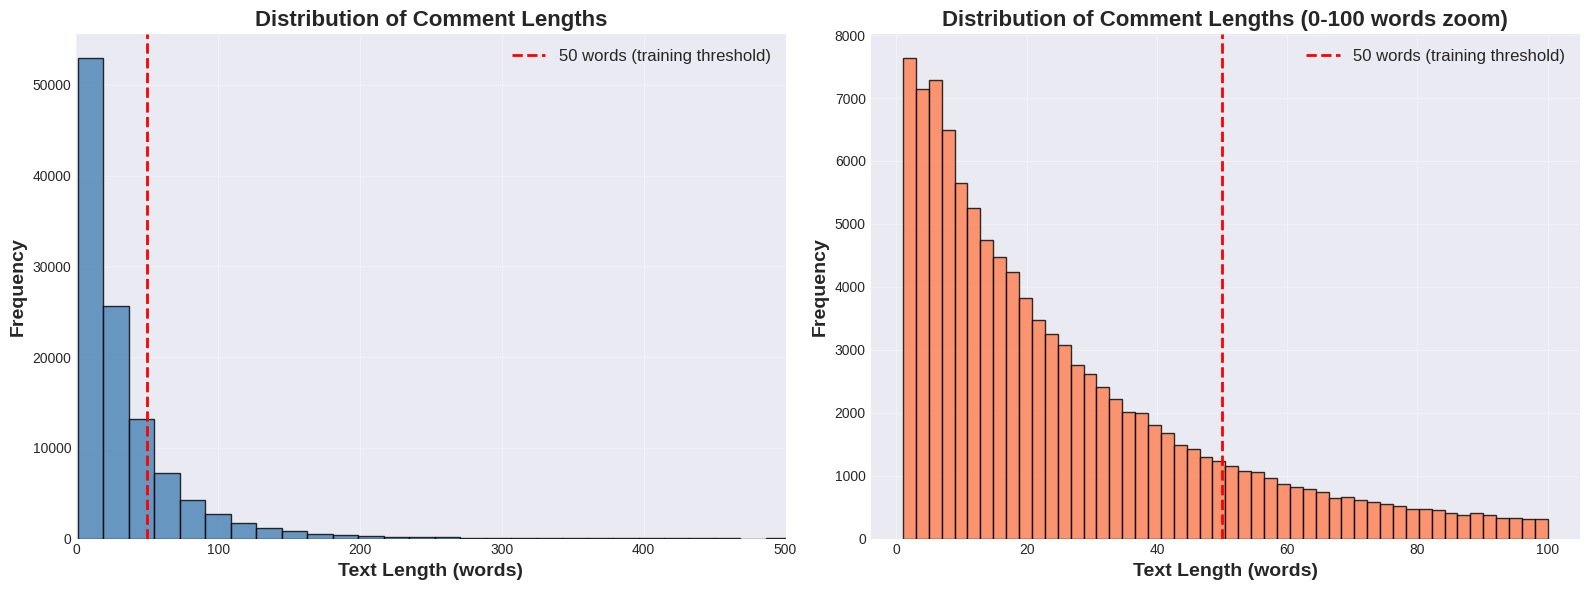


Comments by length category:
  <20       : 54,890 ( 49.0%)
  20-49     : 33,999 ( 30.4%)
  50-99     : 15,774 ( 14.1%)
  100-199   :  5,814 (  5.2%)
  200+      :  1,438 (  1.3%)

ANALYSIS 2: SYMPTOM PREVALENCE BY TEXT LENGTH

Symptom Prevalence (%) by Text Length:
                         <20      20-49      50-99    100-199       200+
Depressive Mood     0.003644   4.497191  17.852162  25.679395  26.495132
Insomnia            0.074695   1.397100   2.187143   1.307190   0.834492
Anhedonia          99.571871  66.399012  14.618993   5.710354   1.877608
Guilt               0.069229   4.053060  16.146824  29.807362  43.532684
Suicidal Ideation   0.191292  16.153416  34.106758  23.443412  16.411683


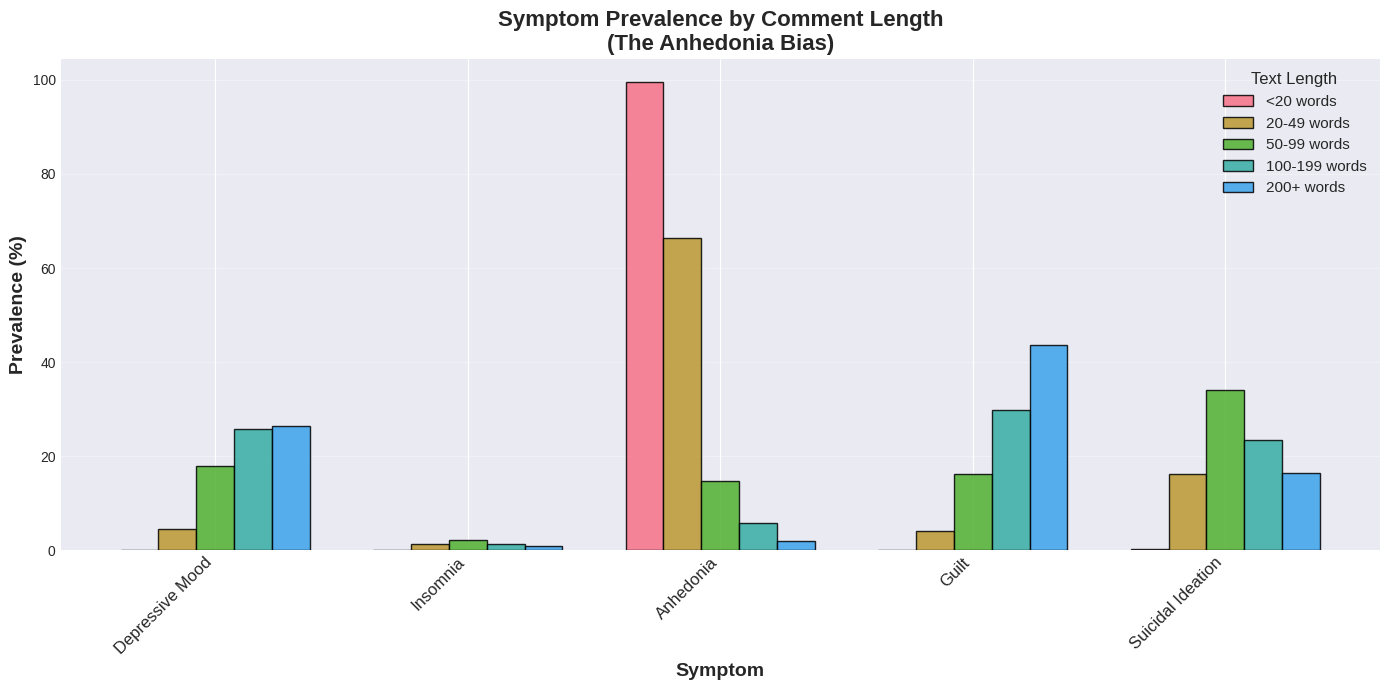


ANALYSIS 3: ANHEDONIA BIAS IN SHORT COMMENTS

Anhedonia Detection by Comment Length:
                   sum  count      mean  prevalence_pct
length_category                                        
<20              54655  54890  0.995719       99.571871
20-49            22575  33999  0.663990       66.399012
50-99             2306  15774  0.146190       14.618993
100-199            332   5814  0.057104        5.710354
200+                27   1438  0.018776        1.877608

🔴 THE ANHEDONIA PROBLEM:
  Comments <50 words:
    Total: 88,889
    Anhedonia detected: 77,230 (86.9%)

  Comments ≥50 words:
    Total: 23,026
    Anhedonia detected: 2,665 (11.6%)

  ⚠️  Anhedonia is 7.5x more likely in short comments!


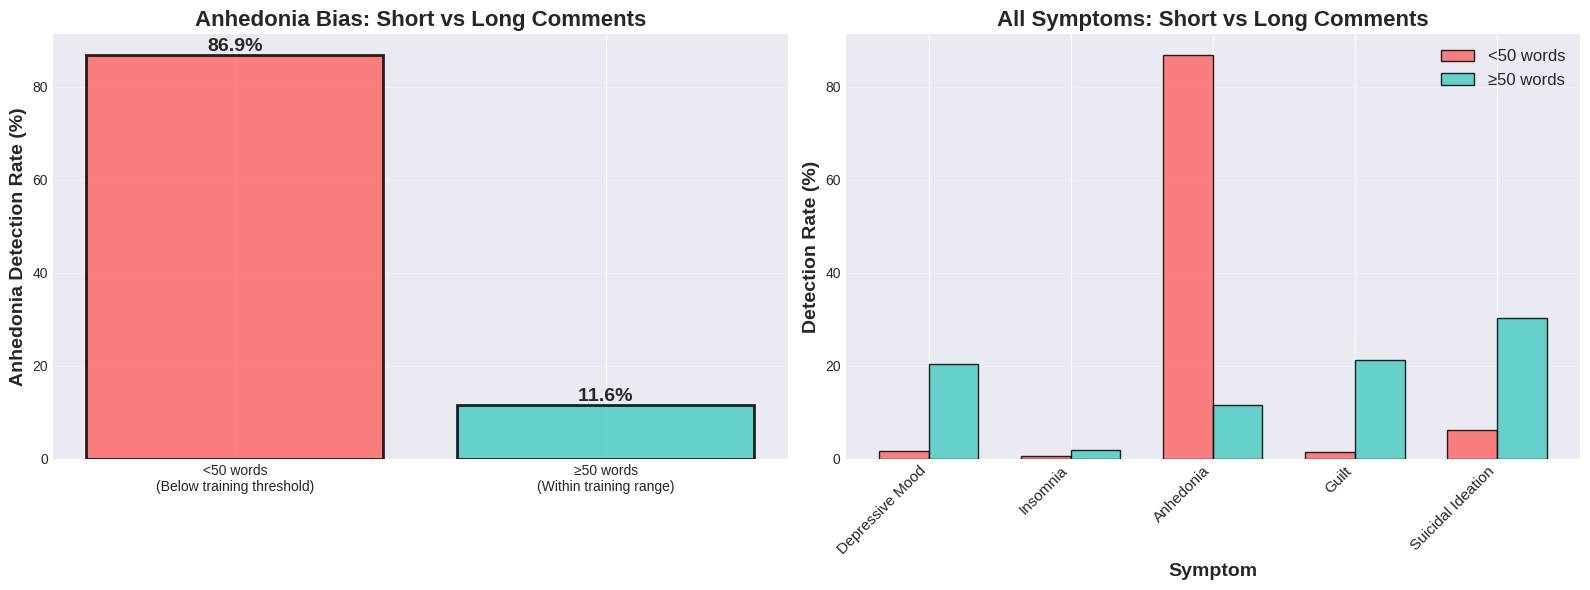


All symptoms comparison (short vs long):
                   Short (<50)  Long (≥50)
Depressive Mood       1.722373   20.368279
Insomnia              0.580499    1.880483
Anhedonia            86.883641   11.573873
Guilt                 1.592998   21.306349
Suicidal Ideation     6.296617   30.309216

ANALYSIS 4: EXAMPLES OF SHORT COMMENTS CLASSIFIED AS ANHEDONIA

Found 77,230 short comments (<50 words) classified as Anhedonia

10 SHORTEST examples classified as Anhedonia:

Length: 1 words | Prob: 0.981
Text: <3
----------------------------------------------------------------------

Length: 1 words | Prob: 0.987
Text: Thanks
----------------------------------------------------------------------

Length: 1 words | Prob: 0.987
Text: Thanks
----------------------------------------------------------------------

Length: 1 words | Prob: 0.989
Text: Thanks!!
----------------------------------------------------------------------

Length: 1 words | Prob: 0.986
Text: ?
---------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# LOAD COMMENTS DATA
# ============================================================

print("Loading OP comments...")
comments_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_with_probs.csv')

print(f"✓ Total OP comments: {len(comments_df):,}")

# ============================================================
# PREPARE DATA
# ============================================================

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']
symptom_names = ['Depressive Mood', 'Insomnia', 'Anhedonia', 'Guilt', 'Suicidal Ideation']

# Calculate text length
comments_df['text_length'] = comments_df['text'].str.split().str.len()
comments_df['total_symptoms'] = comments_df[symptom_pred_cols].sum(axis=1)

print(f"\nText length statistics:")
print(f"  Mean: {comments_df['text_length'].mean():.1f} words")
print(f"  Median: {comments_df['text_length'].median():.0f} words")
print(f"  Min: {comments_df['text_length'].min():.0f} words")
print(f"  Max: {comments_df['text_length'].max():.0f} words")
print(f"  Std: {comments_df['text_length'].std():.1f} words")

# ============================================================
# ANALYSIS 1: TEXT LENGTH DISTRIBUTION
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 1: TEXT LENGTH DISTRIBUTION")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall distribution
axes[0].hist(comments_df['text_length'], bins=100, color='steelblue',
             edgecolor='black', alpha=0.8)
axes[0].axvline(50, color='red', linestyle='--', linewidth=2,
                label='50 words (training threshold)')
axes[0].set_xlabel('Text Length (words)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[0].set_title('Distribution of Comment Lengths', fontsize=16, fontweight='bold')
axes[0].set_xlim(0, 500)
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3)

# Zoomed in (0-100 words)
axes[1].hist(comments_df[comments_df['text_length'] <= 100]['text_length'],
             bins=50, color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(50, color='red', linestyle='--', linewidth=2,
                label='50 words (training threshold)')
axes[1].set_xlabel('Text Length (words)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[1].set_title('Distribution of Comment Lengths (0-100 words zoom)',
                  fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Length categories
length_bins = [0, 20, 50, 100, 200, 10000]
length_labels = ['<20', '20-49', '50-99', '100-199', '200+']
comments_df['length_category'] = pd.cut(comments_df['text_length'],
                                         bins=length_bins,
                                         labels=length_labels,
                                         right=False)

print("\nComments by length category:")
for cat in length_labels:
    count = (comments_df['length_category'] == cat).sum()
    pct = (count / len(comments_df)) * 100
    print(f"  {cat:10s}: {count:6,} ({pct:5.1f}%)")

# ============================================================
# ANALYSIS 2: SYMPTOM PREVALENCE BY TEXT LENGTH
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 2: SYMPTOM PREVALENCE BY TEXT LENGTH")
print("="*70)

# Calculate prevalence by length category
prevalence_by_length = pd.DataFrame()

for cat in length_labels:
    subset = comments_df[comments_df['length_category'] == cat]
    prev = (subset[symptom_pred_cols].sum() / len(subset)) * 100
    prevalence_by_length[cat] = prev

prevalence_by_length.index = symptom_names

print("\nSymptom Prevalence (%) by Text Length:")
print(prevalence_by_length.to_string())

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(symptom_names))
width = 0.15

for i, cat in enumerate(length_labels):
    offset = (i - 2) * width
    bars = ax.bar(x + offset, prevalence_by_length[cat], width,
                   label=f'{cat} words', alpha=0.85, edgecolor='black')

ax.set_xlabel('Symptom', fontsize=14, fontweight='bold')
ax.set_ylabel('Prevalence (%)', fontsize=14, fontweight='bold')
ax.set_title('Symptom Prevalence by Comment Length\n(The Anhedonia Bias)',
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=11, title='Text Length', title_fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# ANALYSIS 3: ANHEDONIA FOCUS - THE PROBLEM
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 3: ANHEDONIA BIAS IN SHORT COMMENTS")
print("="*70)

# Anhedonia prevalence by length
anhedonia_by_length = comments_df.groupby('length_category')['Anhedonia_Pred'].agg(['sum', 'count', 'mean'])
anhedonia_by_length['prevalence_pct'] = anhedonia_by_length['mean'] * 100

print("\nAnhedonia Detection by Comment Length:")
print(anhedonia_by_length.to_string())

# Compare short vs long
short_comments = comments_df[comments_df['text_length'] < 50]
long_comments = comments_df[comments_df['text_length'] >= 50]

print(f"\n🔴 THE ANHEDONIA PROBLEM:")
print(f"  Comments <50 words:")
print(f"    Total: {len(short_comments):,}")
print(f"    Anhedonia detected: {short_comments['Anhedonia_Pred'].sum():,} ({short_comments['Anhedonia_Pred'].mean()*100:.1f}%)")

print(f"\n  Comments ≥50 words:")
print(f"    Total: {len(long_comments):,}")
print(f"    Anhedonia detected: {long_comments['Anhedonia_Pred'].sum():,} ({long_comments['Anhedonia_Pred'].mean()*100:.1f}%)")

print(f"\n  ⚠️  Anhedonia is {short_comments['Anhedonia_Pred'].mean() / long_comments['Anhedonia_Pred'].mean():.1f}x more likely in short comments!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prevalence comparison
categories = ['<50 words\n(Below training threshold)', '≥50 words\n(Within training range)']
anhedonia_rates = [short_comments['Anhedonia_Pred'].mean() * 100,
                   long_comments['Anhedonia_Pred'].mean() * 100]

bars = axes[0].bar(categories, anhedonia_rates,
                   color=['#ff6b6b', '#4ecdc4'], edgecolor='black', alpha=0.85, linewidth=2)
axes[0].set_ylabel('Anhedonia Detection Rate (%)', fontsize=14, fontweight='bold')
axes[0].set_title('Anhedonia Bias: Short vs Long Comments',
                  fontsize=16, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add values
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# All symptoms comparison (short vs long)
symptom_comparison = pd.DataFrame({
    'Short (<50)': (short_comments[symptom_pred_cols].mean() * 100).values,
    'Long (≥50)': (long_comments[symptom_pred_cols].mean() * 100).values
}, index=symptom_names)

x = np.arange(len(symptom_names))
width = 0.35

bars1 = axes[1].bar(x - width/2, symptom_comparison['Short (<50)'], width,
                    label='<50 words', color='#ff6b6b', edgecolor='black', alpha=0.85)
bars2 = axes[1].bar(x + width/2, symptom_comparison['Long (≥50)'], width,
                    label='≥50 words', color='#4ecdc4', edgecolor='black', alpha=0.85)

axes[1].set_xlabel('Symptom', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Detection Rate (%)', fontsize=14, fontweight='bold')
axes[1].set_title('All Symptoms: Short vs Long Comments',
                  fontsize=16, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
axes[1].legend(fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAll symptoms comparison (short vs long):")
print(symptom_comparison.to_string())

# ============================================================
# ANALYSIS 4: EXAMPLE SHORT COMMENTS WITH ANHEDONIA
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 4: EXAMPLES OF SHORT COMMENTS CLASSIFIED AS ANHEDONIA")
print("="*70)

# Get short comments classified as anhedonia
short_anhedonia = comments_df[
    (comments_df['text_length'] < 50) &
    (comments_df['Anhedonia_Pred'] == 1)
].copy()

print(f"\nFound {len(short_anhedonia):,} short comments (<50 words) classified as Anhedonia")

# Sort by text length
short_anhedonia = short_anhedonia.sort_values('text_length')

print("\n10 SHORTEST examples classified as Anhedonia:")
print("="*70)
for idx, row in short_anhedonia.head(10).iterrows():
    print(f"\nLength: {row['text_length']} words | Prob: {row['Anhedonia_Prob']:.3f}")
    print(f"Text: {row['text'][:200]}")
    print("-"*70)

# ============================================================
# ANALYSIS 5: SOLUTION - FILTER RECOMMENDATIONS
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 5: FILTERING RECOMMENDATIONS")
print("="*70)

print("\n🔧 RECOMMENDATION: Apply length-based filtering")

# Calculate impact of different thresholds
thresholds = [20, 30, 40, 50]

print("\nImpact of applying minimum length thresholds:")
print(f"{'Threshold':>12} | {'Removed':>10} | {'% Removed':>10} | {'Anhedonia Removed':>18} | {'% Anhedonia':>15}")
print("-" * 80)

for thresh in thresholds:
    removed = (comments_df['text_length'] < thresh).sum()
    removed_pct = (removed / len(comments_df)) * 100
    anhedonia_removed = comments_df[
        (comments_df['text_length'] < thresh) &
        (comments_df['Anhedonia_Pred'] == 1)
    ].shape[0]
    anhedonia_pct = (anhedonia_removed / comments_df['Anhedonia_Pred'].sum()) * 100

    print(f"{thresh:>12} | {removed:>10,} | {removed_pct:>9.1f}% | {anhedonia_removed:>18,} | {anhedonia_pct:>14.1f}%")

print("\n✅ SUGGESTED APPROACH:")
print("  1. Apply 50-word minimum threshold to comments (match training data)")
print("  2. Alternatively: Apply threshold only for anhedonia predictions")
print("  3. OR: Retrain model with consistent length filtering across all symptoms")

# ============================================================
# ANALYSIS 6: FILTERED DATASET PREVIEW
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 6: CREATING FILTERED DATASET")
print("="*70)

# Apply 50-word threshold
comments_filtered = comments_df[comments_df['text_length'] >= 50].copy()

print(f"\nOriginal comments: {len(comments_df):,}")
print(f"Filtered comments (≥50 words): {len(comments_filtered):,}")
print(f"Removed: {len(comments_df) - len(comments_filtered):,} ({(len(comments_df) - len(comments_filtered))/len(comments_df)*100:.1f}%)")

print("\nSymptom prevalence comparison:")
print(f"{'Symptom':25s} | {'Original (%)':>15} | {'Filtered (%)':>15} | {'Change':>10}")
print("-" * 75)

for i, sym in enumerate(symptom_names):
    orig_prev = (comments_df[symptom_pred_cols[i]].sum() / len(comments_df)) * 100
    filt_prev = (comments_filtered[symptom_pred_cols[i]].sum() / len(comments_filtered)) * 100
    change = filt_prev - orig_prev

    print(f"{sym:25s} | {orig_prev:>14.1f}% | {filt_prev:>14.1f}% | {change:>+9.1f}%")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE!")
print("="*70)
print("\n🔴 KEY FINDING: Anhedonia is significantly over-predicted in short comments")
print("   due to inconsistent length filtering during training.")
print("\n💡 SOLUTION: Apply 50-word minimum threshold to align with training data")

Loading data...
✓ Posts with OP comments: 35,792
✓ Total OP comments (raw): 111,915
✓ Filtered OP comments (≥50 words): 23,026

ANALYSIS 1: SYMPTOM COUNT DISTRIBUTION


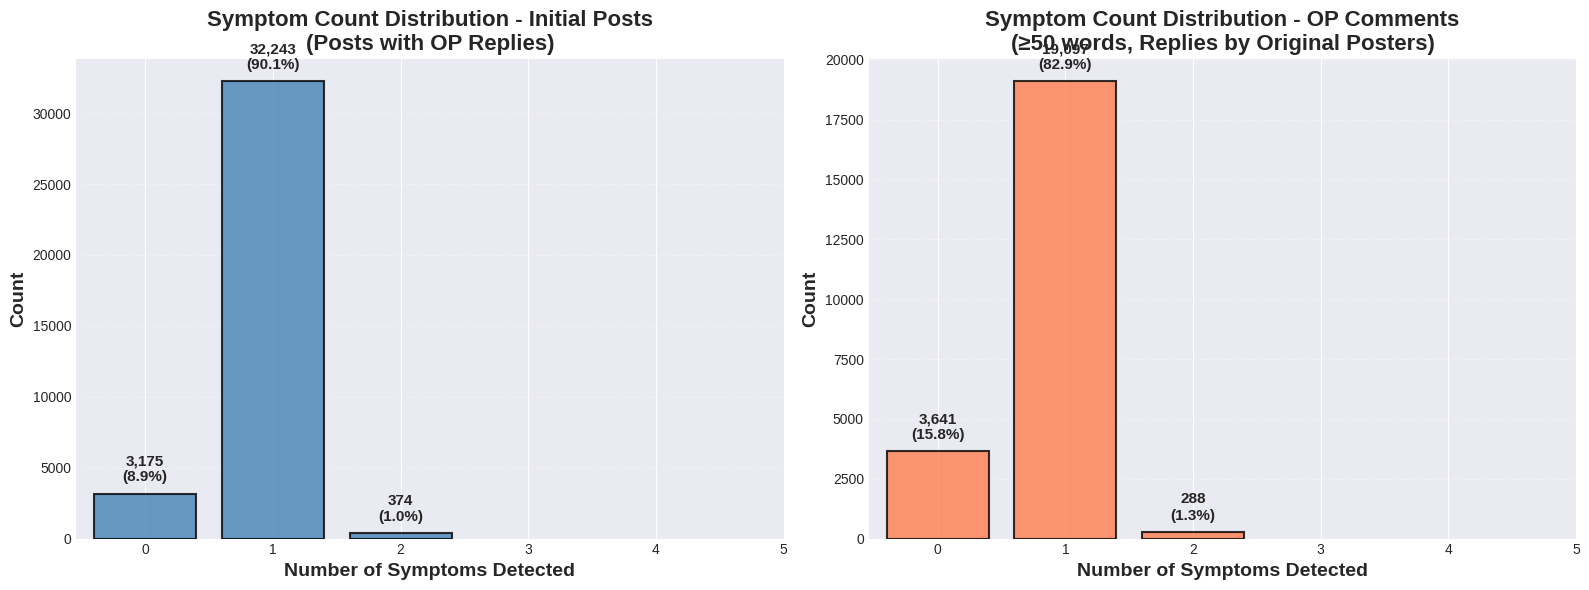


POSTS (Initial):
  0 symptoms: 3,175 (8.9%)
  1 symptoms: 32,243 (90.1%)
  2 symptoms: 374 (1.0%)
  3 symptoms: 0 (0.0%)
  4 symptoms: 0 (0.0%)
  5 symptoms: 0 (0.0%)

  Posts with ≥1 symptom: 32,617 (91.1%)
  Posts with ≥2 symptoms: 374 (1.0%)
  Average symptoms per post: 0.92

OP COMMENTS (Replies, ≥50 words):
  0 symptoms: 3,641 (15.8%)
  1 symptoms: 19,097 (82.9%)
  2 symptoms: 288 (1.3%)
  3 symptoms: 0 (0.0%)
  4 symptoms: 0 (0.0%)
  5 symptoms: 0 (0.0%)

  Comments with ≥1 symptom: 19,385 (84.2%)
  Comments with ≥2 symptoms: 288 (1.3%)
  Average symptoms per comment: 0.85

ANALYSIS 2: SYMPTOM PREVALENCE COMPARISON

          Symptom  Posts_Count  Posts_Pct  Comments_Count  Comments_Pct  Change_Pct
  Depressive Mood        15804  44.155118            4690     20.368279  -23.786839
         Insomnia          469   1.310349             433      1.880483    0.570134
        Anhedonia          884   2.469826            2665     11.573873    9.104047
            Guilt         4063  1

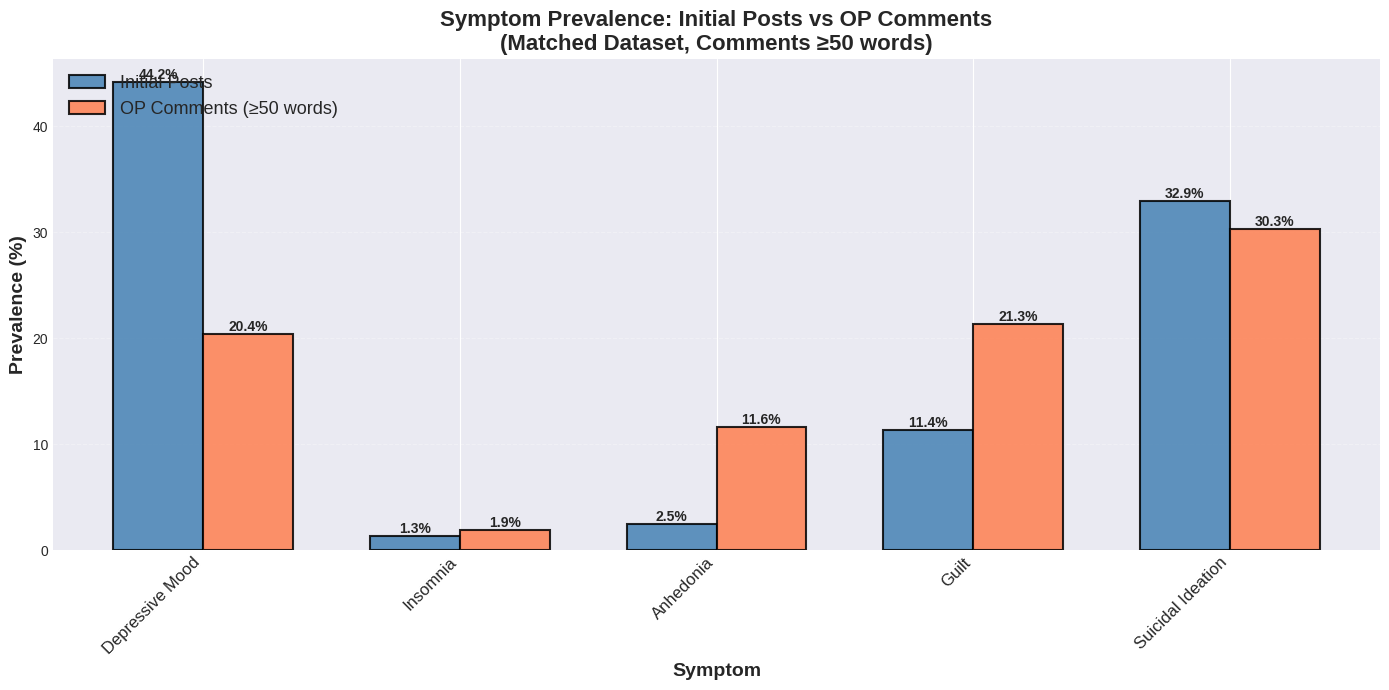


ANALYSIS 3: SYMPTOM CO-OCCURRENCE PATTERNS


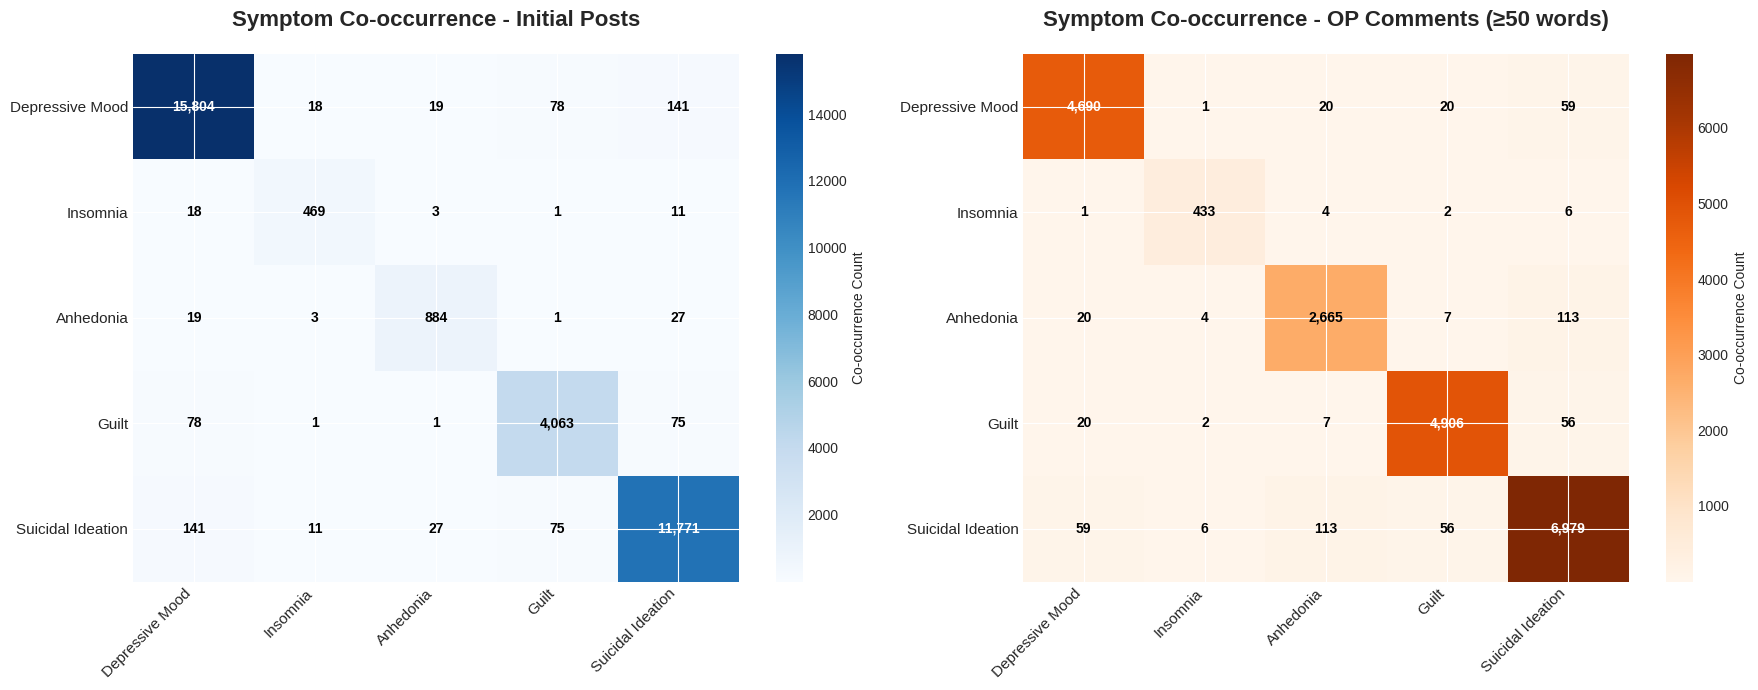


Top Co-occurring Symptom Pairs (Posts):
  Depressive Mood + Suicidal Ideation: 141 (0.4%)
  Depressive Mood + Guilt: 78 (0.2%)
  Guilt + Suicidal Ideation: 75 (0.2%)
  Anhedonia + Suicidal Ideation: 27 (0.1%)
  Depressive Mood + Anhedonia: 19 (0.1%)

Top Co-occurring Symptom Pairs (Comments):
  Anhedonia + Suicidal Ideation: 113 (0.5%)
  Depressive Mood + Suicidal Ideation: 59 (0.3%)
  Guilt + Suicidal Ideation: 56 (0.2%)
  Depressive Mood + Anhedonia: 20 (0.1%)
  Depressive Mood + Guilt: 20 (0.1%)

ANALYSIS 4: ENGAGEMENT ANALYSIS (≥50 word comments)

Posts with at least 1 comment (≥50 words): 12,219
Comment engagement statistics (for posts with ≥1 comment):
  Mean comments per post: 1.55
  Median comments per post: 1
  Max comments per post: 54
  Min comments per post: 1
  Std dev: 1.41


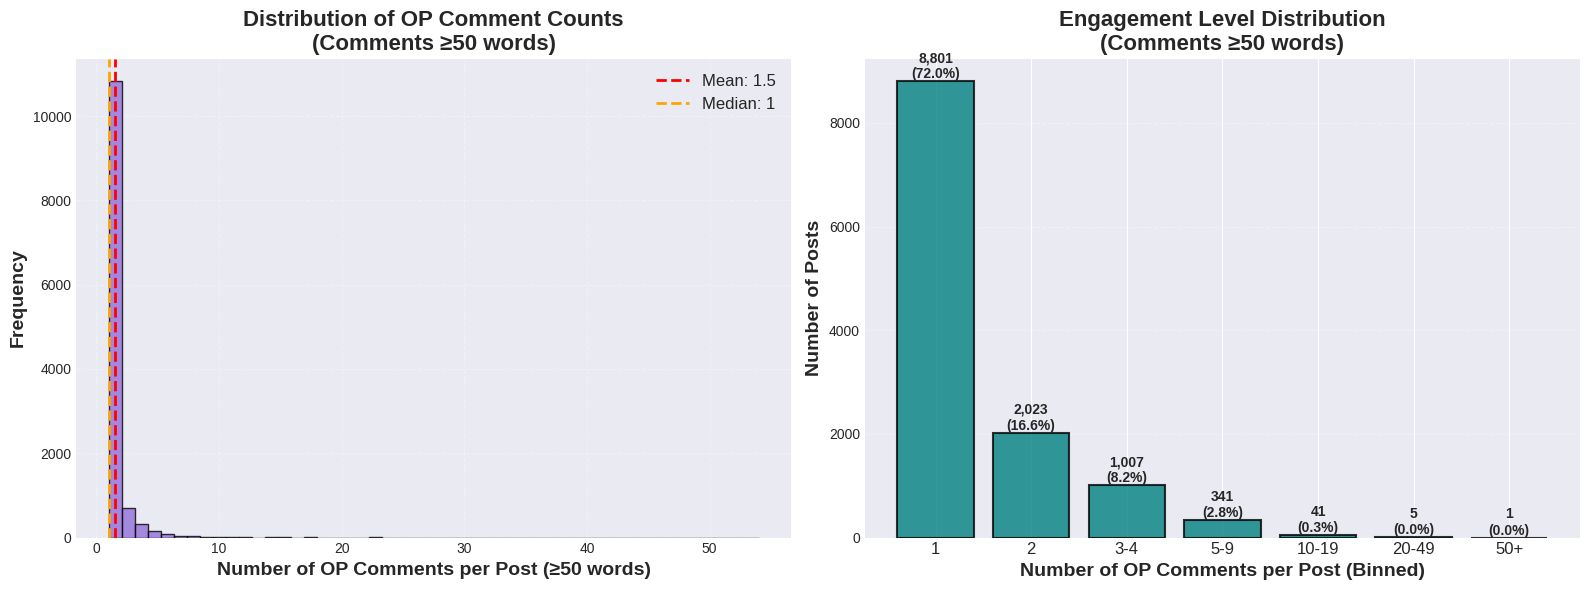


Engagement bins:
  1 comments: 8,801 posts (72.0%)
  2 comments: 2,023 posts (16.6%)
  3-4 comments: 1,007 posts (8.2%)
  5-9 comments: 341 posts (2.8%)
  10-19 comments: 41 posts (0.3%)
  20-49 comments: 5 posts (0.0%)
  50+ comments: 1 posts (0.0%)

SUMMARY STATISTICS

                           Metric           Initial Posts   OP Comments (≥50 words)
                    Total Records                  35,792                    23,026
          Avg Symptoms per Record                    0.92                      0.85
          Records with 0 symptoms            3,175 (8.9%)             3,641 (15.8%)
           Records with 1 symptom          32,243 (90.1%)            19,097 (82.9%)
         Records with 2+ symptoms              374 (1.0%)                288 (1.3%)
              Most Common Symptom Depressive Mood (44.2%) Suicidal Ideation (30.3%)
             Least Common Symptom         Insomnia (1.3%)           Insomnia (1.9%)
Avg Comments per Post (≥50 words)                    1.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# LOAD AND FILTER DATA
# ============================================================

print("Loading data...")
posts_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_posts_with_OP_comments.csv')
comments_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_with_probs.csv')

print(f"✓ Posts with OP comments: {len(posts_df):,}")
print(f"✓ Total OP comments (raw): {len(comments_df):,}")

# APPLY 50-WORD FILTER TO COMMENTS
comments_df['text_length'] = comments_df['text'].str.split().str.len()
comments_df = comments_df[comments_df['text_length'] >= 50].copy()

print(f"✓ Filtered OP comments (≥50 words): {len(comments_df):,}")

# ============================================================
# PREPARE SYMPTOM COLUMNS
# ============================================================

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']
symptom_prob_cols = ['Depressive_Mood_Prob', 'Insomnia_Prob', 'Anhedonia_Prob',
                     'Guilt_Prob', 'Suicidal_Ideation_Prob']
symptom_names = ['Depressive Mood', 'Insomnia', 'Anhedonia', 'Guilt', 'Suicidal Ideation']

# Calculate total symptoms
posts_df['total_symptoms'] = posts_df[symptom_pred_cols].sum(axis=1)
comments_df['total_symptoms'] = comments_df[symptom_pred_cols].sum(axis=1)

# ============================================================
# ANALYSIS 1: SYMPTOM COUNT DISTRIBUTION
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 1: SYMPTOM COUNT DISTRIBUTION")
print("="*70)

posts_symptom_dist = posts_df['total_symptoms'].value_counts().sort_index()
comments_symptom_dist = comments_df['total_symptoms'].value_counts().sort_index()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Posts
axes[0].bar(posts_symptom_dist.index, posts_symptom_dist.values,
            color='steelblue', edgecolor='black', alpha=0.8, linewidth=1.5)
axes[0].set_xlabel('Number of Symptoms Detected', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=14, fontweight='bold')
axes[0].set_title('Symptom Count Distribution - Initial Posts\n(Posts with OP Replies)',
                  fontsize=16, fontweight='bold')
axes[0].set_xticks(range(0, 6))
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add counts and percentages
for i, v in enumerate(posts_symptom_dist.values):
    pct = (v / len(posts_df)) * 100
    axes[0].text(posts_symptom_dist.index[i], v + max(posts_symptom_dist.values)*0.02,
                f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Comments
axes[1].bar(comments_symptom_dist.index, comments_symptom_dist.values,
            color='coral', edgecolor='black', alpha=0.8, linewidth=1.5)
axes[1].set_xlabel('Number of Symptoms Detected', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=14, fontweight='bold')
axes[1].set_title('Symptom Count Distribution - OP Comments\n(≥50 words, Replies by Original Posters)',
                  fontsize=16, fontweight='bold')
axes[1].set_xticks(range(0, 6))
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add counts and percentages
for i, v in enumerate(comments_symptom_dist.values):
    pct = (v / len(comments_df)) * 100
    axes[1].text(comments_symptom_dist.index[i], v + max(comments_symptom_dist.values)*0.02,
                f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Print statistics
print("\nPOSTS (Initial):")
for i in range(6):
    count = posts_symptom_dist.get(i, 0)
    pct = (count / len(posts_df)) * 100
    print(f"  {i} symptoms: {count:,} ({pct:.1f}%)")

print(f"\n  Posts with ≥1 symptom: {(posts_df['total_symptoms'] >= 1).sum():,} ({(posts_df['total_symptoms'] >= 1).sum()/len(posts_df)*100:.1f}%)")
print(f"  Posts with ≥2 symptoms: {(posts_df['total_symptoms'] >= 2).sum():,} ({(posts_df['total_symptoms'] >= 2).sum()/len(posts_df)*100:.1f}%)")
print(f"  Average symptoms per post: {posts_df['total_symptoms'].mean():.2f}")

print("\nOP COMMENTS (Replies, ≥50 words):")
for i in range(6):
    count = comments_symptom_dist.get(i, 0)
    pct = (count / len(comments_df)) * 100
    print(f"  {i} symptoms: {count:,} ({pct:.1f}%)")

print(f"\n  Comments with ≥1 symptom: {(comments_df['total_symptoms'] >= 1).sum():,} ({(comments_df['total_symptoms'] >= 1).sum()/len(comments_df)*100:.1f}%)")
print(f"  Comments with ≥2 symptoms: {(comments_df['total_symptoms'] >= 2).sum():,} ({(comments_df['total_symptoms'] >= 2).sum()/len(comments_df)*100:.1f}%)")
print(f"  Average symptoms per comment: {comments_df['total_symptoms'].mean():.2f}")

# ============================================================
# ANALYSIS 2: INDIVIDUAL SYMPTOM PREVALENCE
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 2: SYMPTOM PREVALENCE COMPARISON")
print("="*70)

# Calculate prevalence
posts_prevalence = posts_df[symptom_pred_cols].sum()
comments_prevalence = comments_df[symptom_pred_cols].sum()

posts_prevalence_pct = (posts_prevalence / len(posts_df)) * 100
comments_prevalence_pct = (comments_prevalence / len(comments_df)) * 100

# Create comparison dataframe
prevalence_df = pd.DataFrame({
    'Symptom': symptom_names,
    'Posts_Count': posts_prevalence.values,
    'Posts_Pct': posts_prevalence_pct.values,
    'Comments_Count': comments_prevalence.values,
    'Comments_Pct': comments_prevalence_pct.values,
    'Change_Pct': comments_prevalence_pct.values - posts_prevalence_pct.values
})

print("\n" + prevalence_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(symptom_names))
width = 0.35

bars1 = ax.bar(x - width/2, prevalence_df['Posts_Pct'], width,
               label='Initial Posts', color='steelblue', edgecolor='black', alpha=0.85, linewidth=1.5)
bars2 = ax.bar(x + width/2, prevalence_df['Comments_Pct'], width,
               label='OP Comments (≥50 words)', color='coral', edgecolor='black', alpha=0.85, linewidth=1.5)

ax.set_xlabel('Symptom', fontsize=14, fontweight='bold')
ax.set_ylabel('Prevalence (%)', fontsize=14, fontweight='bold')
ax.set_title('Symptom Prevalence: Initial Posts vs OP Comments\n(Matched Dataset, Comments ≥50 words)',
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=13, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# ANALYSIS 3: SYMPTOM CO-OCCURRENCE MATRIX
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 3: SYMPTOM CO-OCCURRENCE PATTERNS")
print("="*70)

def calculate_cooccurrence(df, symptom_cols):
    """Calculate symptom co-occurrence matrix"""
    cooc_matrix = np.zeros((5, 5))
    for i in range(5):
        for j in range(5):
            both = ((df[symptom_cols[i]] == 1) & (df[symptom_cols[j]] == 1)).sum()
            cooc_matrix[i, j] = both
    return cooc_matrix

posts_cooc = calculate_cooccurrence(posts_df, symptom_pred_cols)
comments_cooc = calculate_cooccurrence(comments_df, symptom_pred_cols)

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Posts
im1 = axes[0].imshow(posts_cooc, cmap='Blues', aspect='auto')
axes[0].set_xticks(np.arange(5))
axes[0].set_yticks(np.arange(5))
axes[0].set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
axes[0].set_yticklabels(symptom_names, fontsize=11)
axes[0].set_title('Symptom Co-occurrence - Initial Posts', fontsize=16, fontweight='bold', pad=20)

# Add text annotations
for i in range(5):
    for j in range(5):
        text = axes[0].text(j, i, f'{int(posts_cooc[i, j]):,}',
                           ha="center", va="center", color="white" if posts_cooc[i, j] > posts_cooc.max()/2 else "black",
                           fontsize=10, fontweight='bold')

fig.colorbar(im1, ax=axes[0], label='Co-occurrence Count')

# Comments
im2 = axes[1].imshow(comments_cooc, cmap='Oranges', aspect='auto')
axes[1].set_xticks(np.arange(5))
axes[1].set_yticks(np.arange(5))
axes[1].set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
axes[1].set_yticklabels(symptom_names, fontsize=11)
axes[1].set_title('Symptom Co-occurrence - OP Comments (≥50 words)', fontsize=16, fontweight='bold', pad=20)

# Add text annotations
for i in range(5):
    for j in range(5):
        text = axes[1].text(j, i, f'{int(comments_cooc[i, j]):,}',
                           ha="center", va="center", color="white" if comments_cooc[i, j] > comments_cooc.max()/2 else "black",
                           fontsize=10, fontweight='bold')

fig.colorbar(im2, ax=axes[1], label='Co-occurrence Count')

plt.tight_layout()
plt.show()

# Print top co-occurrences (excluding diagonal)
print("\nTop Co-occurring Symptom Pairs (Posts):")
cooc_pairs_posts = []
for i in range(5):
    for j in range(i+1, 5):
        cooc_pairs_posts.append((symptom_names[i], symptom_names[j], int(posts_cooc[i, j])))
cooc_pairs_posts.sort(key=lambda x: x[2], reverse=True)
for sym1, sym2, count in cooc_pairs_posts[:5]:
    pct = (count / len(posts_df)) * 100
    print(f"  {sym1} + {sym2}: {count:,} ({pct:.1f}%)")

print("\nTop Co-occurring Symptom Pairs (Comments):")
cooc_pairs_comments = []
for i in range(5):
    for j in range(i+1, 5):
        cooc_pairs_comments.append((symptom_names[i], symptom_names[j], int(comments_cooc[i, j])))
cooc_pairs_comments.sort(key=lambda x: x[2], reverse=True)
for sym1, sym2, count in cooc_pairs_comments[:5]:
    pct = (count / len(comments_df)) * 100
    print(f"  {sym1} + {sym2}: {count:,} ({pct:.1f}%)")

# ============================================================
# ANALYSIS 4: COMMENTS PER POST DISTRIBUTION
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 4: ENGAGEMENT ANALYSIS (≥50 word comments)")
print("="*70)

# Count comments per post
comments_per_post = comments_df.groupby('link_id').size().reset_index(name='comment_count')

# Merge with posts
posts_with_count = posts_df.merge(
    comments_per_post,
    left_on='id',
    right_on='link_id',
    how='left'
)

# Fill NaN with 0 (posts with no comments ≥50 words)
posts_with_count['comment_count'] = posts_with_count['comment_count'].fillna(0).astype(int)

# Only analyze posts with at least 1 comment ≥50 words
posts_with_comments = posts_with_count[posts_with_count['comment_count'] > 0]

print(f"\nPosts with at least 1 comment (≥50 words): {len(posts_with_comments):,}")
print(f"Comment engagement statistics (for posts with ≥1 comment):")
print(f"  Mean comments per post: {posts_with_comments['comment_count'].mean():.2f}")
print(f"  Median comments per post: {posts_with_comments['comment_count'].median():.0f}")
print(f"  Max comments per post: {posts_with_comments['comment_count'].max():.0f}")
print(f"  Min comments per post: {posts_with_comments['comment_count'].min():.0f}")
print(f"  Std dev: {posts_with_comments['comment_count'].std():.2f}")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(posts_with_comments['comment_count'], bins=50,
             color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Number of OP Comments per Post (≥50 words)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[0].set_title('Distribution of OP Comment Counts\n(Comments ≥50 words)', fontsize=16, fontweight='bold')
axes[0].axvline(posts_with_comments['comment_count'].mean(),
                color='red', linestyle='--', linewidth=2, label=f'Mean: {posts_with_comments["comment_count"].mean():.1f}')
axes[0].axvline(posts_with_comments['comment_count'].median(),
                color='orange', linestyle='--', linewidth=2, label=f'Median: {posts_with_comments["comment_count"].median():.0f}')
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3, linestyle='--')

# Binned bar chart
bins = [1, 2, 3, 5, 10, 20, 50, 1000]
labels = ['1', '2', '3-4', '5-9', '10-19', '20-49', '50+']
posts_with_comments['comment_bin'] = pd.cut(posts_with_comments['comment_count'],
                                              bins=bins, labels=labels, right=False)
bin_counts = posts_with_comments['comment_bin'].value_counts().sort_index()

axes[1].bar(range(len(bin_counts)), bin_counts.values,
            color='teal', edgecolor='black', alpha=0.8, linewidth=1.5)
axes[1].set_xlabel('Number of OP Comments per Post (Binned)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Posts', fontsize=14, fontweight='bold')
axes[1].set_title('Engagement Level Distribution\n(Comments ≥50 words)', fontsize=16, fontweight='bold')
axes[1].set_xticks(range(len(bin_counts)))
axes[1].set_xticklabels(bin_counts.index, fontsize=12)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add counts
for i, v in enumerate(bin_counts.values):
    pct = (v / len(posts_with_comments)) * 100
    axes[1].text(i, v, f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\nEngagement bins:")
for label, count in bin_counts.items():
    pct = (count / len(posts_with_comments)) * 100
    print(f"  {label} comments: {count:,} posts ({pct:.1f}%)")

# ============================================================
# ANALYSIS 5: SUMMARY TABLE
# ============================================================

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

summary_stats = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Avg Symptoms per Record',
        'Records with 0 symptoms',
        'Records with 1 symptom',
        'Records with 2+ symptoms',
        'Most Common Symptom',
        'Least Common Symptom',
        'Avg Comments per Post (≥50 words)'
    ],
    'Initial Posts': [
        f"{len(posts_df):,}",
        f"{posts_df['total_symptoms'].mean():.2f}",
        f"{(posts_df['total_symptoms'] == 0).sum():,} ({(posts_df['total_symptoms'] == 0).sum()/len(posts_df)*100:.1f}%)",
        f"{(posts_df['total_symptoms'] == 1).sum():,} ({(posts_df['total_symptoms'] == 1).sum()/len(posts_df)*100:.1f}%)",
        f"{(posts_df['total_symptoms'] >= 2).sum():,} ({(posts_df['total_symptoms'] >= 2).sum()/len(posts_df)*100:.1f}%)",
        f"{symptom_names[posts_prevalence.argmax()]} ({posts_prevalence_pct.max():.1f}%)",
        f"{symptom_names[posts_prevalence.argmin()]} ({posts_prevalence_pct.min():.1f}%)",
        f"{posts_with_comments['comment_count'].mean():.2f}"
    ],
    'OP Comments (≥50 words)': [
        f"{len(comments_df):,}",
        f"{comments_df['total_symptoms'].mean():.2f}",
        f"{(comments_df['total_symptoms'] == 0).sum():,} ({(comments_df['total_symptoms'] == 0).sum()/len(comments_df)*100:.1f}%)",
        f"{(comments_df['total_symptoms'] == 1).sum():,} ({(comments_df['total_symptoms'] == 1).sum()/len(comments_df)*100:.1f}%)",
        f"{(comments_df['total_symptoms'] >= 2).sum():,} ({(comments_df['total_symptoms'] >= 2).sum()/len(comments_df)*100:.1f}%)",
        f"{symptom_names[comments_prevalence.argmax()]} ({comments_prevalence_pct.max():.1f}%)",
        f"{symptom_names[comments_prevalence.argmin()]} ({comments_prevalence_pct.min():.1f}%)",
        "N/A"
    ]
})

print("\n" + summary_stats.to_string(index=False))

# Save filtered comments for temporal analysis
print("\n" + "="*70)
print("SAVING FILTERED DATASET")
print("="*70)
comments_df.to_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_filtered_50words.csv', index=False)
print("✓ Saved: depression_comments_filtered_50words.csv")

print("\n" + "="*70)
print("✅ ALL ANALYSES COMPLETE!")
print("="*70)

TEMPORAL ANALYSIS: POST → COMMENT SYMPTOM CHANGES

Loading data...
✓ Posts: 35,792
✓ Comments (≥50 words): 23,026

✓ Posts with ≥3 comments: 1,395
✓ Comments for these posts: 7,397

ANALYSIS 1: SYMPTOM COUNT TRAJECTORY

Trajectory Distribution:
  Improving      :    78 (  5.6%)
  Stable         : 1,211 ( 86.8%)
  Deteriorating  :   106 (  7.6%)

Average symptom change: -0.070
Median symptom change: 0.000


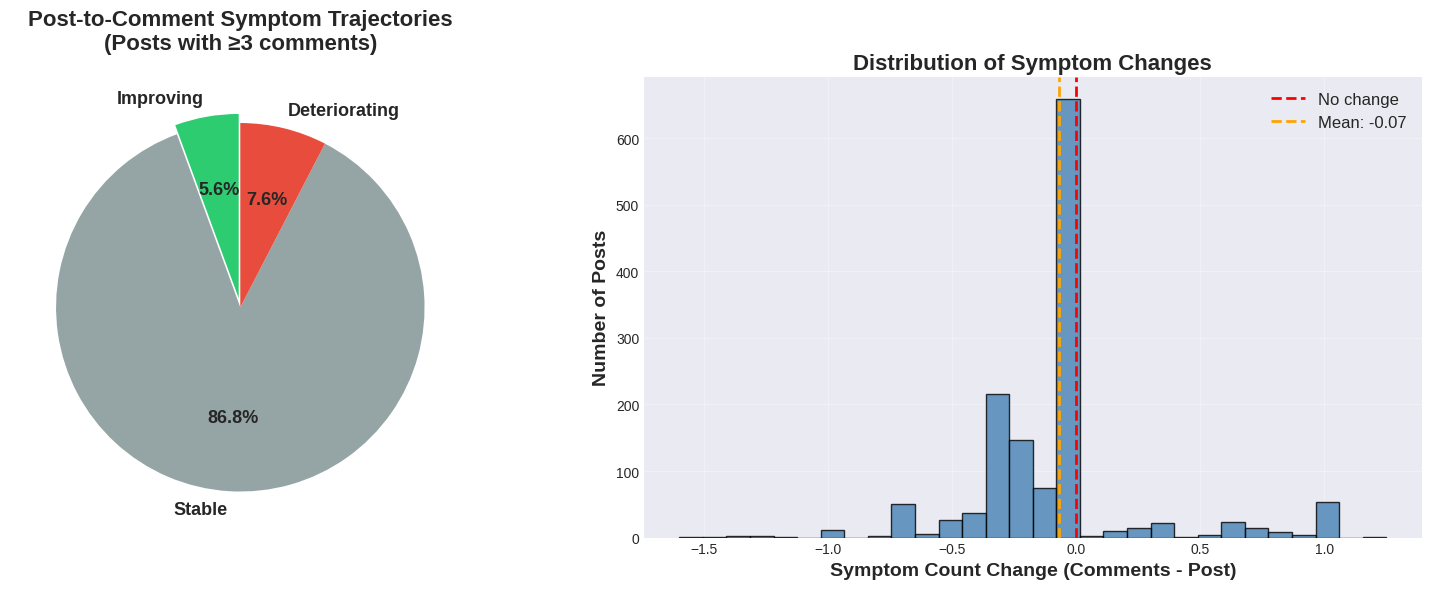


ANALYSIS 2: SYMPTOM PERSISTENCE RATES

Symptom Persistence Analysis:
          Symptom  Posts_with_symptom  Persistent  Resolved  Persistence_Rate  Resolution_Rate
  Depressive Mood                 582         129       453         22.164948        77.835052
         Insomnia                  12           4         8         33.333333        66.666667
        Anhedonia                  26          10        16         38.461538        61.538462
            Guilt                 187          89        98         47.593583        52.406417
Suicidal Ideation                 489         218       271         44.580777        55.419223


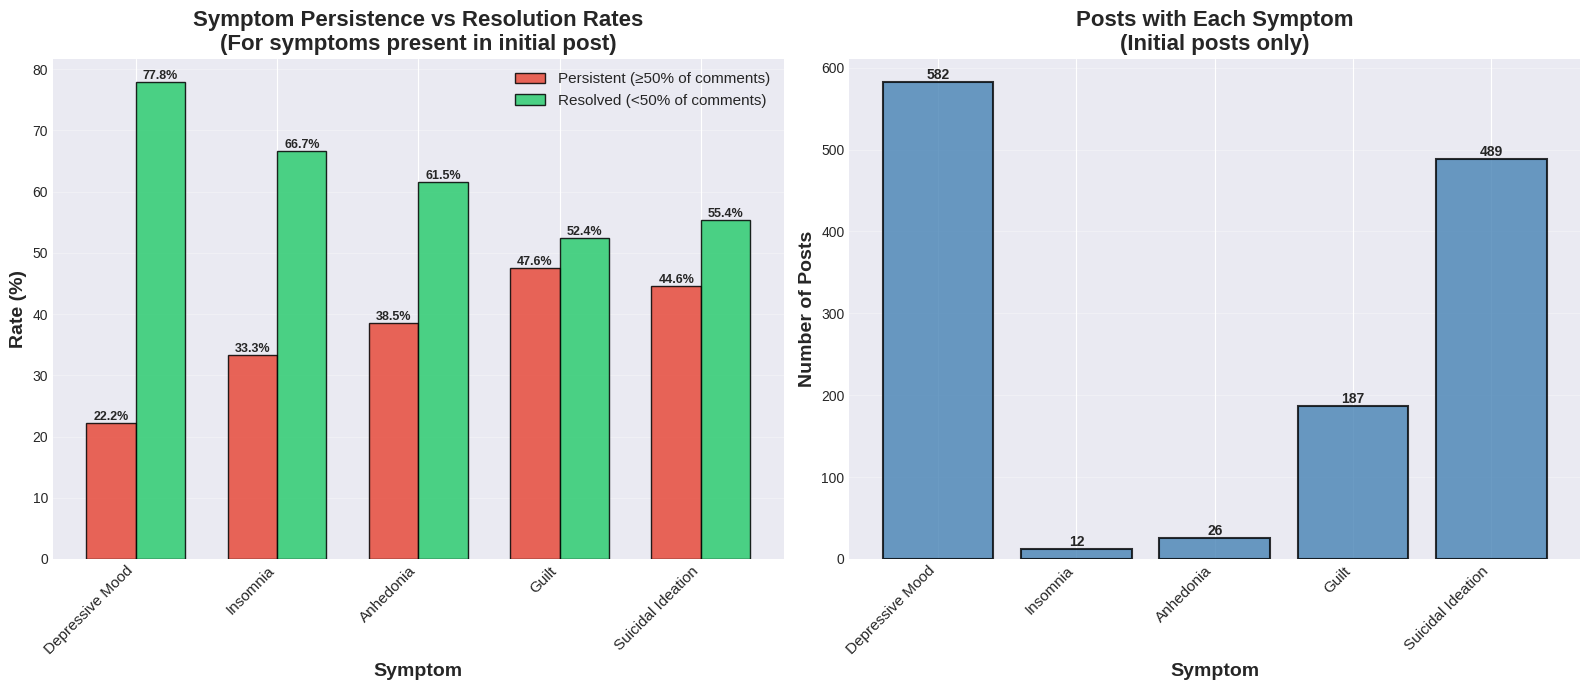


ANALYSIS 3: SYMPTOM EMERGENCE (NEW SYMPTOMS)

Symptom Emergence Analysis:
          Symptom  Posts_without_symptom  Emerged  Stayed_Absent  Emergence_Rate
  Depressive Mood                    813       62            751        7.626076
         Insomnia                   1383        8           1375        0.578453
        Anhedonia                   1369       74           1295        5.405405
            Guilt                   1208      193           1015       15.976821
Suicidal Ideation                    906      158            748       17.439294


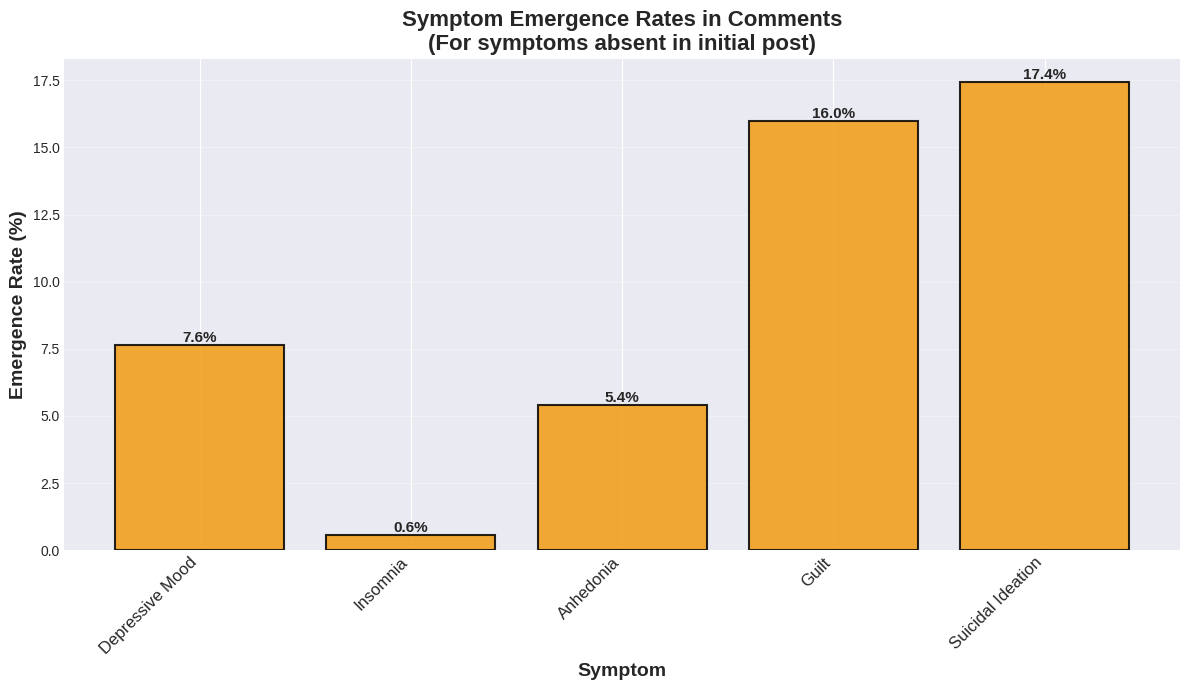


ANALYSIS 4: ENGAGEMENT EFFECT

Engagement Level Analysis:
Engagement_Level  Improvement_Rate  Post_Count  Avg_Symptom_Change
    3-5 comments          6.250000        1168           -0.075813
   6-10 comments          2.631579         190           -0.036452
    11+ comments          0.000000          37           -0.051399

Correlation Analysis:
  Spearman correlation (comment count vs symptom change): r=-0.025, p=0.3413
  ✗ Not statistically significant (p ≥ 0.05)


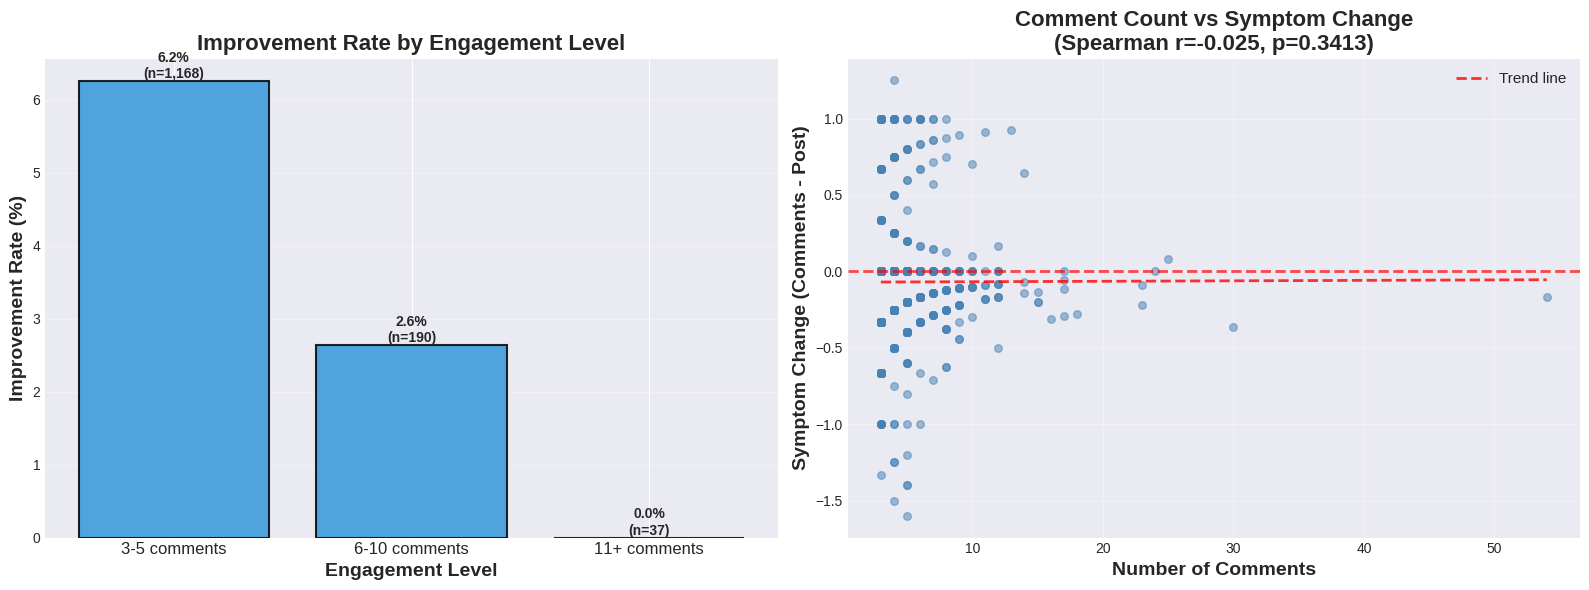


SUMMARY STATISTICS

                            Metric                     Value
Total Posts Analyzed (≥3 comments)                     1,395
           Total Comments Analyzed                     7,397
             Avg Comments per Post                      4.32
                                                            
          Trajectory Distribution:                          
                       - Improving                 78 (5.6%)
                          - Stable             1,211 (86.8%)
                   - Deteriorating                106 (7.6%)
                                                            
            Average Symptom Change                    -0.070
   Posts with Net Symptom Decrease               579 (41.5%)
   Posts with Net Symptom Increase               159 (11.4%)
                                                            
           Most Persistent Symptom             Guilt (47.6%)
             Most Resolved Symptom   Depressive Mood (77.8%)
   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# LOAD FILTERED DATA
# ============================================================

print("="*70)
print("TEMPORAL ANALYSIS: POST → COMMENT SYMPTOM CHANGES")
print("="*70)

print("\nLoading data...")
posts_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_posts_with_OP_comments.csv')
comments_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_filtered_50words.csv')

print(f"✓ Posts: {len(posts_df):,}")
print(f"✓ Comments (≥50 words): {len(comments_df):,}")

# ============================================================
# FILTER: POSTS WITH ≥3 COMMENTS
# ============================================================

# Count comments per post
comments_per_post = comments_df.groupby('link_id').size().reset_index(name='comment_count')

# Filter posts with ≥3 comments
posts_with_3plus = comments_per_post[comments_per_post['comment_count'] >= 3]['link_id']
posts_filtered = posts_df[posts_df['id'].isin(posts_with_3plus)].copy()
comments_filtered = comments_df[comments_df['link_id'].isin(posts_with_3plus)].copy()

print(f"\n✓ Posts with ≥3 comments: {len(posts_filtered):,}")
print(f"✓ Comments for these posts: {len(comments_filtered):,}")

# ============================================================
# PREPARE SYMPTOM COLUMNS
# ============================================================

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']
symptom_names = ['Depressive Mood', 'Insomnia', 'Anhedonia', 'Guilt', 'Suicidal Ideation']

# Calculate total symptoms
posts_filtered['total_symptoms'] = posts_filtered[symptom_pred_cols].sum(axis=1)
comments_filtered['total_symptoms'] = comments_filtered[symptom_pred_cols].sum(axis=1)

# ============================================================
# ANALYSIS 1: SYMPTOM COUNT CHANGE (POST → COMMENTS)
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 1: SYMPTOM COUNT TRAJECTORY")
print("="*70)

# Calculate average symptom count per post's comments
comment_symptom_avg = comments_filtered.groupby('link_id')['total_symptoms'].mean().reset_index()
comment_symptom_avg.columns = ['post_id', 'avg_comment_symptoms']

# Merge with posts
trajectory_df = posts_filtered[['id', 'total_symptoms']].merge(
    comment_symptom_avg,
    left_on='id',
    right_on='post_id',
    how='inner'
)

trajectory_df['symptom_change'] = trajectory_df['avg_comment_symptoms'] - trajectory_df['total_symptoms']

# Classify trajectory
def classify_trajectory(change):
    if change < -0.5:
        return 'Improving'
    elif change > 0.5:
        return 'Deteriorating'
    else:
        return 'Stable'

trajectory_df['trajectory'] = trajectory_df['symptom_change'].apply(classify_trajectory)

# Count trajectories
trajectory_counts = trajectory_df['trajectory'].value_counts()
trajectory_pcts = (trajectory_counts / len(trajectory_df)) * 100

print("\nTrajectory Distribution:")
for traj in ['Improving', 'Stable', 'Deteriorating']:
    count = trajectory_counts.get(traj, 0)
    pct = trajectory_pcts.get(traj, 0)
    print(f"  {traj:15s}: {count:5,} ({pct:5.1f}%)")

print(f"\nAverage symptom change: {trajectory_df['symptom_change'].mean():.3f}")
print(f"Median symptom change: {trajectory_df['symptom_change'].median():.3f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
colors = ['#2ecc71', '#95a5a6', '#e74c3c']  # Green, Gray, Red
wedges, texts, autotexts = axes[0].pie(
    [trajectory_counts.get(t, 0) for t in ['Improving', 'Stable', 'Deteriorating']],
    labels=['Improving', 'Stable', 'Deteriorating'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0.05, 0, 0),
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)
axes[0].set_title('Post-to-Comment Symptom Trajectories\n(Posts with ≥3 comments)',
                  fontsize=16, fontweight='bold', pad=20)

# Histogram of symptom change
axes[1].hist(trajectory_df['symptom_change'], bins=30, color='steelblue',
             edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[1].axvline(trajectory_df['symptom_change'].mean(), color='orange',
                linestyle='--', linewidth=2, label=f'Mean: {trajectory_df["symptom_change"].mean():.2f}')
axes[1].set_xlabel('Symptom Count Change (Comments - Post)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Posts', fontsize=14, fontweight='bold')
axes[1].set_title('Distribution of Symptom Changes', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# ANALYSIS 2: INDIVIDUAL SYMPTOM PERSISTENCE
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 2: SYMPTOM PERSISTENCE RATES")
print("="*70)

# For each symptom, calculate persistence
persistence_results = []

for i, symptom in enumerate(symptom_names):
    symptom_col = symptom_pred_cols[i]

    # Get posts where this symptom is present
    posts_with_symptom = posts_filtered[posts_filtered[symptom_col] == 1]['id'].values

    if len(posts_with_symptom) == 0:
        continue

    # For each post, check if symptom appears in ≥50% of its comments
    persistent_count = 0
    resolved_count = 0

    for post_id in posts_with_symptom:
        post_comments = comments_filtered[comments_filtered['link_id'] == post_id]
        if len(post_comments) == 0:
            continue

        # What % of comments have this symptom?
        symptom_rate = post_comments[symptom_col].mean()

        if symptom_rate >= 0.5:  # Symptom in ≥50% of comments
            persistent_count += 1
        else:
            resolved_count += 1

    total = persistent_count + resolved_count
    persistence_rate = (persistent_count / total * 100) if total > 0 else 0
    resolution_rate = (resolved_count / total * 100) if total > 0 else 0

    persistence_results.append({
        'Symptom': symptom,
        'Posts_with_symptom': len(posts_with_symptom),
        'Persistent': persistent_count,
        'Resolved': resolved_count,
        'Persistence_Rate': persistence_rate,
        'Resolution_Rate': resolution_rate
    })

persistence_df = pd.DataFrame(persistence_results)

print("\nSymptom Persistence Analysis:")
print(persistence_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Persistence rates
x = np.arange(len(persistence_df))
width = 0.35

bars1 = axes[0].bar(x - width/2, persistence_df['Persistence_Rate'], width,
                    label='Persistent (≥50% of comments)', color='#e74c3c',
                    edgecolor='black', alpha=0.85)
bars2 = axes[0].bar(x + width/2, persistence_df['Resolution_Rate'], width,
                    label='Resolved (<50% of comments)', color='#2ecc71',
                    edgecolor='black', alpha=0.85)

axes[0].set_xlabel('Symptom', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Rate (%)', fontsize=14, fontweight='bold')
axes[0].set_title('Symptom Persistence vs Resolution Rates\n(For symptoms present in initial post)',
                  fontsize=16, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(persistence_df['Symptom'], rotation=45, ha='right', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Absolute counts
axes[1].bar(x, persistence_df['Posts_with_symptom'], color='steelblue',
            edgecolor='black', alpha=0.8, linewidth=1.5)
axes[1].set_xlabel('Symptom', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Posts', fontsize=14, fontweight='bold')
axes[1].set_title('Posts with Each Symptom\n(Initial posts only)',
                  fontsize=16, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(persistence_df['Symptom'], rotation=45, ha='right', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Add counts
for i, v in enumerate(persistence_df['Posts_with_symptom']):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# ANALYSIS 3: SYMPTOM EMERGENCE (NEW SYMPTOMS IN COMMENTS)
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 3: SYMPTOM EMERGENCE (NEW SYMPTOMS)")
print("="*70)

emergence_results = []

for i, symptom in enumerate(symptom_names):
    symptom_col = symptom_pred_cols[i]

    # Get posts where this symptom is ABSENT
    posts_without_symptom = posts_filtered[posts_filtered[symptom_col] == 0]['id'].values

    if len(posts_without_symptom) == 0:
        continue

    # For each post, check if symptom appears in ≥50% of its comments
    emerged_count = 0
    stayed_absent_count = 0

    for post_id in posts_without_symptom:
        post_comments = comments_filtered[comments_filtered['link_id'] == post_id]
        if len(post_comments) == 0:
            continue

        # What % of comments have this symptom?
        symptom_rate = post_comments[symptom_col].mean()

        if symptom_rate >= 0.5:  # Symptom in ≥50% of comments
            emerged_count += 1
        else:
            stayed_absent_count += 1

    total = emerged_count + stayed_absent_count
    emergence_rate = (emerged_count / total * 100) if total > 0 else 0

    emergence_results.append({
        'Symptom': symptom,
        'Posts_without_symptom': len(posts_without_symptom),
        'Emerged': emerged_count,
        'Stayed_Absent': stayed_absent_count,
        'Emergence_Rate': emergence_rate
    })

emergence_df = pd.DataFrame(emergence_results)

print("\nSymptom Emergence Analysis:")
print(emergence_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(emergence_df))
bars = ax.bar(x, emergence_df['Emergence_Rate'], color='#f39c12',
              edgecolor='black', alpha=0.85, linewidth=1.5)

ax.set_xlabel('Symptom', fontsize=14, fontweight='bold')
ax.set_ylabel('Emergence Rate (%)', fontsize=14, fontweight='bold')
ax.set_title('Symptom Emergence Rates in Comments\n(For symptoms absent in initial post)',
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(emergence_df['Symptom'], rotation=45, ha='right', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# ANALYSIS 4: ENGAGEMENT EFFECT (COMMENT COUNT vs IMPROVEMENT)
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 4: ENGAGEMENT EFFECT")
print("="*70)

# Add comment count to trajectory_df
trajectory_with_engagement = trajectory_df.merge(
    comments_per_post,
    left_on='post_id',
    right_on='link_id',
    how='inner'
)

# Group by engagement level
def engagement_category(count):
    if count <= 5:
        return '3-5 comments'
    elif count <= 10:
        return '6-10 comments'
    else:
        return '11+ comments'

trajectory_with_engagement['engagement_level'] = trajectory_with_engagement['comment_count'].apply(engagement_category)

# Calculate improvement rate by engagement level
engagement_analysis = trajectory_with_engagement.groupby('engagement_level').agg({
    'trajectory': lambda x: (x == 'Improving').sum() / len(x) * 100,
    'post_id': 'count',
    'symptom_change': 'mean'
}).reset_index()
engagement_analysis.columns = ['Engagement_Level', 'Improvement_Rate', 'Post_Count', 'Avg_Symptom_Change']

# Reorder
engagement_order = ['3-5 comments', '6-10 comments', '11+ comments']
engagement_analysis['Engagement_Level'] = pd.Categorical(
    engagement_analysis['Engagement_Level'],
    categories=engagement_order,
    ordered=True
)
engagement_analysis = engagement_analysis.sort_values('Engagement_Level')

print("\nEngagement Level Analysis:")
print(engagement_analysis.to_string(index=False))

# Statistical test
print("\nCorrelation Analysis:")
corr, p_value = stats.spearmanr(
    trajectory_with_engagement['comment_count'],
    trajectory_with_engagement['symptom_change']
)
print(f"  Spearman correlation (comment count vs symptom change): r={corr:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print(f"  ✓ Statistically significant correlation (p < 0.05)")
else:
    print(f"  ✗ Not statistically significant (p ≥ 0.05)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: Improvement rate by engagement
bars = axes[0].bar(range(len(engagement_analysis)),
                   engagement_analysis['Improvement_Rate'],
                   color='#3498db', edgecolor='black', alpha=0.85, linewidth=1.5)
axes[0].set_xlabel('Engagement Level', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Improvement Rate (%)', fontsize=14, fontweight='bold')
axes[0].set_title('Improvement Rate by Engagement Level',
                  fontsize=16, fontweight='bold')
axes[0].set_xticks(range(len(engagement_analysis)))
axes[0].set_xticklabels(engagement_analysis['Engagement_Level'], fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, engagement_analysis['Post_Count'])):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%\n(n={int(count):,})',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Scatter plot: Comment count vs symptom change
axes[1].scatter(trajectory_with_engagement['comment_count'],
               trajectory_with_engagement['symptom_change'],
               alpha=0.5, s=30, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_xlabel('Number of Comments', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Symptom Change (Comments - Post)', fontsize=14, fontweight='bold')
axes[1].set_title(f'Comment Count vs Symptom Change\n(Spearman r={corr:.3f}, p={p_value:.4f})',
                  fontsize=16, fontweight='bold')
axes[1].grid(alpha=0.3)

# Add trend line
z = np.polyfit(trajectory_with_engagement['comment_count'],
               trajectory_with_engagement['symptom_change'], 1)
p = np.poly1d(z)
x_line = np.linspace(trajectory_with_engagement['comment_count'].min(),
                     trajectory_with_engagement['comment_count'].max(), 100)
axes[1].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Trend line')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================
# ANALYSIS 5: SUMMARY TABLE
# ============================================================

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

summary_stats = pd.DataFrame({
    'Metric': [
        'Total Posts Analyzed (≥3 comments)',
        'Total Comments Analyzed',
        'Avg Comments per Post',
        '',
        'Trajectory Distribution:',
        '  - Improving',
        '  - Stable',
        '  - Deteriorating',
        '',
        'Average Symptom Change',
        'Posts with Net Symptom Decrease',
        'Posts with Net Symptom Increase',
        '',
        'Most Persistent Symptom',
        'Most Resolved Symptom',
        'Most Emerging Symptom',
    ],
    'Value': [
        f"{len(posts_filtered):,}",
        f"{len(comments_filtered):,}",
        f"{comments_per_post[comments_per_post['comment_count'] >= 3]['comment_count'].mean():.2f}",
        '',
        '',
        f"{trajectory_counts.get('Improving', 0):,} ({trajectory_pcts.get('Improving', 0):.1f}%)",
        f"{trajectory_counts.get('Stable', 0):,} ({trajectory_pcts.get('Stable', 0):.1f}%)",
        f"{trajectory_counts.get('Deteriorating', 0):,} ({trajectory_pcts.get('Deteriorating', 0):.1f}%)",
        '',
        f"{trajectory_df['symptom_change'].mean():.3f}",
        f"{(trajectory_df['symptom_change'] < 0).sum():,} ({(trajectory_df['symptom_change'] < 0).sum()/len(trajectory_df)*100:.1f}%)",
        f"{(trajectory_df['symptom_change'] > 0).sum():,} ({(trajectory_df['symptom_change'] > 0).sum()/len(trajectory_df)*100:.1f}%)",
        '',
        f"{persistence_df.loc[persistence_df['Persistence_Rate'].idxmax(), 'Symptom']} ({persistence_df['Persistence_Rate'].max():.1f}%)",
        f"{persistence_df.loc[persistence_df['Resolution_Rate'].idxmax(), 'Symptom']} ({persistence_df['Resolution_Rate'].max():.1f}%)",
        f"{emergence_df.loc[emergence_df['Emergence_Rate'].idxmax(), 'Symptom']} ({emergence_df['Emergence_Rate'].max():.1f}%)"
    ]
})

print("\n" + summary_stats.to_string(index=False))

print("\n" + "="*70)
print("✅ TEMPORAL ANALYSIS COMPLETE!")
print("="*70)
print("\n📊 Key Findings:")
print(f"  • {trajectory_pcts.get('Improving', 0):.1f}% of posts show improvement")
print(f"  • {trajectory_pcts.get('Deteriorating', 0):.1f}% show deterioration")
print(f"  • Average symptom change: {trajectory_df['symptom_change'].mean():.3f}")
print(f"  • Engagement correlation: r={corr:.3f} (p={p_value:.4f})")

ADDITIONAL TEMPORAL ANALYSES

✓ Posts analyzed: 1,395
✓ Comments analyzed: 7,397

ANALYSIS 6: SYMPTOM TRANSITION MATRIX

Transition Matrix (Counts):
                   No Symptoms  Depressive Mood  Insomnia  Anhedonia  Guilt  Suicidal Ideation
No Symptoms                 47               10         2          5     23                 29
Depressive Mood            217              129         3         43     98                 92
Insomnia                     4                1         4          1      0                  2
Anhedonia                    9                6         0          9      0                  2
Guilt                       58                9         0          5     84                 25
Suicidal Ideation          158               34         2         16     65                203

Transition Matrix (Row Percentages - Post → Comment):
                   No Symptoms  Depressive Mood  Insomnia  Anhedonia  Guilt  Suicidal Ideation
No Symptoms               40.5      

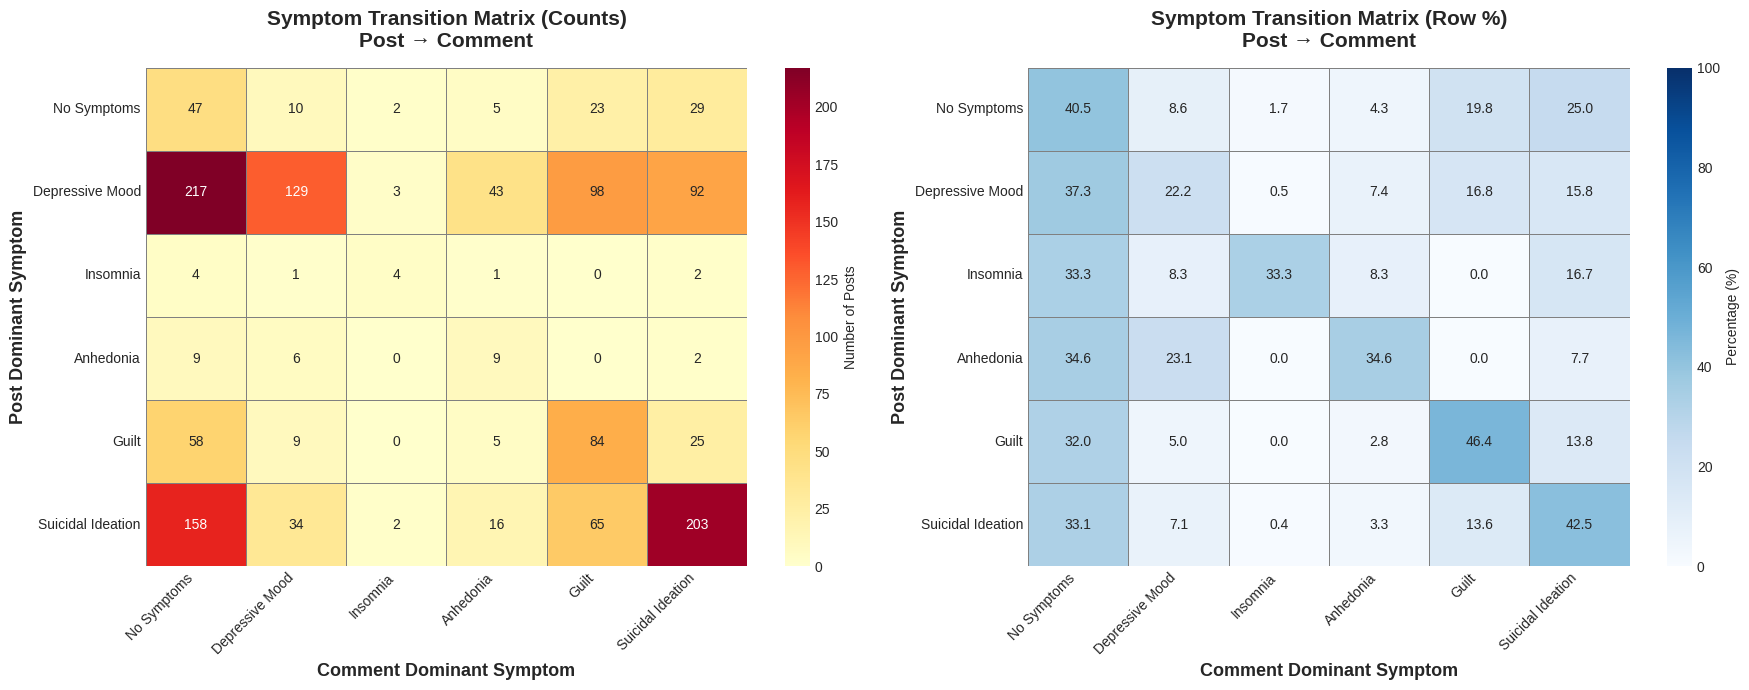


📊 Key Transition Insights:
  • Depressive Mood: 22.2% remain same symptom (129/582)
  • Insomnia: 33.3% remain same symptom (4/12)
  • Anhedonia: 34.6% remain same symptom (9/26)
  • Guilt: 46.4% remain same symptom (84/181)
  • Suicidal Ideation: 42.5% remain same symptom (203/478)

ANALYSIS 7: TRAJECTORY BY INITIAL SEVERITY

Trajectory by Initial Severity (Counts):
trajectory        Deteriorating  Improving  Stable
initial_severity                                  
0 symptoms                  106          0      10
1 symptom                     0         61    1201
2 symptoms                    0         17       0

Trajectory by Initial Severity (Percentages):
trajectory        Deteriorating  Improving  Stable
initial_severity                                  
0 symptoms                 91.4        0.0     8.6
1 symptom                   0.0        4.8    95.2
2 symptoms                  0.0      100.0     0.0

Average Symptom Change by Initial Severity:
                      mean 

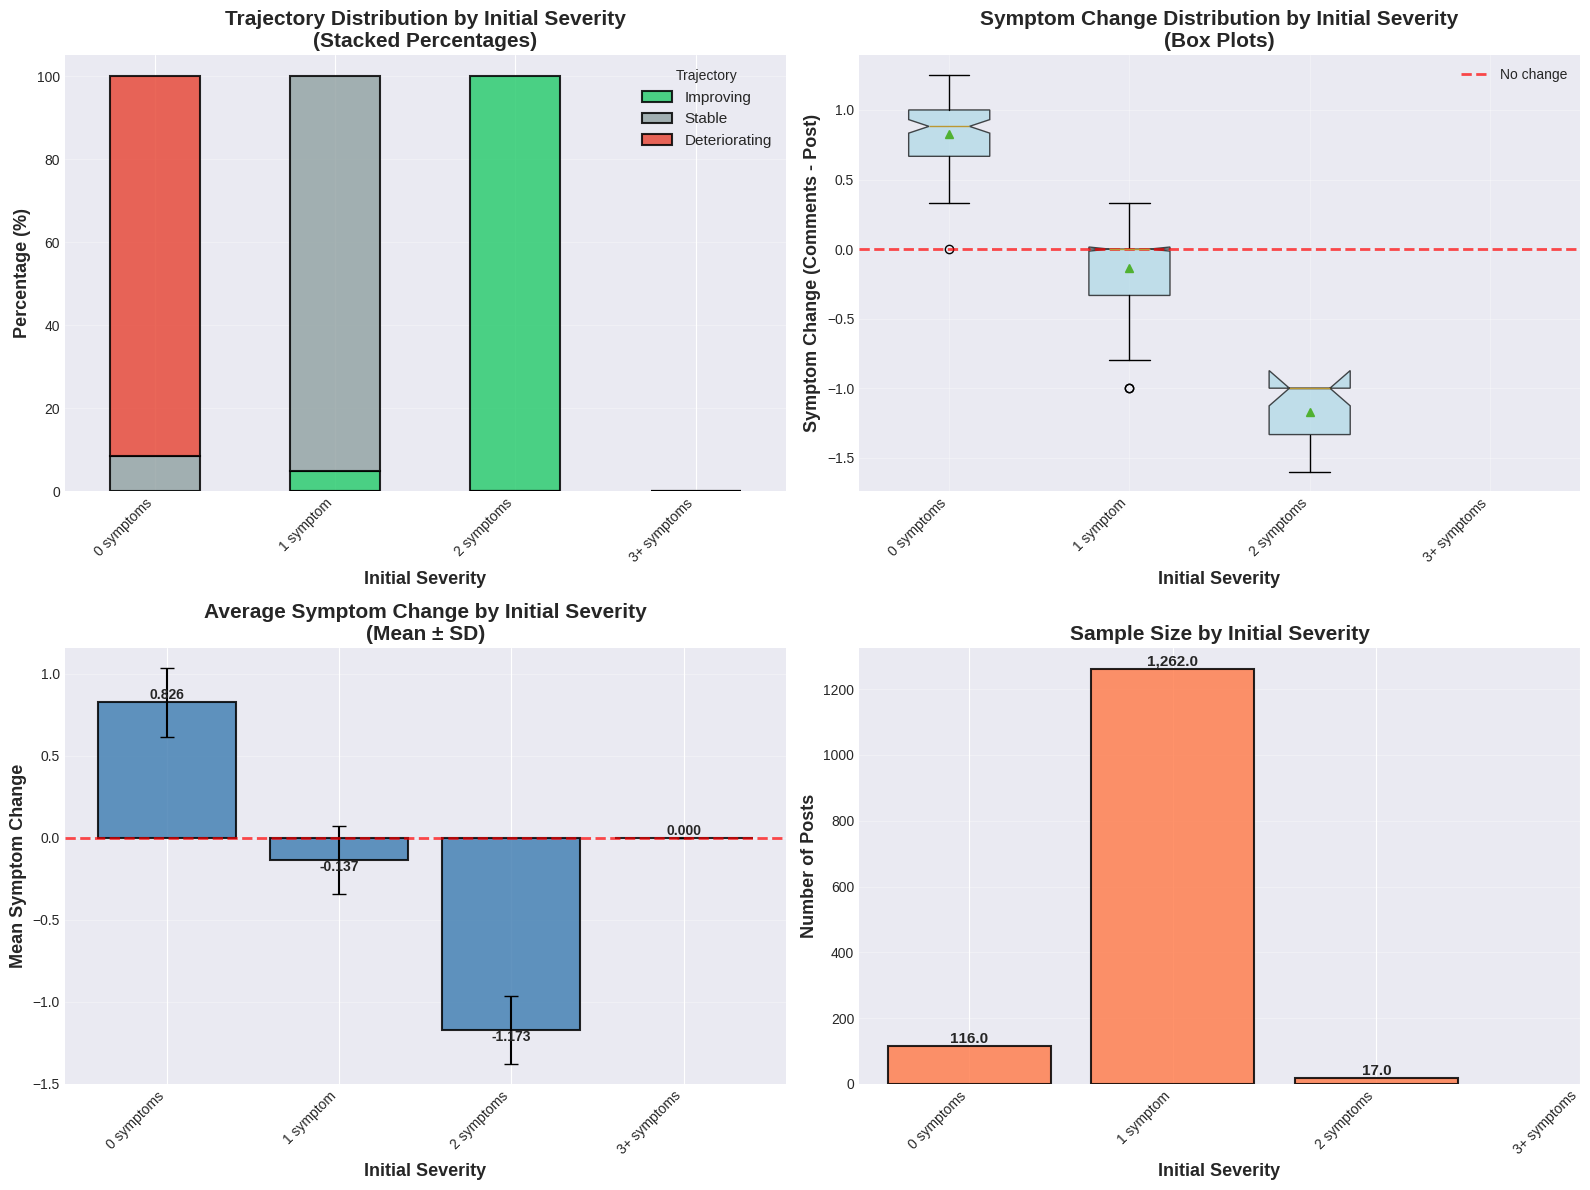


📊 Statistical Test:
  Chi-square test (severity vs trajectory): χ²=1554.114, p=0.0000
  ✓ Statistically significant association (p < 0.05)

ANALYSIS 8: STATISTICAL SIGNIFICANCE TESTS

1. McNemar's Test (Symptom Presence: Post vs Comments)
   Tests if symptom prevalence changes significantly
----------------------------------------------------------------------

Depressive Mood:
  Resolved (post→comment): 453
  Emerged (post→comment): 62
  McNemar statistic: 295.340
  P-value: 0.0000 ✓ Significant

Insomnia:
  Resolved (post→comment): 8
  Emerged (post→comment): 8
  McNemar statistic: 0.062
  P-value: 0.8026 ✗ Not significant

Anhedonia:
  Resolved (post→comment): 16
  Emerged (post→comment): 74
  McNemar statistic: 36.100
  P-value: 0.0000 ✓ Significant

Guilt:
  Resolved (post→comment): 98
  Emerged (post→comment): 193
  McNemar statistic: 30.364
  P-value: 0.0000 ✓ Significant

Suicidal Ideation:
  Resolved (post→comment): 271
  Emerged (post→comment): 158
  McNemar statistic: 29.24

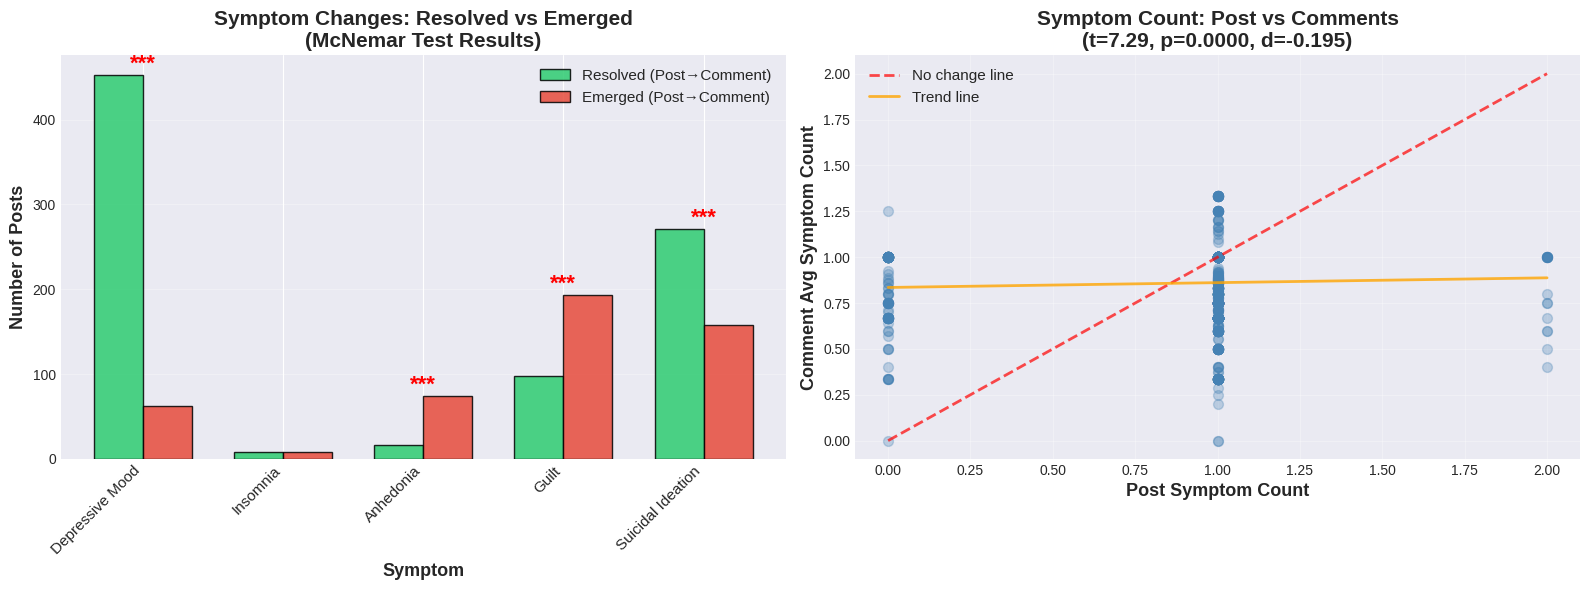


📊 COMPREHENSIVE SUMMARY OF STATISTICAL TESTS

1. Symptom-Specific Changes (McNemar's Test):
          Symptom  Resolved  Emerged  Statistic      P_value Significant
  Depressive Mood       453       62 295.339806 3.412690e-66           ✓
         Insomnia         8        8   0.062500 8.025873e-01           ✗
        Anhedonia        16       74  36.100000 1.874468e-09           ✓
            Guilt        98      193  30.364261 3.580648e-08           ✓
Suicidal Ideation       271      158  29.240093 6.394231e-08           ✓

   4/5 symptoms show statistically significant changes

2. Overall Symptom Count Change:
   Paired t-test: t=7.292, p=0.0000
   Wilcoxon test: W=81523.000, p=0.0000
   Effect size (Cohen's d): -0.195 (negligible)

3. Severity vs Trajectory Association:
   Chi-square test: χ²=1554.114, p=0.0000

✅ ALL ADDITIONAL ANALYSES COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import mcnemar
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# RELOAD DATA (from previous analysis)
# ============================================================

print("="*70)
print("ADDITIONAL TEMPORAL ANALYSES")
print("="*70)

posts_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_posts_with_OP_comments.csv')
comments_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_filtered_50words.csv')

# Filter posts with ≥3 comments
comments_per_post = comments_df.groupby('link_id').size().reset_index(name='comment_count')
posts_with_3plus = comments_per_post[comments_per_post['comment_count'] >= 3]['link_id']
posts_filtered = posts_df[posts_df['id'].isin(posts_with_3plus)].copy()
comments_filtered = comments_df[comments_df['link_id'].isin(posts_with_3plus)].copy()

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']
symptom_names = ['Depressive Mood', 'Insomnia', 'Anhedonia', 'Guilt', 'Suicidal Ideation']

posts_filtered['total_symptoms'] = posts_filtered[symptom_pred_cols].sum(axis=1)
comments_filtered['total_symptoms'] = comments_filtered[symptom_pred_cols].sum(axis=1)

print(f"\n✓ Posts analyzed: {len(posts_filtered):,}")
print(f"✓ Comments analyzed: {len(comments_filtered):,}")

# ============================================================
# ANALYSIS 6: SYMPTOM TRANSITION MATRIX
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 6: SYMPTOM TRANSITION MATRIX")
print("="*70)

# For each post, determine dominant symptom in post and in comments
def get_dominant_symptom(row, symptom_cols):
    """Get the symptom with highest probability, or 'None' if no symptoms"""
    symptoms = row[symptom_cols]
    if symptoms.sum() == 0:
        return 'No Symptoms'
    # Get index of max (first if tie)
    return symptom_names[symptoms.values.argmax()]

# Get dominant symptom in posts
posts_filtered['dominant_symptom'] = posts_filtered.apply(
    lambda row: get_dominant_symptom(row, symptom_pred_cols), axis=1
)

# For each post, get dominant symptom across its comments
post_comment_dominant = []

for post_id in posts_filtered['id']:
    post_comments = comments_filtered[comments_filtered['link_id'] == post_id]

    if len(post_comments) == 0:
        comment_dominant = 'No Symptoms'
    else:
        # Average symptom presence across comments
        avg_symptoms = post_comments[symptom_pred_cols].mean()

        if avg_symptoms.sum() == 0 or avg_symptoms.max() < 0.5:
            comment_dominant = 'No Symptoms'
        else:
            comment_dominant = symptom_names[avg_symptoms.values.argmax()]

    post_comment_dominant.append({
        'post_id': post_id,
        'comment_dominant': comment_dominant
    })

comment_dominant_df = pd.DataFrame(post_comment_dominant)

# Merge
transition_df = posts_filtered[['id', 'dominant_symptom']].merge(
    comment_dominant_df,
    left_on='id',
    right_on='post_id',
    how='inner'
)

# Create transition matrix
all_categories = ['No Symptoms'] + symptom_names
transition_matrix = pd.DataFrame(0, index=all_categories, columns=all_categories)

for _, row in transition_df.iterrows():
    from_symptom = row['dominant_symptom']
    to_symptom = row['comment_dominant']
    transition_matrix.loc[from_symptom, to_symptom] += 1

# Calculate percentages (row-wise)
transition_matrix_pct = transition_matrix.div(transition_matrix.sum(axis=1), axis=0) * 100

print("\nTransition Matrix (Counts):")
print(transition_matrix.to_string())

print("\nTransition Matrix (Row Percentages - Post → Comment):")
print(transition_matrix_pct.round(1).to_string())

# Visualization 1: Heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Counts heatmap
sns.heatmap(transition_matrix, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label': 'Number of Posts'}, ax=axes[0],
            linewidths=0.5, linecolor='gray')
axes[0].set_xlabel('Comment Dominant Symptom', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Post Dominant Symptom', fontsize=13, fontweight='bold')
axes[0].set_title('Symptom Transition Matrix (Counts)\nPost → Comment',
                  fontsize=15, fontweight='bold', pad=15)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Percentage heatmap
sns.heatmap(transition_matrix_pct, annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': 'Percentage (%)'}, ax=axes[1],
            linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
axes[1].set_xlabel('Comment Dominant Symptom', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Post Dominant Symptom', fontsize=13, fontweight='bold')
axes[1].set_title('Symptom Transition Matrix (Row %)\nPost → Comment',
                  fontsize=15, fontweight='bold', pad=15)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Key insights
print("\n📊 Key Transition Insights:")
for symptom in symptom_names:
    if symptom in transition_matrix.index and transition_matrix.loc[symptom].sum() > 0:
        same = transition_matrix.loc[symptom, symptom]
        total = transition_matrix.loc[symptom].sum()
        same_pct = (same / total) * 100
        print(f"  • {symptom}: {same_pct:.1f}% remain same symptom ({same}/{total})")

# ============================================================
# ANALYSIS 7: TRAJECTORY BY INITIAL SEVERITY
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 7: TRAJECTORY BY INITIAL SEVERITY")
print("="*70)

# Calculate average symptom count per post's comments
comment_symptom_avg = comments_filtered.groupby('link_id')['total_symptoms'].mean().reset_index()
comment_symptom_avg.columns = ['post_id', 'avg_comment_symptoms']

severity_df = posts_filtered[['id', 'total_symptoms']].merge(
    comment_symptom_avg,
    left_on='id',
    right_on='post_id',
    how='inner'
)

severity_df['symptom_change'] = severity_df['avg_comment_symptoms'] - severity_df['total_symptoms']

# Classify by initial severity
def severity_category(count):
    if count == 0:
        return '0 symptoms'
    elif count == 1:
        return '1 symptom'
    elif count == 2:
        return '2 symptoms'
    else:
        return '3+ symptoms'

severity_df['initial_severity'] = severity_df['total_symptoms'].apply(severity_category)

# Classify trajectory
def classify_trajectory(change):
    if change < -0.5:
        return 'Improving'
    elif change > 0.5:
        return 'Deteriorating'
    else:
        return 'Stable'

severity_df['trajectory'] = severity_df['symptom_change'].apply(classify_trajectory)

# Analyze by severity
severity_analysis = severity_df.groupby(['initial_severity', 'trajectory']).size().unstack(fill_value=0)
severity_analysis_pct = severity_analysis.div(severity_analysis.sum(axis=1), axis=0) * 100

print("\nTrajectory by Initial Severity (Counts):")
print(severity_analysis.to_string())

print("\nTrajectory by Initial Severity (Percentages):")
print(severity_analysis_pct.round(1).to_string())

# Average change by severity
avg_change_by_severity = severity_df.groupby('initial_severity')['symptom_change'].agg(['mean', 'std', 'count'])
print("\nAverage Symptom Change by Initial Severity:")
print(avg_change_by_severity.to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Stacked bar chart (percentages)
severity_order = ['0 symptoms', '1 symptom', '2 symptoms', '3+ symptoms']
severity_analysis_pct_ordered = severity_analysis_pct.reindex(severity_order)

severity_analysis_pct_ordered[['Improving', 'Stable', 'Deteriorating']].plot(
    kind='bar', stacked=True, ax=axes[0, 0],
    color=['#2ecc71', '#95a5a6', '#e74c3c'],
    edgecolor='black', linewidth=1.5, alpha=0.85
)
axes[0, 0].set_xlabel('Initial Severity', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Trajectory Distribution by Initial Severity\n(Stacked Percentages)',
                     fontsize=15, fontweight='bold')
axes[0, 0].legend(title='Trajectory', fontsize=11)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Box plot of symptom change by severity
severity_df['initial_severity_cat'] = pd.Categorical(
    severity_df['initial_severity'],
    categories=severity_order,
    ordered=True
)
severity_df_sorted = severity_df.sort_values('initial_severity_cat')

bp = axes[0, 1].boxplot(
    [severity_df_sorted[severity_df_sorted['initial_severity'] == cat]['symptom_change'].values
     for cat in severity_order],
    labels=severity_order,
    patch_artist=True,
    notch=True,
    showmeans=True
)

for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='No change')
axes[0, 1].set_xlabel('Initial Severity', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Symptom Change (Comments - Post)', fontsize=13, fontweight='bold')
axes[0, 1].set_title('Symptom Change Distribution by Initial Severity\n(Box Plots)',
                     fontsize=15, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticklabels(severity_order, rotation=45, ha='right')

# 3. Mean change by severity
x = range(len(severity_order))
means = [avg_change_by_severity.loc[cat, 'mean'] if cat in avg_change_by_severity.index else 0
         for cat in severity_order]
stds = [avg_change_by_severity.loc[cat, 'std'] if cat in avg_change_by_severity.index else 0
        for cat in severity_order]

bars = axes[1, 0].bar(x, means, yerr=stds, capsize=5,
                      color='steelblue', edgecolor='black', alpha=0.85, linewidth=1.5)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 0].set_xlabel('Initial Severity', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Mean Symptom Change', fontsize=13, fontweight='bold')
axes[1, 0].set_title('Average Symptom Change by Initial Severity\n(Mean ± SD)',
                     fontsize=15, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(severity_order, rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, mean) in enumerate(zip(bars, means)):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., mean,
                    f'{mean:.3f}',
                    ha='center', va='bottom' if mean >= 0 else 'top',
                    fontsize=10, fontweight='bold')

# 4. Sample sizes
sample_sizes = severity_df.groupby('initial_severity').size().reindex(severity_order)
bars = axes[1, 1].bar(x, sample_sizes.values,
                      color='coral', edgecolor='black', alpha=0.85, linewidth=1.5)
axes[1, 1].set_xlabel('Initial Severity', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Number of Posts', fontsize=13, fontweight='bold')
axes[1, 1].set_title('Sample Size by Initial Severity', fontsize=15, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(severity_order, rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

# Add counts
for bar, count in zip(bars, sample_sizes.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., count,
                    f'{count:,}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical test: Does initial severity predict trajectory?
print("\n📊 Statistical Test:")
chi2, p_value, dof, expected = chi2_contingency(severity_analysis)
print(f"  Chi-square test (severity vs trajectory): χ²={chi2:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print(f"  ✓ Statistically significant association (p < 0.05)")
else:
    print(f"  ✗ No significant association (p ≥ 0.05)")

# ============================================================
# ANALYSIS 8: STATISTICAL SIGNIFICANCE TESTS
# ============================================================

print("\n" + "="*70)
print("ANALYSIS 8: STATISTICAL SIGNIFICANCE TESTS")
print("="*70)

# Test 1: McNemar's test for each symptom (paired binary test)
print("\n1. McNemar's Test (Symptom Presence: Post vs Comments)")
print("   Tests if symptom prevalence changes significantly")
print("-" * 70)

mcnemar_results = []

for i, symptom in enumerate(symptom_names):
    symptom_col = symptom_pred_cols[i]

    # For each post, determine if symptom in post and in majority of comments
    symptom_comparison = []

    for post_id in posts_filtered['id']:
        post_row = posts_filtered[posts_filtered['id'] == post_id]
        post_has = post_row[symptom_col].values[0]

        post_comments = comments_filtered[comments_filtered['link_id'] == post_id]
        if len(post_comments) > 0:
            comment_has = 1 if post_comments[symptom_col].mean() >= 0.5 else 0
        else:
            comment_has = 0

        symptom_comparison.append({
            'post_has': post_has,
            'comment_has': comment_has
        })

    comparison_df = pd.DataFrame(symptom_comparison)

    # Create contingency table
    # Format: [[both_no, post_yes_comment_no],
    #          [post_no_comment_yes, both_yes]]
    both_no = ((comparison_df['post_has'] == 0) & (comparison_df['comment_has'] == 0)).sum()
    post_yes_comment_no = ((comparison_df['post_has'] == 1) & (comparison_df['comment_has'] == 0)).sum()
    post_no_comment_yes = ((comparison_df['post_has'] == 0) & (comparison_df['comment_has'] == 1)).sum()
    both_yes = ((comparison_df['post_has'] == 1) & (comparison_df['comment_has'] == 1)).sum()

    table = [[both_no, post_yes_comment_no],
             [post_no_comment_yes, both_yes]]

    # Run McNemar's test (only if discordant pairs exist)
    if post_yes_comment_no + post_no_comment_yes > 0:
        result = mcnemar(table, exact=False, correction=True)
        mcnemar_results.append({
            'Symptom': symptom,
            'Resolved': post_yes_comment_no,
            'Emerged': post_no_comment_yes,
            'Statistic': result.statistic,
            'P_value': result.pvalue,
            'Significant': '✓' if result.pvalue < 0.05 else '✗'
        })

        print(f"\n{symptom}:")
        print(f"  Resolved (post→comment): {post_yes_comment_no}")
        print(f"  Emerged (post→comment): {post_no_comment_yes}")
        print(f"  McNemar statistic: {result.statistic:.3f}")
        print(f"  P-value: {result.pvalue:.4f} {'✓ Significant' if result.pvalue < 0.05 else '✗ Not significant'}")
    else:
        print(f"\n{symptom}: Insufficient discordant pairs for McNemar's test")

mcnemar_df = pd.DataFrame(mcnemar_results)

# Test 2: Overall symptom count change (paired t-test)
print("\n" + "-" * 70)
print("2. Paired t-test (Overall Symptom Count Change)")
print("-" * 70)

post_counts = severity_df['total_symptoms'].values
comment_counts = severity_df['avg_comment_symptoms'].values

t_stat, p_value_ttest = stats.ttest_rel(post_counts, comment_counts)
mean_diff = np.mean(comment_counts - post_counts)
effect_size = mean_diff / np.std(comment_counts - post_counts)  # Cohen's d

print(f"  Mean post symptom count: {np.mean(post_counts):.3f}")
print(f"  Mean comment symptom count: {np.mean(comment_counts):.3f}")
print(f"  Mean difference: {mean_diff:.3f}")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  P-value: {p_value_ttest:.4f} {'✓ Significant' if p_value_ttest < 0.05 else '✗ Not significant'}")
print(f"  Cohen's d (effect size): {effect_size:.3f}")

# Effect size interpretation
if abs(effect_size) < 0.2:
    effect_interpretation = "negligible"
elif abs(effect_size) < 0.5:
    effect_interpretation = "small"
elif abs(effect_size) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"  Effect size interpretation: {effect_interpretation}")

# Test 3: Wilcoxon signed-rank test (non-parametric alternative)
print("\n" + "-" * 70)
print("3. Wilcoxon Signed-Rank Test (Non-parametric)")
print("-" * 70)

wilcoxon_stat, p_value_wilcoxon = stats.wilcoxon(post_counts, comment_counts)
print(f"  Wilcoxon statistic: {wilcoxon_stat:.3f}")
print(f"  P-value: {p_value_wilcoxon:.4f} {'✓ Significant' if p_value_wilcoxon < 0.05 else '✗ Not significant'}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# McNemar results
if len(mcnemar_df) > 0:
    x = np.arange(len(mcnemar_df))
    width = 0.35

    bars1 = axes[0].bar(x - width/2, mcnemar_df['Resolved'], width,
                        label='Resolved (Post→Comment)', color='#2ecc71',
                        edgecolor='black', alpha=0.85)
    bars2 = axes[0].bar(x + width/2, mcnemar_df['Emerged'], width,
                        label='Emerged (Post→Comment)', color='#e74c3c',
                        edgecolor='black', alpha=0.85)

    axes[0].set_xlabel('Symptom', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Number of Posts', fontsize=13, fontweight='bold')
    axes[0].set_title('Symptom Changes: Resolved vs Emerged\n(McNemar Test Results)',
                      fontsize=15, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(mcnemar_df['Symptom'], rotation=45, ha='right', fontsize=11)
    axes[0].legend(fontsize=11)
    axes[0].grid(axis='y', alpha=0.3)

    # Add significance markers
    for i, (idx, row) in enumerate(mcnemar_df.iterrows()):
        if row['Significant'] == '✓':
            max_height = max(row['Resolved'], row['Emerged'])
            axes[0].text(i, max_height, '***' if row['P_value'] < 0.001 else '**' if row['P_value'] < 0.01 else '*',
                        ha='center', va='bottom', fontsize=16, fontweight='bold', color='red')

# Paired comparison visualization
axes[1].scatter(post_counts, comment_counts, alpha=0.3, s=50, color='steelblue')
axes[1].plot([0, max(post_counts.max(), comment_counts.max())],
             [0, max(post_counts.max(), comment_counts.max())],
             'r--', linewidth=2, label='No change line', alpha=0.7)

# Add regression line
z = np.polyfit(post_counts, comment_counts, 1)
p = np.poly1d(z)
x_line = np.linspace(0, post_counts.max(), 100)
axes[1].plot(x_line, p(x_line), "orange", linewidth=2, alpha=0.8, label='Trend line')

axes[1].set_xlabel('Post Symptom Count', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Comment Avg Symptom Count', fontsize=13, fontweight='bold')
axes[1].set_title(f'Symptom Count: Post vs Comments\n(t={t_stat:.2f}, p={p_value_ttest:.4f}, d={effect_size:.3f})',
                  fontsize=15, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*70)
print("📊 COMPREHENSIVE SUMMARY OF STATISTICAL TESTS")
print("="*70)

print("\n1. Symptom-Specific Changes (McNemar's Test):")
if len(mcnemar_df) > 0:
    print(mcnemar_df.to_string(index=False))
    sig_count = (mcnemar_df['P_value'] < 0.05).sum()
    print(f"\n   {sig_count}/{len(mcnemar_df)} symptoms show statistically significant changes")
else:
    print("   No valid McNemar tests performed")

print(f"\n2. Overall Symptom Count Change:")
print(f"   Paired t-test: t={t_stat:.3f}, p={p_value_ttest:.4f}")
print(f"   Wilcoxon test: W={wilcoxon_stat:.3f}, p={p_value_wilcoxon:.4f}")
print(f"   Effect size (Cohen's d): {effect_size:.3f} ({effect_interpretation})")

print(f"\n3. Severity vs Trajectory Association:")
print(f"   Chi-square test: χ²={chi2:.3f}, p={p_value:.4f}")

print("\n" + "="*70)
print("✅ ALL ADDITIONAL ANALYSES COMPLETE!")
print("="*70)

INVESTIGATING 0-SYMPTOM POSTS

✓ Total 0-symptom posts: 116
✓ Percentage of dataset: 8.3%

EXAMPLE 0-SYMPTOM POSTS (5 Random Samples)

EXAMPLE 1
Post ID: 1cnbsh1
Title: Idk anymore at this point it’s just coping 😂

Post Text (first 500 chars):
Idk anymore at this point it’s just coping 😂 1:12 PM MAY 8 2024. If there ever comes a point in time that I do end up committing suicide,I deserve it. If there ever comes a time that I die or get killed,I probably deserved it. When I look back on my thoughts,I find them to be funny or just cringe and unserious.  I have a immense hatred towards myself and the world as a whole,I’ve never wanted to fit in as a kid or an adult,I’ve never cared for attention as a kid and going into my adulthood and f...

📊 Symptom Probabilities (all below 0.5 threshold):
  Depressive Mood     : 0.390 ✗ ███████
  Insomnia            : 0.000 ✗ 
  Anhedonia           : 0.001 ✗ 
  Guilt               : 0.114 ✗ ██
  Suicidal Ideation   : 0.438 ✗ ████████

💬 Number of OP co

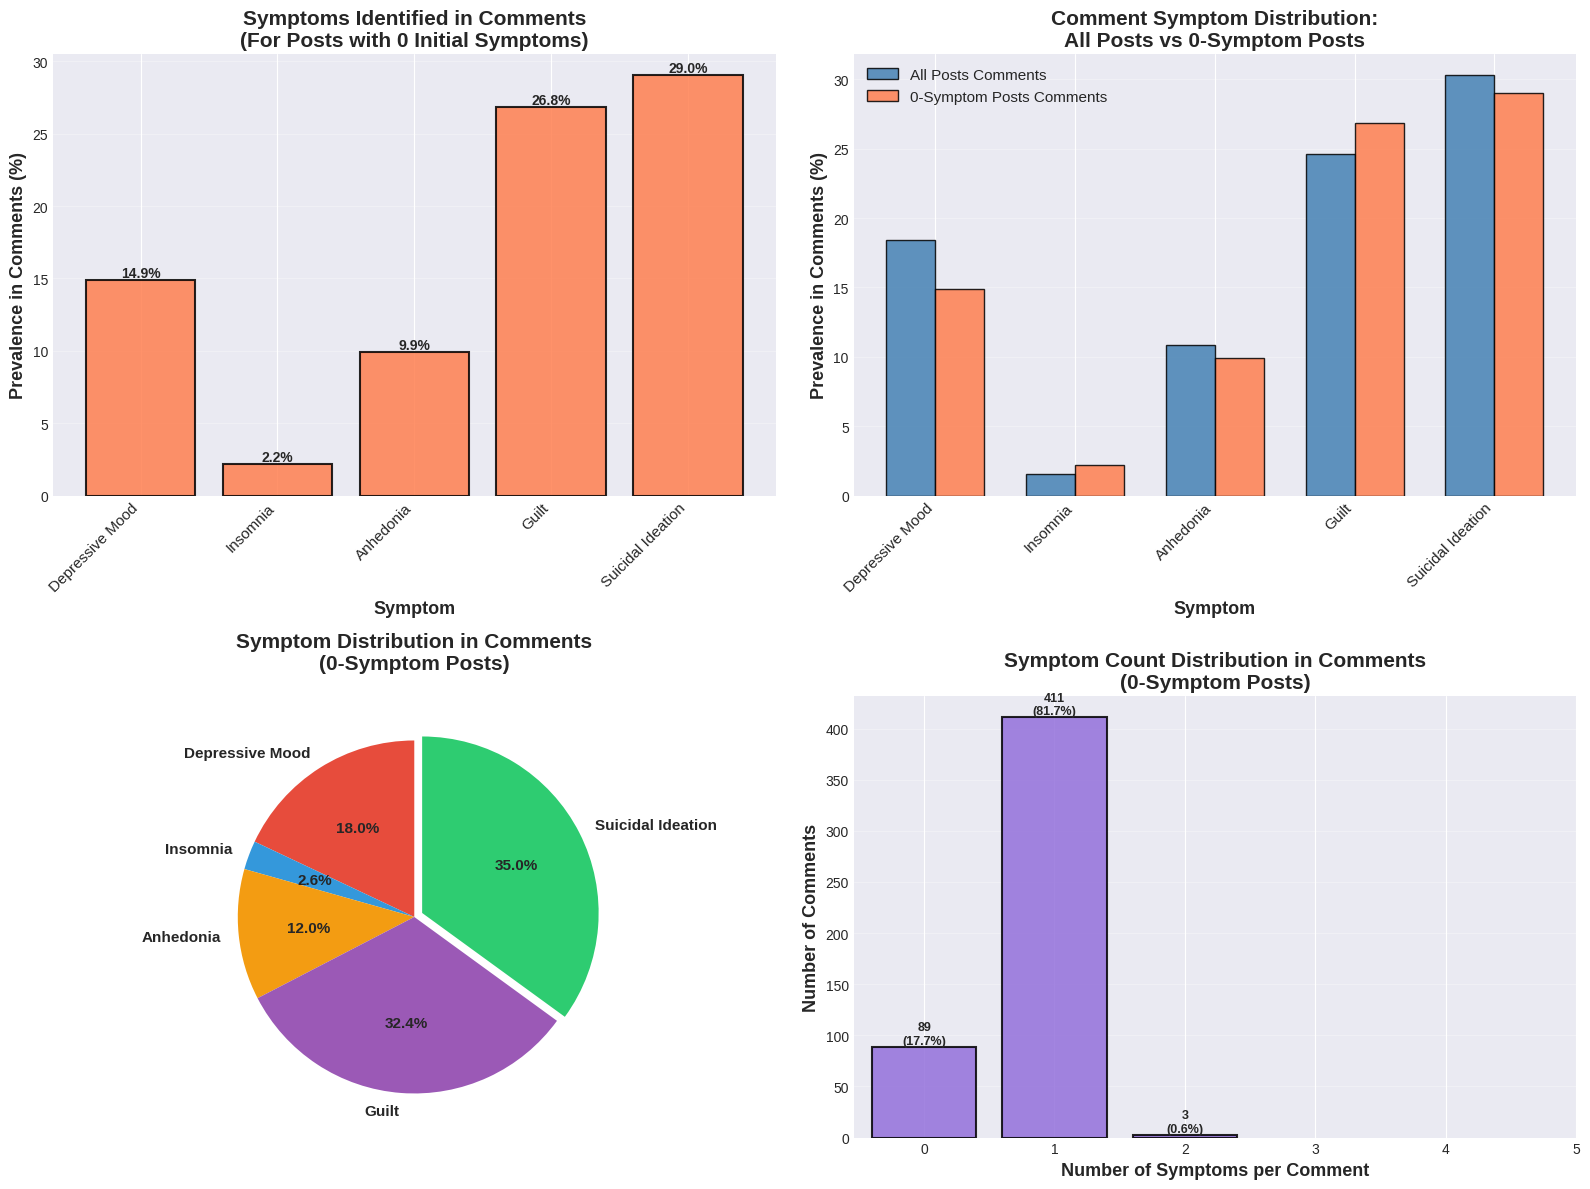


POST PROBABILITY DISTRIBUTION (0-Symptom Posts)

Probability Statistics (all symptoms across all 0-symptom posts):
  Mean: 0.180
  Median: 0.127
  Max: 0.499
  Min: 0.000
  Std: 0.181

  Probabilities between 0.4-0.5 (close to threshold): 108 (18.6%)


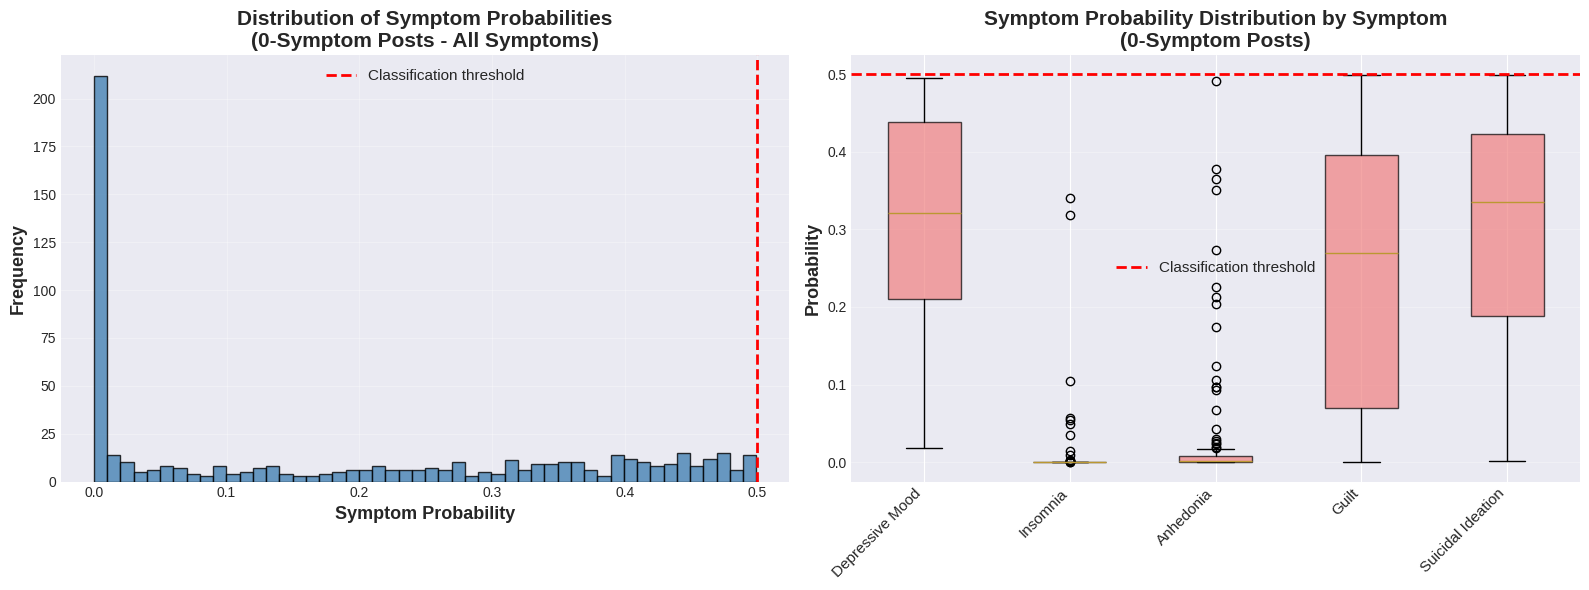


TESTING YOUR HYPOTHESIS: Insomnia Bias in 0-Symptom Posts?

✓ Most common symptom in 0-symptom post comments: Suicidal Ideation (29.0%)

📊 Insomnia Analysis:
  Insomnia in ALL comments: 1.6%
  Insomnia in 0-symptom post comments: 2.2%
  Difference: +0.6%
  ✓ Your hypothesis confirmed: Insomnia is HIGHER in 0-symptom post comments

📊 Symptoms Ranked by Emergence in 0-Symptom Post Comments:
Rank   Symptom              Prevalence   vs All Posts   
------------------------------------------------------------
1      Guilt                      26.8%          +2.2%
2      Insomnia                    2.2%          +0.6%
3      Anhedonia                   9.9%          -0.9%
4      Suicidal Ideation          29.0%          -1.3%
5      Depressive Mood            14.9%          -3.5%

✅ 0-SYMPTOM POST INVESTIGATION COMPLETE!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# LOAD DATA
# ============================================================

print("="*70)
print("INVESTIGATING 0-SYMPTOM POSTS")
print("="*70)

posts_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_posts_with_OP_comments.csv')
comments_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_filtered_50words.csv')

# Filter posts with ≥3 comments
comments_per_post = comments_df.groupby('link_id').size().reset_index(name='comment_count')
posts_with_3plus = comments_per_post[comments_per_post['comment_count'] >= 3]['link_id']
posts_filtered = posts_df[posts_df['id'].isin(posts_with_3plus)].copy()
comments_filtered = comments_df[comments_df['link_id'].isin(posts_with_3plus)].copy()

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']
symptom_prob_cols = ['Depressive_Mood_Prob', 'Insomnia_Prob', 'Anhedonia_Prob',
                     'Guilt_Prob', 'Suicidal_Ideation_Prob']
symptom_names = ['Depressive Mood', 'Insomnia', 'Anhedonia', 'Guilt', 'Suicidal Ideation']

posts_filtered['total_symptoms'] = posts_filtered[symptom_pred_cols].sum(axis=1)

# ============================================================
# GET 0-SYMPTOM POSTS
# ============================================================

zero_symptom_posts = posts_filtered[posts_filtered['total_symptoms'] == 0].copy()

print(f"\n✓ Total 0-symptom posts: {len(zero_symptom_posts):,}")
print(f"✓ Percentage of dataset: {len(zero_symptom_posts)/len(posts_filtered)*100:.1f}%")

# ============================================================
# SHOW 5 EXAMPLE POSTS WITH PROBABILITIES
# ============================================================

print("\n" + "="*70)
print("EXAMPLE 0-SYMPTOM POSTS (5 Random Samples)")
print("="*70)

# Get random sample
sample_posts = zero_symptom_posts.sample(min(5, len(zero_symptom_posts)), random_state=42)

for idx, (i, row) in enumerate(sample_posts.iterrows(), 1):
    print(f"\n{'='*70}")
    print(f"EXAMPLE {idx}")
    print(f"{'='*70}")
    print(f"Post ID: {row['id']}")
    print(f"Title: {row['title'][:100]}..." if len(str(row['title'])) > 100 else f"Title: {row['title']}")
    print(f"\nPost Text (first 500 chars):")
    print(f"{str(row['text'])[:500]}...")

    print(f"\n📊 Symptom Probabilities (all below 0.5 threshold):")
    for j, sym in enumerate(symptom_names):
        prob = row[symptom_prob_cols[j]]
        pred = row[symptom_pred_cols[j]]
        bar = '█' * int(prob * 20)
        print(f"  {sym:20s}: {prob:.3f} {'✗' if pred == 0 else '✓'} {bar}")

    print(f"\n💬 Number of OP comments for this post: {comments_per_post[comments_per_post['link_id'] == row['id']]['comment_count'].values[0]}")

# ============================================================
# ANALYZE SYMPTOMS IN COMMENTS FOR 0-SYMPTOM POSTS
# ============================================================

print("\n" + "="*70)
print("SYMPTOMS IDENTIFIED IN COMMENTS (0-Symptom Posts)")
print("="*70)

# Get all comments for 0-symptom posts
zero_symptom_post_ids = zero_symptom_posts['id'].values
comments_for_zero = comments_filtered[comments_filtered['link_id'].isin(zero_symptom_post_ids)]

print(f"\n✓ 0-symptom posts: {len(zero_symptom_posts):,}")
print(f"✓ Total comments for these posts: {len(comments_for_zero):,}")
print(f"✓ Average comments per 0-symptom post: {len(comments_for_zero)/len(zero_symptom_posts):.2f}")

# Symptom prevalence in these comments
comment_symptom_counts = comments_for_zero[symptom_pred_cols].sum()
comment_symptom_pcts = (comment_symptom_counts / len(comments_for_zero)) * 100

print(f"\n📊 Symptom Distribution in Comments:")
for i, sym in enumerate(symptom_names):
    count = comment_symptom_counts[i]
    pct = comment_symptom_pcts[i]
    print(f"  {sym:20s}: {count:4.0f} comments ({pct:5.1f}%)")

# Compare to overall comment symptom distribution
all_comment_symptom_counts = comments_filtered[symptom_pred_cols].sum()
all_comment_symptom_pcts = (all_comment_symptom_counts / len(comments_filtered)) * 100

print(f"\n📊 Comparison: All Comments vs 0-Symptom Post Comments")
print(f"{'Symptom':20s} | {'All Posts':>12s} | {'0-Sym Posts':>12s} | {'Difference':>12s}")
print("-" * 70)
for i, sym in enumerate(symptom_names):
    all_pct = all_comment_symptom_pcts[i]
    zero_pct = comment_symptom_pcts[i]
    diff = zero_pct - all_pct
    print(f"{sym:20s} | {all_pct:11.1f}% | {zero_pct:11.1f}% | {diff:+11.1f}%")

# ============================================================
# VISUALIZATION 1: SYMPTOM DISTRIBUTION IN COMMENTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart: Symptoms in comments (0-symptom posts)
x = np.arange(len(symptom_names))
bars = axes[0, 0].bar(x, comment_symptom_pcts,
                       color='coral', edgecolor='black', alpha=0.85, linewidth=1.5)
axes[0, 0].set_xlabel('Symptom', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Prevalence in Comments (%)', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Symptoms Identified in Comments\n(For Posts with 0 Initial Symptoms)',
                     fontsize=15, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

# Add value labels
for bar, pct in zip(bars, comment_symptom_pcts):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{pct:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Comparison: All posts vs 0-symptom posts
width = 0.35
bars1 = axes[0, 1].bar(x - width/2, all_comment_symptom_pcts, width,
                        label='All Posts Comments', color='steelblue',
                        edgecolor='black', alpha=0.85)
bars2 = axes[0, 1].bar(x + width/2, comment_symptom_pcts, width,
                        label='0-Symptom Posts Comments', color='coral',
                        edgecolor='black', alpha=0.85)

axes[0, 1].set_xlabel('Symptom', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Prevalence in Comments (%)', fontsize=13, fontweight='bold')
axes[0, 1].set_title('Comment Symptom Distribution:\nAll Posts vs 0-Symptom Posts',
                     fontsize=15, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Pie chart: Most common symptom in 0-symptom post comments
symptom_counts_dict = dict(zip(symptom_names, comment_symptom_counts))
colors_pie = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#2ecc71']
explode = [0.05 if i == comment_symptom_counts.argmax() else 0 for i in range(len(symptom_names))]

wedges, texts, autotexts = axes[1, 0].pie(
    comment_symptom_counts,
    labels=symptom_names,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_pie,
    explode=explode,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1, 0].set_title('Symptom Distribution in Comments\n(0-Symptom Posts)',
                     fontsize=15, fontweight='bold', pad=20)

# 4. Distribution of total symptoms in comments (0-symptom posts)
comments_for_zero['total_symptoms'] = comments_for_zero[symptom_pred_cols].sum(axis=1)
symptom_count_dist = comments_for_zero['total_symptoms'].value_counts().sort_index()

bars = axes[1, 1].bar(symptom_count_dist.index, symptom_count_dist.values,
                       color='mediumpurple', edgecolor='black', alpha=0.85, linewidth=1.5)
axes[1, 1].set_xlabel('Number of Symptoms per Comment', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Number of Comments', fontsize=13, fontweight='bold')
axes[1, 1].set_title('Symptom Count Distribution in Comments\n(0-Symptom Posts)',
                     fontsize=15, fontweight='bold')
axes[1, 1].set_xticks(range(0, 6))
axes[1, 1].grid(axis='y', alpha=0.3)

# Add counts
for bar, count in zip(bars, symptom_count_dist.values):
    pct = (count / len(comments_for_zero)) * 100
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{count:,}\n({pct:.1f}%)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# ADDITIONAL ANALYSIS: POST PROBABILITIES DISTRIBUTION
# ============================================================

print("\n" + "="*70)
print("POST PROBABILITY DISTRIBUTION (0-Symptom Posts)")
print("="*70)

# Get all probabilities for 0-symptom posts
all_probs = zero_symptom_posts[symptom_prob_cols].values.flatten()

print(f"\nProbability Statistics (all symptoms across all 0-symptom posts):")
print(f"  Mean: {all_probs.mean():.3f}")
print(f"  Median: {np.median(all_probs):.3f}")
print(f"  Max: {all_probs.max():.3f}")
print(f"  Min: {all_probs.min():.3f}")
print(f"  Std: {all_probs.std():.3f}")

# How many were close to 0.5 threshold?
close_to_threshold = ((all_probs >= 0.4) & (all_probs < 0.5)).sum()
print(f"\n  Probabilities between 0.4-0.5 (close to threshold): {close_to_threshold} ({close_to_threshold/len(all_probs)*100:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of all probabilities
axes[0].hist(all_probs, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Classification threshold')
axes[0].set_xlabel('Symptom Probability', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=13, fontweight='bold')
axes[0].set_title('Distribution of Symptom Probabilities\n(0-Symptom Posts - All Symptoms)',
                  fontsize=15, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Box plot per symptom
zero_symptom_posts_probs = [zero_symptom_posts[col].values for col in symptom_prob_cols]
bp = axes[1].boxplot(zero_symptom_posts_probs, labels=symptom_names, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
    patch.set_alpha(0.7)

axes[1].axhline(0.5, color='red', linestyle='--', linewidth=2, label='Classification threshold')
axes[1].set_ylabel('Probability', fontsize=13, fontweight='bold')
axes[1].set_title('Symptom Probability Distribution by Symptom\n(0-Symptom Posts)',
                  fontsize=15, fontweight='bold')
axes[1].set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# HYPOTHESIS TEST: Is it really Insomnia bias?
# ============================================================

print("\n" + "="*70)
print("TESTING YOUR HYPOTHESIS: Insomnia Bias in 0-Symptom Posts?")
print("="*70)

# What's the most common symptom in comments for 0-symptom posts?
most_common = symptom_names[comment_symptom_counts.argmax()]
most_common_pct = comment_symptom_pcts.max()

print(f"\n✓ Most common symptom in 0-symptom post comments: {most_common} ({most_common_pct:.1f}%)")

# Insomnia specifically
insomnia_idx = symptom_names.index('Insomnia')
insomnia_pct_zero = comment_symptom_pcts[insomnia_idx]
insomnia_pct_all = all_comment_symptom_pcts[insomnia_idx]

print(f"\n📊 Insomnia Analysis:")
print(f"  Insomnia in ALL comments: {insomnia_pct_all:.1f}%")
print(f"  Insomnia in 0-symptom post comments: {insomnia_pct_zero:.1f}%")
print(f"  Difference: {insomnia_pct_zero - insomnia_pct_all:+.1f}%")

if insomnia_pct_zero > insomnia_pct_all:
    print(f"  ✓ Your hypothesis confirmed: Insomnia is HIGHER in 0-symptom post comments")
else:
    print(f"  ✗ Your hypothesis not confirmed: Insomnia is not elevated in 0-symptom post comments")

# Rank symptoms by emergence in 0-symptom posts
symptom_diff = comment_symptom_pcts.values - all_comment_symptom_pcts.values
symptom_ranking = sorted(zip(symptom_names, symptom_diff, comment_symptom_pcts.values),
                         key=lambda x: x[1], reverse=True)

print(f"\n📊 Symptoms Ranked by Emergence in 0-Symptom Post Comments:")
print(f"{'Rank':<6} {'Symptom':<20} {'Prevalence':<12} {'vs All Posts':<15}")
print("-" * 60)
for rank, (sym, diff, prev) in enumerate(symptom_ranking, 1):
    print(f"{rank:<6} {sym:<20} {prev:>10.1f}% {diff:>+13.1f}%")

print("\n" + "="*70)
print("✅ 0-SYMPTOM POST INVESTIGATION COMPLETE!")
print("="*70)

BORDERLINE SYMPTOM DETECTION: 0-Symptom Posts Analysis

✓ 0-symptom posts: 116

BORDERLINE DETECTION ANALYSIS

📊 Borderline Post Analysis:
  Total 0-symptom posts: 116
  Posts with prob increase: 74 (63.8%)
  Posts that crossed 0.5 threshold in comments: 56 (48.3%)
  Average post max prob: 0.428
  Average comment max prob: 0.512
  Average increase: 0.084

  Posts with borderline probs (0.3-0.5): 111 (95.7%)
    Of these, 53 crossed threshold (47.7%)


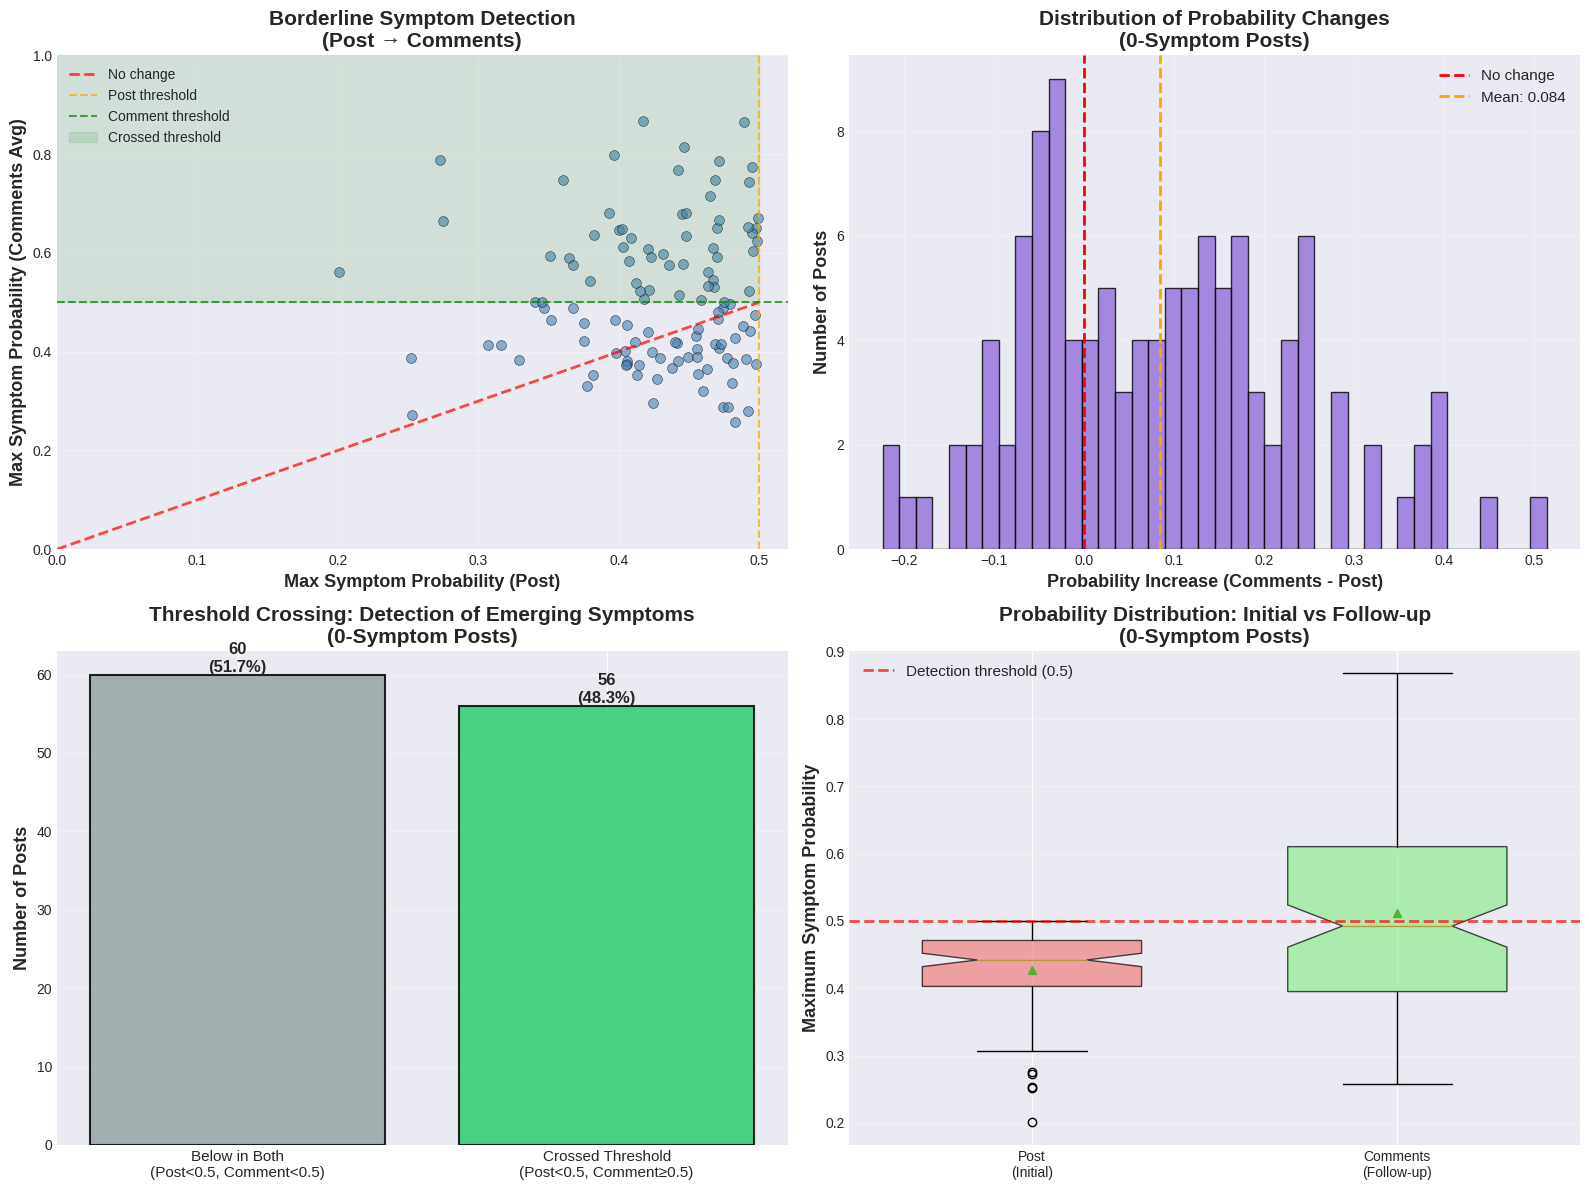


EXAMPLES: BORDERLINE → DETECTED (Top 5 Increases)

Example 1:
  Post max prob: 0.273 (Anhedonia) → Below threshold
  Comment avg prob: 0.787 (Suicidal Ideation) → Above threshold ✓
  Increase: +0.514
  Number of comments: 3

Example 2:
  Post max prob: 0.417 (Depressive Mood) → Below threshold
  Comment avg prob: 0.868 (Suicidal Ideation) → Above threshold ✓
  Increase: +0.450
  Number of comments: 4

Example 3:
  Post max prob: 0.397 (Suicidal Ideation) → Below threshold
  Comment avg prob: 0.799 (Guilt) → Above threshold ✓
  Increase: +0.402
  Number of comments: 3

Example 4:
  Post max prob: 0.275 (Depressive Mood) → Below threshold
  Comment avg prob: 0.665 (Depressive Mood) → Above threshold ✓
  Increase: +0.390
  Number of comments: 3

Example 5:
  Post max prob: 0.360 (Guilt) → Below threshold
  Comment avg prob: 0.748 (Suicidal Ideation) → Above threshold ✓
  Increase: +0.387
  Number of comments: 5


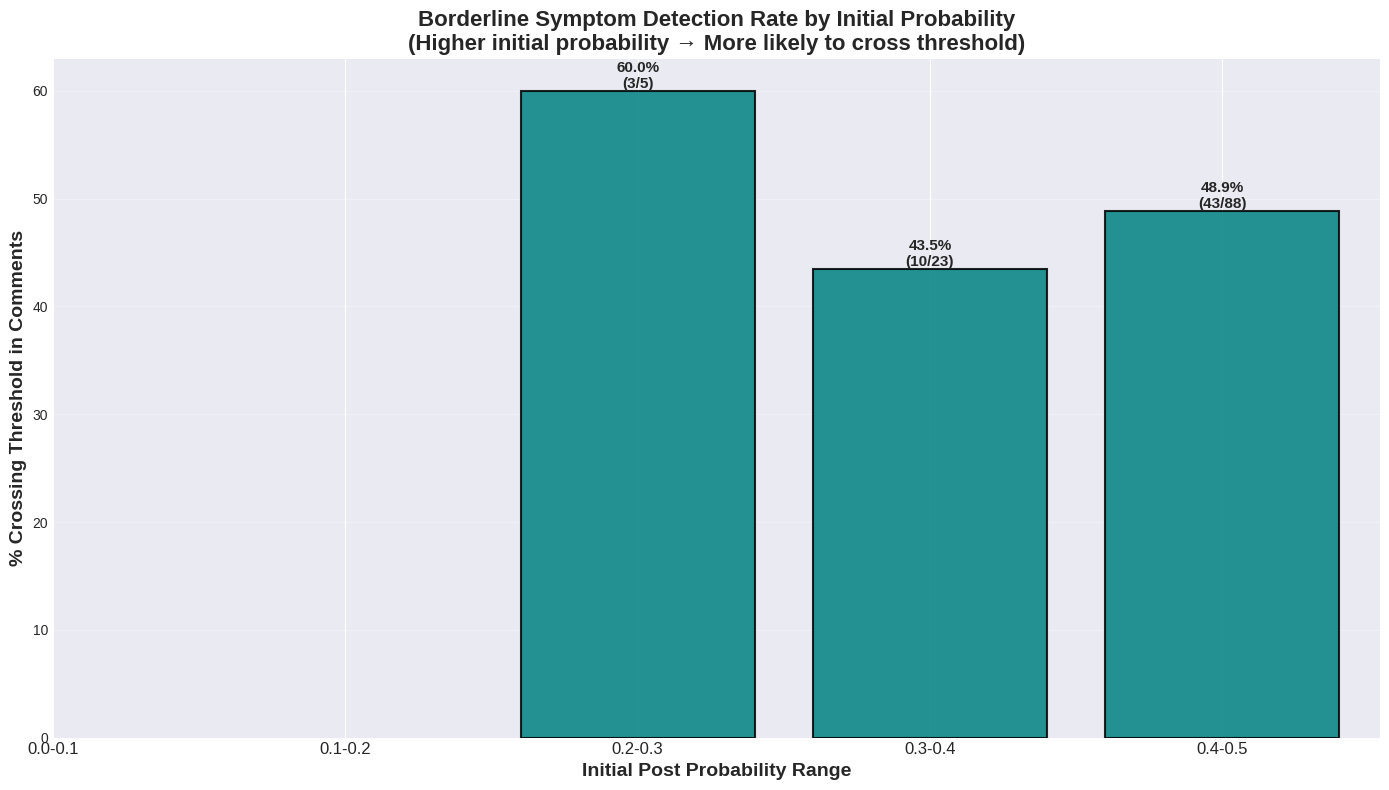


KEY INSIGHT TABLE: Detection Rate by Initial Probability
post_bin  crossed  total     rate  rate_pct
 0.0-0.1        0      0      NaN       NaN
 0.1-0.2        0      0      NaN       NaN
 0.2-0.3        3      5 0.600000 60.000000
 0.3-0.4       10     23 0.434783 43.478261
 0.4-0.5       43     88 0.488636 48.863636

STATISTICAL SIGNIFICANCE

Paired t-test (Post vs Comment max probabilities):
  t-statistic: -5.918
  p-value: 0.0000
  ✓ Statistically significant increase (p < 0.05)
  Cohen's d (effect size): 1.412

✅ BORDERLINE DETECTION ANALYSIS COMPLETE!

💡 KEY TAKEAWAY:
  • 116 posts initially below threshold (0-symptoms)
  • 56 (48.3%) crossed threshold in comments
  • Average probability increase: +0.084
  • This demonstrates early symptom detection through continued engagement


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# LOAD DATA
# ============================================================

print("="*70)
print("BORDERLINE SYMPTOM DETECTION: 0-Symptom Posts Analysis")
print("="*70)

posts_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_posts_with_OP_comments.csv')
comments_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_filtered_50words.csv')

# Filter posts with ≥3 comments
comments_per_post = comments_df.groupby('link_id').size().reset_index(name='comment_count')
posts_with_3plus = comments_per_post[comments_per_post['comment_count'] >= 3]['link_id']
posts_filtered = posts_df[posts_df['id'].isin(posts_with_3plus)].copy()
comments_filtered = comments_df[comments_df['link_id'].isin(posts_with_3plus)].copy()

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']
symptom_prob_cols = ['Depressive_Mood_Prob', 'Insomnia_Prob', 'Anhedonia_Prob',
                     'Guilt_Prob', 'Suicidal_Ideation_Prob']
symptom_names = ['Depressive Mood', 'Insomnia', 'Anhedonia', 'Guilt', 'Suicidal Ideation']

posts_filtered['total_symptoms'] = posts_filtered[symptom_pred_cols].sum(axis=1)

# Get 0-symptom posts
zero_symptom_posts = posts_filtered[posts_filtered['total_symptoms'] == 0].copy()

print(f"\n✓ 0-symptom posts: {len(zero_symptom_posts):,}")

# ============================================================
# ANALYSIS: BORDERLINE PROBABILITIES → DETECTION
# ============================================================

print("\n" + "="*70)
print("BORDERLINE DETECTION ANALYSIS")
print("="*70)

# For each 0-symptom post, get max probability in post
zero_symptom_posts['max_post_prob'] = zero_symptom_posts[symptom_prob_cols].max(axis=1)

# For each 0-symptom post, get average max probability across comments
borderline_analysis = []

for _, post_row in zero_symptom_posts.iterrows():
    post_id = post_row['id']
    post_probs = post_row[symptom_prob_cols].values
    max_post_prob = post_probs.max()
    max_post_symptom_idx = post_probs.argmax()
    max_post_symptom = symptom_names[max_post_symptom_idx]

    # Get comments for this post
    post_comments = comments_filtered[comments_filtered['link_id'] == post_id]

    if len(post_comments) > 0:
        # Average probabilities across comments
        avg_comment_probs = post_comments[symptom_prob_cols].mean().values
        max_comment_prob = avg_comment_probs.max()
        max_comment_symptom_idx = avg_comment_probs.argmax()
        max_comment_symptom = symptom_names[max_comment_symptom_idx]

        # Did it cross threshold?
        crossed = max_comment_prob >= 0.5

        borderline_analysis.append({
            'post_id': post_id,
            'max_post_prob': max_post_prob,
            'max_post_symptom': max_post_symptom,
            'max_comment_prob': max_comment_prob,
            'max_comment_symptom': max_comment_symptom,
            'prob_increase': max_comment_prob - max_post_prob,
            'crossed_threshold': crossed,
            'num_comments': len(post_comments)
        })

borderline_df = pd.DataFrame(borderline_analysis)

print(f"\n📊 Borderline Post Analysis:")
print(f"  Total 0-symptom posts: {len(borderline_df):,}")
print(f"  Posts with prob increase: {(borderline_df['prob_increase'] > 0).sum():,} ({(borderline_df['prob_increase'] > 0).sum()/len(borderline_df)*100:.1f}%)")
print(f"  Posts that crossed 0.5 threshold in comments: {borderline_df['crossed_threshold'].sum():,} ({borderline_df['crossed_threshold'].sum()/len(borderline_df)*100:.1f}%)")
print(f"  Average post max prob: {borderline_df['max_post_prob'].mean():.3f}")
print(f"  Average comment max prob: {borderline_df['max_comment_prob'].mean():.3f}")
print(f"  Average increase: {borderline_df['prob_increase'].mean():.3f}")

# How many were actually borderline (0.3-0.5)?
borderline_posts = borderline_df[(borderline_df['max_post_prob'] >= 0.3) &
                                  (borderline_df['max_post_prob'] < 0.5)]
print(f"\n  Posts with borderline probs (0.3-0.5): {len(borderline_posts):,} ({len(borderline_posts)/len(borderline_df)*100:.1f}%)")
print(f"    Of these, {borderline_posts['crossed_threshold'].sum():,} crossed threshold ({borderline_posts['crossed_threshold'].sum()/len(borderline_posts)*100:.1f}%)")

# ============================================================
# VISUALIZATION 1: BEFORE-AFTER PROBABILITY COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter: Post prob vs Comment prob
axes[0, 0].scatter(borderline_df['max_post_prob'],
                   borderline_df['max_comment_prob'],
                   alpha=0.6, s=50, c='steelblue', edgecolors='black', linewidth=0.5)

# Add diagonal line (no change)
axes[0, 0].plot([0, 0.5], [0, 0.5], 'r--', linewidth=2, alpha=0.7, label='No change')

# Add threshold lines
axes[0, 0].axvline(0.5, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Post threshold')
axes[0, 0].axhline(0.5, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Comment threshold')

# Highlight region: below in post, above in comment
axes[0, 0].fill_between([0, 0.5], 0.5, 1.0, alpha=0.1, color='green',
                        label='Crossed threshold')

axes[0, 0].set_xlabel('Max Symptom Probability (Post)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Max Symptom Probability (Comments Avg)', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Borderline Symptom Detection\n(Post → Comments)',
                     fontsize=15, fontweight='bold')
axes[0, 0].legend(fontsize=10, loc='upper left')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlim(0, 0.52)
axes[0, 0].set_ylim(0, 1.0)

# 2. Histogram: Probability increase
axes[0, 1].hist(borderline_df['prob_increase'], bins=40,
                color='mediumpurple', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[0, 1].axvline(borderline_df['prob_increase'].mean(), color='orange',
                   linestyle='--', linewidth=2, label=f'Mean: {borderline_df["prob_increase"].mean():.3f}')
axes[0, 1].set_xlabel('Probability Increase (Comments - Post)', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Number of Posts', fontsize=13, fontweight='bold')
axes[0, 1].set_title('Distribution of Probability Changes\n(0-Symptom Posts)',
                     fontsize=15, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(alpha=0.3)

# 3. Bar chart: Threshold crossing
crossing_data = pd.DataFrame({
    'Category': ['Below in Both\n(Post<0.5, Comment<0.5)',
                 'Crossed Threshold\n(Post<0.5, Comment≥0.5)'],
    'Count': [(~borderline_df['crossed_threshold']).sum(),
              borderline_df['crossed_threshold'].sum()]
})

colors_bar = ['#95a5a6', '#2ecc71']
bars = axes[1, 0].bar(range(len(crossing_data)), crossing_data['Count'],
                       color=colors_bar, edgecolor='black', alpha=0.85, linewidth=1.5)

axes[1, 0].set_ylabel('Number of Posts', fontsize=13, fontweight='bold')
axes[1, 0].set_title('Threshold Crossing: Detection of Emerging Symptoms\n(0-Symptom Posts)',
                     fontsize=15, fontweight='bold')
axes[1, 0].set_xticks(range(len(crossing_data)))
axes[1, 0].set_xticklabels(crossing_data['Category'], fontsize=11, ha='center')
axes[1, 0].grid(axis='y', alpha=0.3)

# Add counts and percentages
for bar, count in zip(bars, crossing_data['Count']):
    pct = (count / len(borderline_df)) * 100
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{count:,}\n({pct:.1f}%)',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

# 4. Box plot comparison: Post vs Comment probabilities
bp_data = [borderline_df['max_post_prob'].values,
           borderline_df['max_comment_prob'].values]
bp = axes[1, 1].boxplot(bp_data, labels=['Post\n(Initial)', 'Comments\n(Follow-up)'],
                        patch_artist=True, notch=True, showmeans=True,
                        widths=0.6)

bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')
for patch in bp['boxes']:
    patch.set_alpha(0.7)

axes[1, 1].axhline(0.5, color='red', linestyle='--', linewidth=2,
                   alpha=0.7, label='Detection threshold (0.5)')
axes[1, 1].set_ylabel('Maximum Symptom Probability', fontsize=13, fontweight='bold')
axes[1, 1].set_title('Probability Distribution: Initial vs Follow-up\n(0-Symptom Posts)',
                     fontsize=15, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 2: TRAJECTORY EXAMPLES
# ============================================================

# Show specific examples of borderline → detected
crossed_examples = borderline_df[borderline_df['crossed_threshold'] == True].nlargest(5, 'prob_increase')

print("\n" + "="*70)
print("EXAMPLES: BORDERLINE → DETECTED (Top 5 Increases)")
print("="*70)

for i, (idx, row) in enumerate(crossed_examples.iterrows(), 1):
    print(f"\nExample {i}:")
    print(f"  Post max prob: {row['max_post_prob']:.3f} ({row['max_post_symptom']}) → Below threshold")
    print(f"  Comment avg prob: {row['max_comment_prob']:.3f} ({row['max_comment_symptom']}) → Above threshold ✓")
    print(f"  Increase: +{row['prob_increase']:.3f}")
    print(f"  Number of comments: {row['num_comments']}")

# ============================================================
# KEY INSIGHT VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Create bins for post probabilities
post_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
post_bin_labels = ['0.0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5']
borderline_df['post_bin'] = pd.cut(borderline_df['max_post_prob'],
                                     bins=post_bins, labels=post_bin_labels)

# For each bin, show % that crossed threshold
crossing_by_bin = borderline_df.groupby('post_bin').agg({
    'crossed_threshold': ['sum', 'count', 'mean']
}).reset_index()
crossing_by_bin.columns = ['post_bin', 'crossed', 'total', 'rate']
crossing_by_bin['rate_pct'] = crossing_by_bin['rate'] * 100

# Plot
x = range(len(crossing_by_bin))
bars = ax.bar(x, crossing_by_bin['rate_pct'],
               color='teal', edgecolor='black', alpha=0.85, linewidth=1.5)

ax.set_xlabel('Initial Post Probability Range', fontsize=14, fontweight='bold')
ax.set_ylabel('% Crossing Threshold in Comments', fontsize=14, fontweight='bold')
ax.set_title('Borderline Symptom Detection Rate by Initial Probability\n(Higher initial probability → More likely to cross threshold)',
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(crossing_by_bin['post_bin'], fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, rate, crossed, total) in enumerate(zip(bars, crossing_by_bin['rate_pct'],
                                                      crossing_by_bin['crossed'],
                                                      crossing_by_bin['total'])):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{rate:.1f}%\n({int(crossed)}/{int(total)})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT TABLE: Detection Rate by Initial Probability")
print("="*70)
print(crossing_by_bin.to_string(index=False))

# ============================================================
# STATISTICAL TEST
# ============================================================

print("\n" + "="*70)
print("STATISTICAL SIGNIFICANCE")
print("="*70)

from scipy import stats

# Paired t-test: Post prob vs Comment prob
t_stat, p_value = stats.ttest_rel(borderline_df['max_post_prob'],
                                   borderline_df['max_comment_prob'])

print(f"\nPaired t-test (Post vs Comment max probabilities):")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  ✓ Statistically significant increase (p < 0.05)")
else:
    print(f"  ✗ Not statistically significant (p ≥ 0.05)")

# Effect size
effect_size = (borderline_df['max_comment_prob'].mean() - borderline_df['max_post_prob'].mean()) / borderline_df['max_post_prob'].std()
print(f"  Cohen's d (effect size): {effect_size:.3f}")

print("\n" + "="*70)
print("✅ BORDERLINE DETECTION ANALYSIS COMPLETE!")
print("="*70)

print("\n💡 KEY TAKEAWAY:")
print(f"  • {len(borderline_df):,} posts initially below threshold (0-symptoms)")
print(f"  • {borderline_df['crossed_threshold'].sum():,} ({borderline_df['crossed_threshold'].sum()/len(borderline_df)*100:.1f}%) crossed threshold in comments")
print(f"  • Average probability increase: +{borderline_df['prob_increase'].mean():.3f}")
print(f"  • This demonstrates early symptom detection through continued engagement")

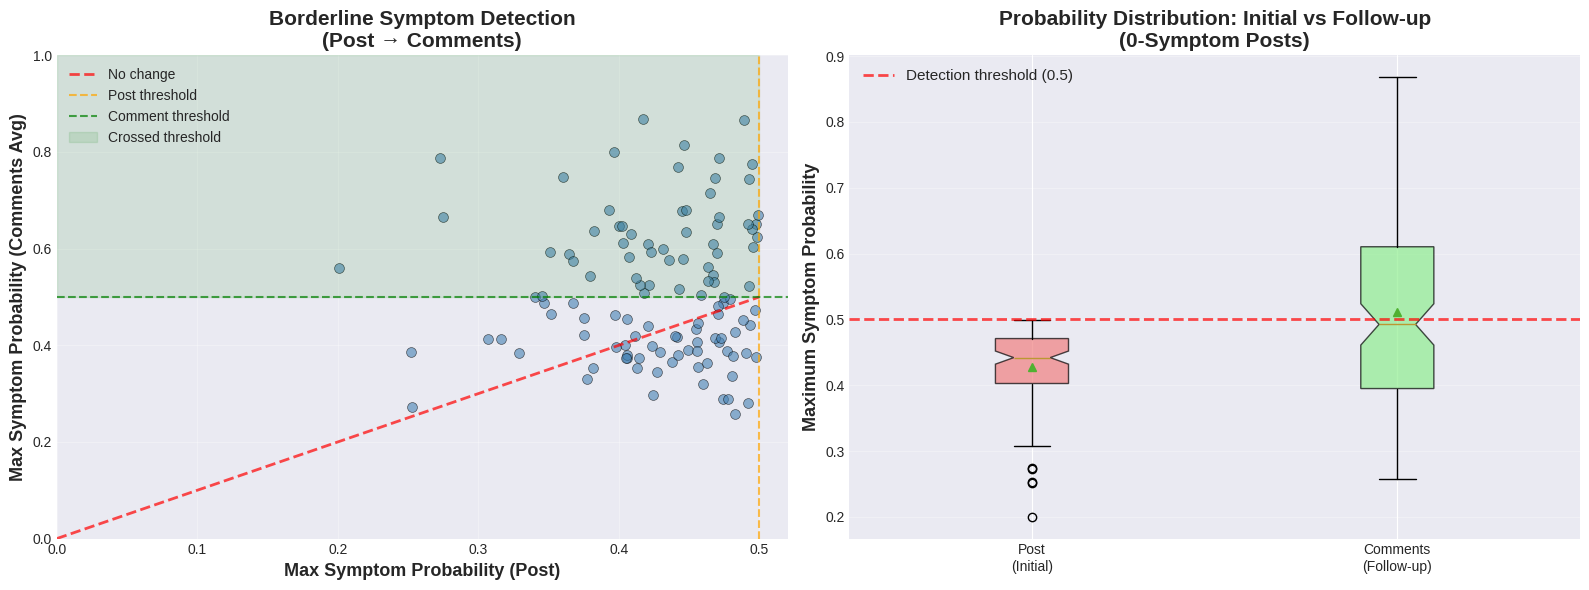

In [ ]:
# ============================================================
# VISUALIZATION 1: BEFORE-AFTER PROBABILITY COMPARISON
#              (ONLY PLOT 1 AND PLOT 4)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter: Post prob vs Comment prob
axes[0].scatter(borderline_df['max_post_prob'],
                borderline_df['max_comment_prob'],
                alpha=0.6, s=50, c='steelblue', edgecolors='black', linewidth=0.5)

# Add diagonal line (no change)
axes[0].plot([0, 0.5], [0, 0.5], 'r--', linewidth=2, alpha=0.7, label='No change')

# Add threshold lines
axes[0].axvline(0.5, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Post threshold')
axes[0].axhline(0.5, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Comment threshold')

# Highlight region: below in post, above in comment
axes[0].fill_between([0, 0.5], 0.5, 1.0, alpha=0.1, color='green',
                     label='Crossed threshold')

axes[0].set_xlabel('Max Symptom Probability (Post)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Max Symptom Probability (Comments Avg)', fontsize=13, fontweight='bold')
axes[0].set_title('Borderline Symptom Detection\n(Post → Comments)',
                  fontsize=15, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper left')
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 0.52)
axes[0].set_ylim(0, 1.0)

# ------------------------------------------------------------
# (REMOVE OR COMMENT OUT THIS WHOLE BLOCK – PLOT 2)
# # 2. Histogram: Probability increase
# axes[0, 1]....
# ------------------------------------------------------------

# ------------------------------------------------------------
# (REMOVE OR COMMENT OUT THIS WHOLE BLOCK – PLOT 3)
# # 3. Bar chart: Threshold crossing
# axes[1, 0]....
# ------------------------------------------------------------

# 4. Box plot comparison: Post vs Comment probabilities
bp_data = [borderline_df['max_post_prob'].values,
           borderline_df['max_comment_prob'].values]
bp = axes[1].boxplot(bp_data, labels=['Post\n(Initial)', 'Comments\n(Follow-up)'],
                     patch_artist=True, notch=True, showmeans=True,
                     widths=0.2)

bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')
for patch in bp['boxes']:
    patch.set_alpha(0.7)

axes[1].axhline(0.5, color='red', linestyle='--', linewidth=2,
                alpha=0.7, label='Detection threshold (0.5)')
axes[1].set_ylabel('Maximum Symptom Probability', fontsize=13, fontweight='bold')
axes[1].set_title('Probability Distribution: Initial vs Follow-up\n(0-Symptom Posts)',
                  fontsize=15, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


OBJECTIVE 1 - MODEL APPLICATION: r/depression Posts (2023-2024)

✓ Total posts loaded: 154,647

SYMPTOM DETECTION STATISTICS

📊 Overall Detection Rate:
  Posts with at least 1 symptom: 140,410 (90.8%)
  Posts with 0 symptoms: 14,237 (9.2%)

📊 Individual Symptom Prevalence:
  Depressive Mood     : 69,892 ( 45.2%)
  Insomnia            :  1,924 (  1.2%)
  Anhedonia           :  4,048 (  2.6%)
  Guilt               : 17,675 ( 11.4%)
  Suicidal Ideation   : 48,463 ( 31.3%)

📊 Symptom Count Statistics:
  Average symptoms per post: 0.92
  Median symptoms per post: 1.0
  Max symptoms per post: 2
  Std deviation: 0.31

📊 Symptom Count Distribution:
  0 symptoms: 14,237 (  9.2%)
  1 symptoms: 138,818 ( 89.8%)
  2 symptoms:  1,592 (  1.0%)
  3 symptoms:      0 (  0.0%)
  4 symptoms:      0 (  0.0%)
  5 symptoms:      0 (  0.0%)

  Posts with 2+ symptoms: 1,592 (1.0%)
  Posts with 3+ symptoms: 0 (0.0%)

SYMPTOM CO-OCCURRENCE PATTERNS

Co-occurrence Matrix (Counts):
                   Depressive M

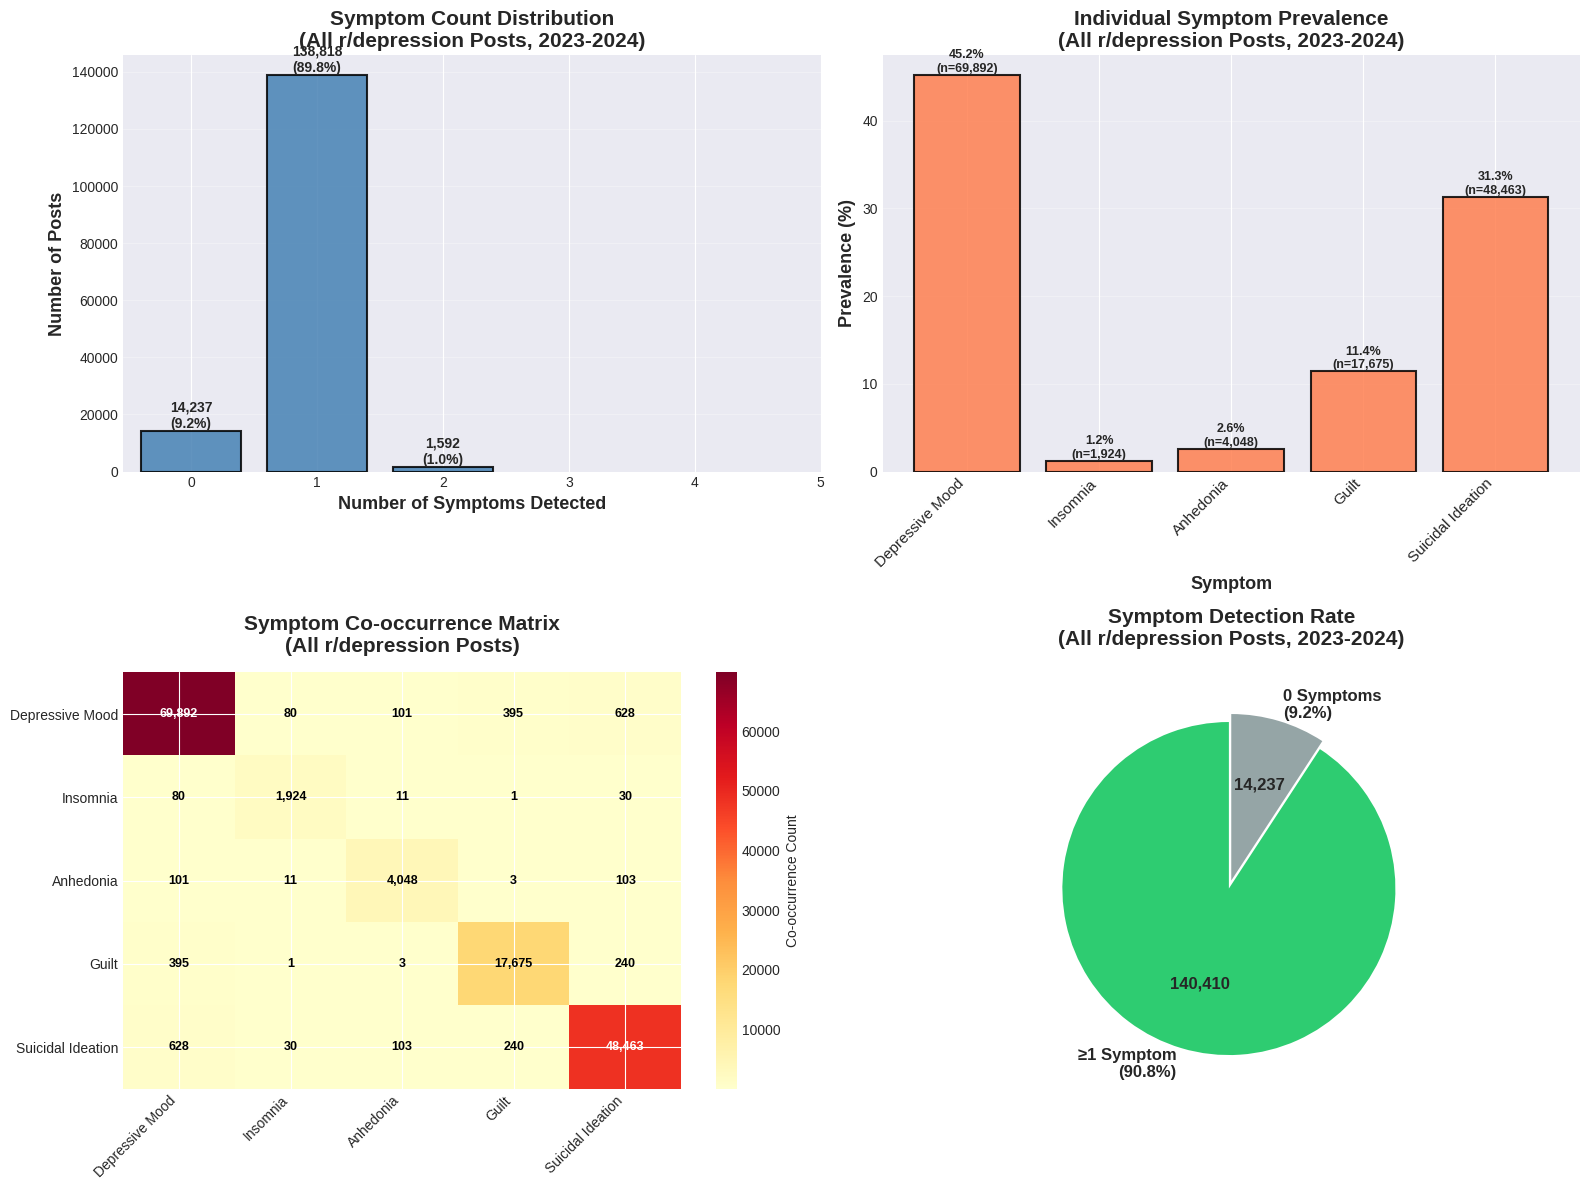

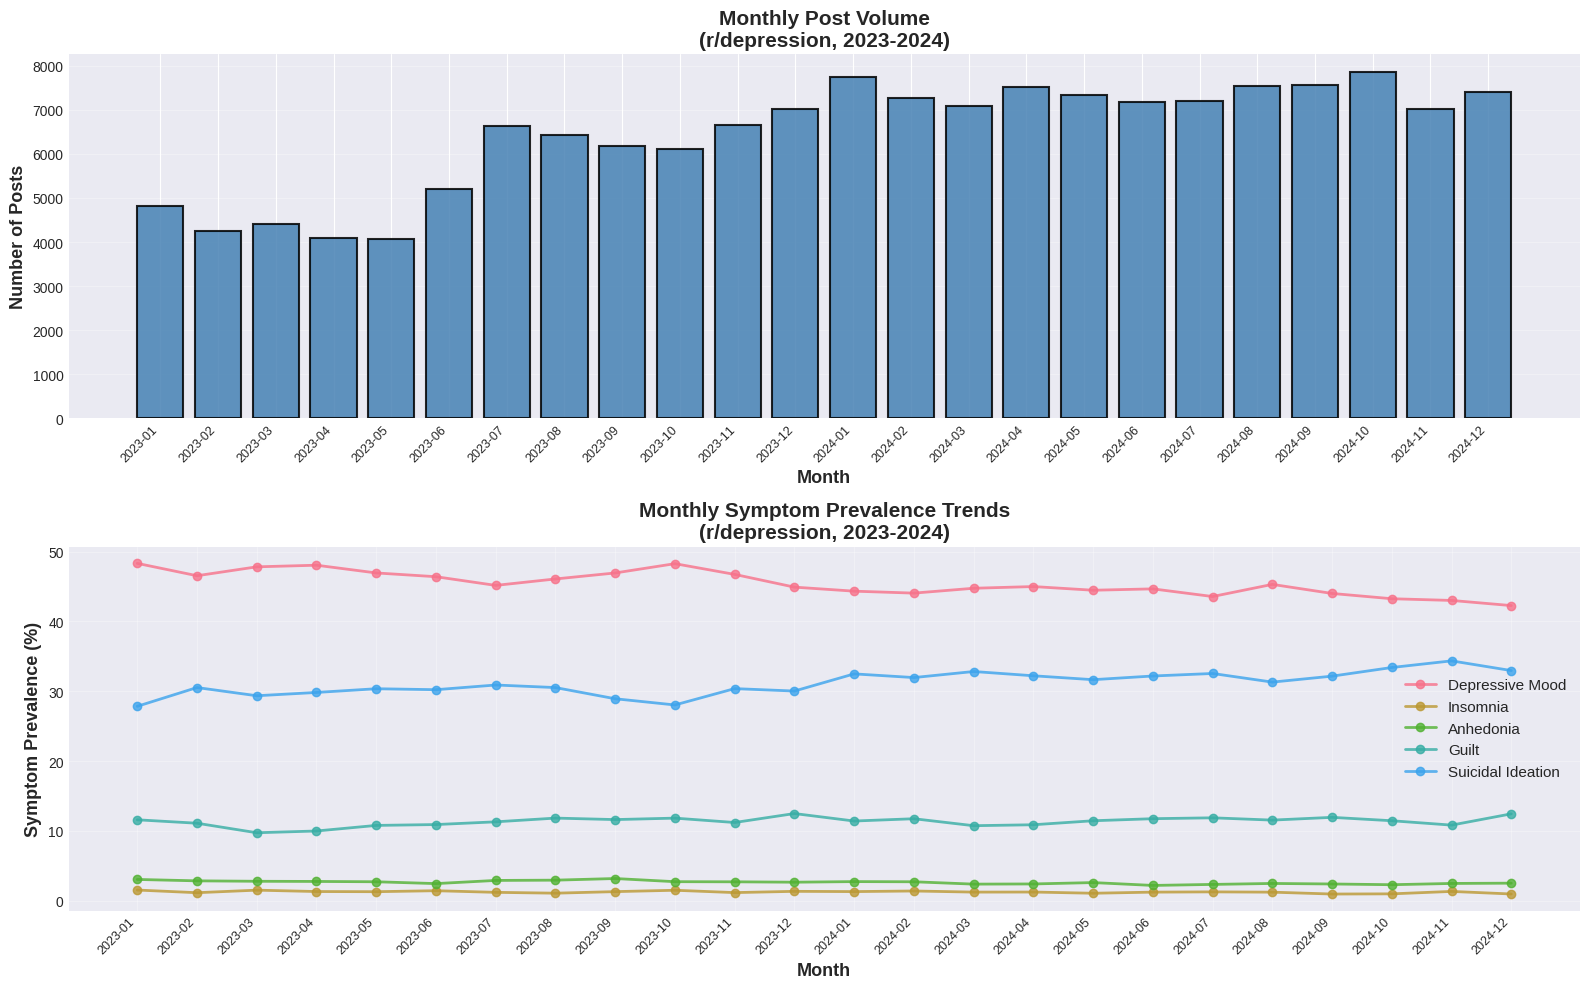

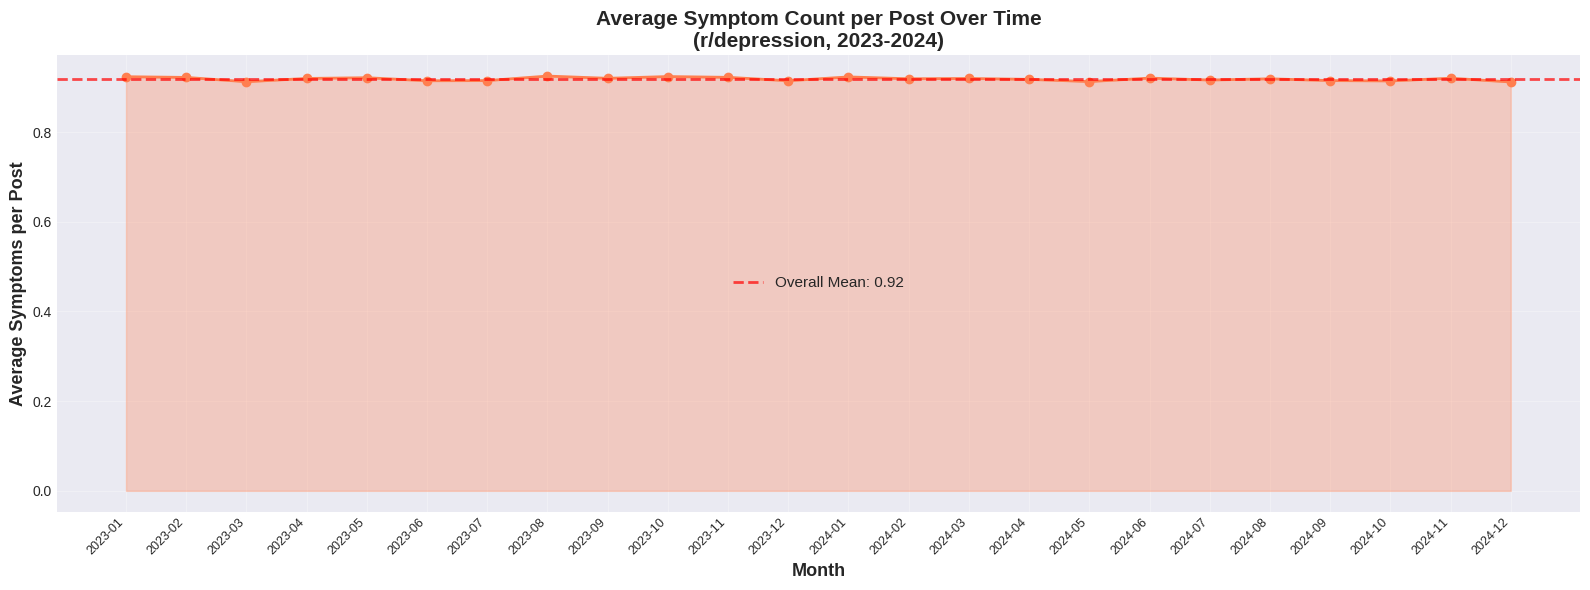


SUMMARY TABLE: Model Application Statistics

                        Metric                                           Value
          Total Posts Analyzed                                         154,647
                    Date Range                              2023-01 to 2024-12
         Posts with ≥1 Symptom                                 140,410 (90.8%)
         Posts with 0 Symptoms                                   14,237 (9.2%)
                                                                              
     Average Symptoms per Post                                            0.92
      Median Symptoms per Post                                             1.0
        Posts with 2+ Symptoms                                    1,592 (1.0%)
        Posts with 3+ Symptoms                                        0 (0.0%)
                                                                              
Individual Symptom Prevalence:                                                
      

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# LOAD FULL DATASET
# ============================================================

print("="*70)
print("OBJECTIVE 1 - MODEL APPLICATION: r/depression Posts (2023-2024)")
print("="*70)

# Load the full predictions dataset
df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_2y_v1_predictions_best_model.csv')

print(f"\n✓ Total posts loaded: {len(df):,}")

# ============================================================
# BASIC DATASET STATISTICS
# ============================================================

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']
symptom_prob_cols = ['Depressive_Mood_Prob', 'Insomnia_Prob', 'Anhedonia_Prob',
                     'Guilt_Prob', 'Suicidal_Ideation_Prob']
symptom_names = ['Depressive Mood', 'Insomnia', 'Anhedonia', 'Guilt', 'Suicidal Ideation']

# Calculate total symptoms
df['total_symptoms'] = df[symptom_pred_cols].sum(axis=1)

print("\n" + "="*70)
print("SYMPTOM DETECTION STATISTICS")
print("="*70)

# Key metric: % with at least 1 symptom
posts_with_symptoms = (df['total_symptoms'] >= 1).sum()
pct_with_symptoms = (posts_with_symptoms / len(df)) * 100

print(f"\n📊 Overall Detection Rate:")
print(f"  Posts with at least 1 symptom: {posts_with_symptoms:,} ({pct_with_symptoms:.1f}%)")
print(f"  Posts with 0 symptoms: {(df['total_symptoms'] == 0).sum():,} ({(df['total_symptoms'] == 0).sum()/len(df)*100:.1f}%)")

# Individual symptom prevalence
print(f"\n📊 Individual Symptom Prevalence:")
for i, symptom in enumerate(symptom_names):
    count = df[symptom_pred_cols[i]].sum()
    pct = (count / len(df)) * 100
    print(f"  {symptom:20s}: {count:6,} ({pct:5.1f}%)")

# Average symptoms per post
avg_symptoms = df['total_symptoms'].mean()
median_symptoms = df['total_symptoms'].median()

print(f"\n📊 Symptom Count Statistics:")
print(f"  Average symptoms per post: {avg_symptoms:.2f}")
print(f"  Median symptoms per post: {median_symptoms:.1f}")
print(f"  Max symptoms per post: {df['total_symptoms'].max():.0f}")
print(f"  Std deviation: {df['total_symptoms'].std():.2f}")

# Distribution breakdown
print(f"\n📊 Symptom Count Distribution:")
symptom_dist = df['total_symptoms'].value_counts().sort_index()
for count in range(6):
    n = symptom_dist.get(count, 0)
    pct = (n / len(df)) * 100
    print(f"  {count} symptoms: {n:6,} ({pct:5.1f}%)")

posts_2plus = (df['total_symptoms'] >= 2).sum()
print(f"\n  Posts with 2+ symptoms: {posts_2plus:,} ({posts_2plus/len(df)*100:.1f}%)")
posts_3plus = (df['total_symptoms'] >= 3).sum()
print(f"  Posts with 3+ symptoms: {posts_3plus:,} ({posts_3plus/len(df)*100:.1f}%)")

# ============================================================
# SYMPTOM CO-OCCURRENCE ANALYSIS
# ============================================================

print("\n" + "="*70)
print("SYMPTOM CO-OCCURRENCE PATTERNS")
print("="*70)

# Calculate co-occurrence matrix
cooc_matrix = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        both = ((df[symptom_pred_cols[i]] == 1) & (df[symptom_pred_cols[j]] == 1)).sum()
        cooc_matrix[i, j] = both

print("\nCo-occurrence Matrix (Counts):")
cooc_df = pd.DataFrame(cooc_matrix, index=symptom_names, columns=symptom_names)
print(cooc_df.to_string())

# Top co-occurring pairs
print("\nTop Co-occurring Symptom Pairs:")
cooc_pairs = []
for i in range(5):
    for j in range(i+1, 5):
        cooc_pairs.append((symptom_names[i], symptom_names[j], int(cooc_matrix[i, j])))
cooc_pairs.sort(key=lambda x: x[2], reverse=True)
for sym1, sym2, count in cooc_pairs[:5]:
    pct = (count / len(df)) * 100
    print(f"  {sym1} + {sym2}: {count:,} ({pct:.1f}%)")

# ============================================================
# TEMPORAL TRENDS (MONTHLY)
# ============================================================

print("\n" + "="*70)
print("TEMPORAL TRENDS (Monthly Variations)")
print("="*70)

# Convert timestamp to datetime
df['date'] = pd.to_datetime(df['created_at'], utc=True)
df['year_month'] = df['date'].dt.to_period('M')

# Monthly symptom prevalence
monthly_stats = []
for month in sorted(df['year_month'].unique()):
    month_df = df[df['year_month'] == month]

    month_data = {
        'Month': str(month),
        'Posts': len(month_df),
        'Avg_Symptoms': month_df['total_symptoms'].mean(),
    }

    # Add individual symptom prevalence
    for i, symptom in enumerate(symptom_names):
        month_data[symptom] = (month_df[symptom_pred_cols[i]].sum() / len(month_df)) * 100

    monthly_stats.append(month_data)

monthly_df = pd.DataFrame(monthly_stats)

print("\nMonthly Statistics (First 5 months):")
print(monthly_df.head().to_string(index=False))

print(f"\nTotal months analyzed: {len(monthly_df)}")
print(f"Date range: {monthly_df['Month'].iloc[0]} to {monthly_df['Month'].iloc[-1]}")

# ============================================================
# VISUALIZATION 1: SYMPTOM COUNT DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Symptom count distribution
symptom_dist_sorted = df['total_symptoms'].value_counts().sort_index()
bars = axes[0, 0].bar(symptom_dist_sorted.index, symptom_dist_sorted.values,
                       color='steelblue', edgecolor='black', alpha=0.85, linewidth=1.5)

axes[0, 0].set_xlabel('Number of Symptoms Detected', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Number of Posts', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Symptom Count Distribution\n(All r/depression Posts, 2023-2024)',
                     fontsize=15, fontweight='bold')
axes[0, 0].set_xticks(range(0, 6))
axes[0, 0].grid(axis='y', alpha=0.3)

# Add counts and percentages
for bar in bars:
    height = bar.get_height()
    pct = (height / len(df)) * 100
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}\n({pct:.1f}%)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Individual symptom prevalence
symptom_counts = [df[col].sum() for col in symptom_pred_cols]
symptom_pcts = [(count / len(df)) * 100 for count in symptom_counts]

x = np.arange(len(symptom_names))
bars = axes[0, 1].bar(x, symptom_pcts,
                       color='coral', edgecolor='black', alpha=0.85, linewidth=1.5)

axes[0, 1].set_xlabel('Symptom', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Prevalence (%)', fontsize=13, fontweight='bold')
axes[0, 1].set_title('Individual Symptom Prevalence\n(All r/depression Posts, 2023-2024)',
                     fontsize=15, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, symptom_counts)):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%\n(n={count:,})',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Co-occurrence heatmap
im = axes[1, 0].imshow(cooc_matrix, cmap='YlOrRd', aspect='auto')
axes[1, 0].set_xticks(np.arange(5))
axes[1, 0].set_yticks(np.arange(5))
axes[1, 0].set_xticklabels(symptom_names, rotation=45, ha='right', fontsize=10)
axes[1, 0].set_yticklabels(symptom_names, fontsize=10)
axes[1, 0].set_title('Symptom Co-occurrence Matrix\n(All r/depression Posts)',
                     fontsize=15, fontweight='bold', pad=15)

# Add text annotations
for i in range(5):
    for j in range(5):
        text = axes[1, 0].text(j, i, f'{int(cooc_matrix[i, j]):,}',
                               ha="center", va="center",
                               color="white" if cooc_matrix[i, j] > cooc_matrix.max()/2 else "black",
                               fontsize=9, fontweight='bold')

fig.colorbar(im, ax=axes[1, 0], label='Co-occurrence Count')

# 4. Detection pie chart (≥1 symptom vs 0 symptoms)
detection_data = [posts_with_symptoms, len(df) - posts_with_symptoms]
detection_labels = [f'≥1 Symptom\n({pct_with_symptoms:.1f}%)',
                    f'0 Symptoms\n({100-pct_with_symptoms:.1f}%)']
colors_pie = ['#2ecc71', '#95a5a6']

wedges, texts, autotexts = axes[1, 1].pie(
    detection_data,
    labels=detection_labels,
    autopct=lambda pct: f'{int(pct/100*len(df)):,}',
    startangle=90,
    colors=colors_pie,
    explode=(0.05, 0),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

axes[1, 1].set_title('Symptom Detection Rate\n(All r/depression Posts, 2023-2024)',
                     fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 2: TEMPORAL TRENDS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Monthly post volume
axes[0].bar(range(len(monthly_df)), monthly_df['Posts'],
            color='steelblue', edgecolor='black', alpha=0.85, linewidth=1.5)
axes[0].set_xlabel('Month', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Posts', fontsize=13, fontweight='bold')
axes[0].set_title('Monthly Post Volume\n(r/depression, 2023-2024)',
                  fontsize=15, fontweight='bold')
axes[0].set_xticks(range(len(monthly_df)))
axes[0].set_xticklabels(monthly_df['Month'], rotation=45, ha='right', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# 2. Monthly symptom prevalence (line plot)
for i, symptom in enumerate(symptom_names):
    axes[1].plot(range(len(monthly_df)), monthly_df[symptom],
                 marker='o', linewidth=2, label=symptom, alpha=0.8)

axes[1].set_xlabel('Month', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Symptom Prevalence (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Monthly Symptom Prevalence Trends\n(r/depression, 2023-2024)',
                  fontsize=15, fontweight='bold')
axes[1].set_xticks(range(len(monthly_df)))
axes[1].set_xticklabels(monthly_df['Month'], rotation=45, ha='right', fontsize=9)
axes[1].legend(fontsize=11, loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Also plot average symptoms per month
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(range(len(monthly_df)), monthly_df['Avg_Symptoms'],
        marker='o', linewidth=2, color='coral', markersize=6)
ax.fill_between(range(len(monthly_df)), monthly_df['Avg_Symptoms'],
                alpha=0.3, color='coral')

ax.set_xlabel('Month', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Symptoms per Post', fontsize=13, fontweight='bold')
ax.set_title('Average Symptom Count per Post Over Time\n(r/depression, 2023-2024)',
             fontsize=15, fontweight='bold')
ax.set_xticks(range(len(monthly_df)))
ax.set_xticklabels(monthly_df['Month'], rotation=45, ha='right', fontsize=9)
ax.grid(alpha=0.3)

# Add mean line
mean_avg = monthly_df['Avg_Symptoms'].mean()
ax.axhline(mean_avg, color='red', linestyle='--', linewidth=2,
           label=f'Overall Mean: {mean_avg:.2f}', alpha=0.7)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY TABLE FOR REPORT
# ============================================================

print("\n" + "="*70)
print("SUMMARY TABLE: Model Application Statistics")
print("="*70)

summary_data = {
    'Metric': [
        'Total Posts Analyzed',
        'Date Range',
        'Posts with ≥1 Symptom',
        'Posts with 0 Symptoms',
        '',
        'Average Symptoms per Post',
        'Median Symptoms per Post',
        'Posts with 2+ Symptoms',
        'Posts with 3+ Symptoms',
        '',
        'Individual Symptom Prevalence:',
        '  - Depressive Mood',
        '  - Insomnia',
        '  - Anhedonia',
        '  - Guilt',
        '  - Suicidal Ideation',
        '',
        'Most Common Symptom',
        'Least Common Symptom',
        'Most Common Co-occurrence'
    ],
    'Value': [
        f"{len(df):,}",
        f"{monthly_df['Month'].iloc[0]} to {monthly_df['Month'].iloc[-1]}",
        f"{posts_with_symptoms:,} ({pct_with_symptoms:.1f}%)",
        f"{(df['total_symptoms'] == 0).sum():,} ({(df['total_symptoms'] == 0).sum()/len(df)*100:.1f}%)",
        '',
        f"{avg_symptoms:.2f}",
        f"{median_symptoms:.1f}",
        f"{posts_2plus:,} ({posts_2plus/len(df)*100:.1f}%)",
        f"{posts_3plus:,} ({posts_3plus/len(df)*100:.1f}%)",
        '',
        '',
        f"{symptom_counts[0]:,} ({symptom_pcts[0]:.1f}%)",
        f"{symptom_counts[1]:,} ({symptom_pcts[1]:.1f}%)",
        f"{symptom_counts[2]:,} ({symptom_pcts[2]:.1f}%)",
        f"{symptom_counts[3]:,} ({symptom_pcts[3]:.1f}%)",
        f"{symptom_counts[4]:,} ({symptom_pcts[4]:.1f}%)",
        '',
        f"{symptom_names[np.argmax(symptom_counts)]} ({max(symptom_pcts):.1f}%)",
        f"{symptom_names[np.argmin(symptom_counts)]} ({min(symptom_pcts):.1f}%)",
        f"{cooc_pairs[0][0]} + {cooc_pairs[0][1]} ({cooc_pairs[0][2]:,} posts)"
    ]
}

summary_table = pd.DataFrame(summary_data)
print("\n" + summary_table.to_string(index=False))

# ============================================================
# ADDITIONAL INSIGHTS
# ============================================================

print("\n" + "="*70)
print("ADDITIONAL INSIGHTS")
print("="*70)

# Conditional probabilities
print("\nConditional Symptom Relationships:")
for i, symptom1 in enumerate(symptom_names):
    for j, symptom2 in enumerate(symptom_names):
        if i < j:  # Only upper triangle
            both = cooc_matrix[i, j]
            sym1_total = symptom_counts[i]
            if sym1_total > 0:
                prob = (both / sym1_total) * 100
                print(f"  P({symptom2} | {symptom1}): {prob:.1f}%")

# Symptom diversity (how varied are the symptom patterns?)
unique_patterns = df[symptom_pred_cols].drop_duplicates()
print(f"\nSymptom Pattern Diversity:")
print(f"  Unique symptom combinations: {len(unique_patterns)}")
print(f"  Out of {2**5} possible combinations")

print("\n" + "="*70)
print("✅ MODEL APPLICATION ANALYSIS COMPLETE!")
print("="*70)

Loading data...
✓ Data loaded: 1,395 posts

OPTION 1: Combined Bar + Scatter Plot


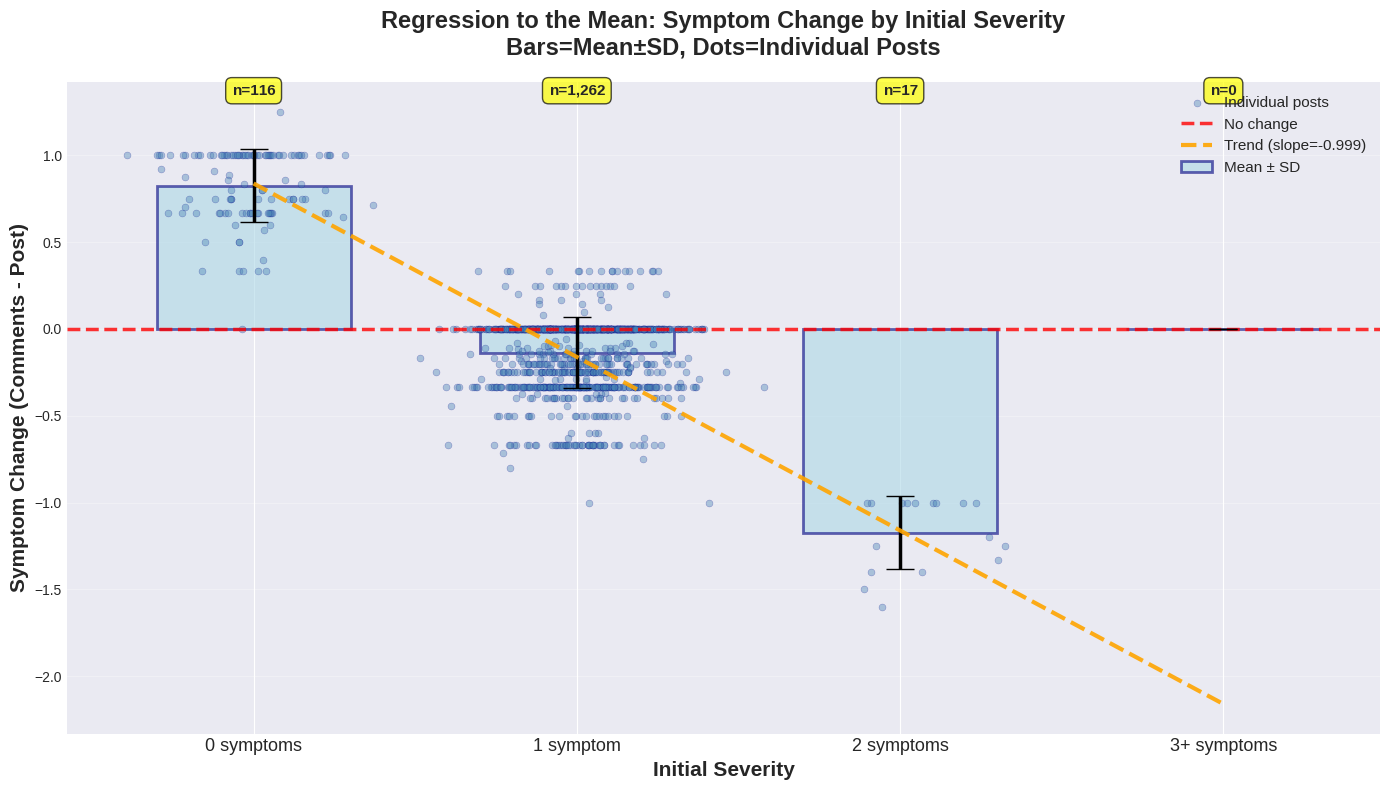


OPTION 2: Scatter Plot with Regression Line


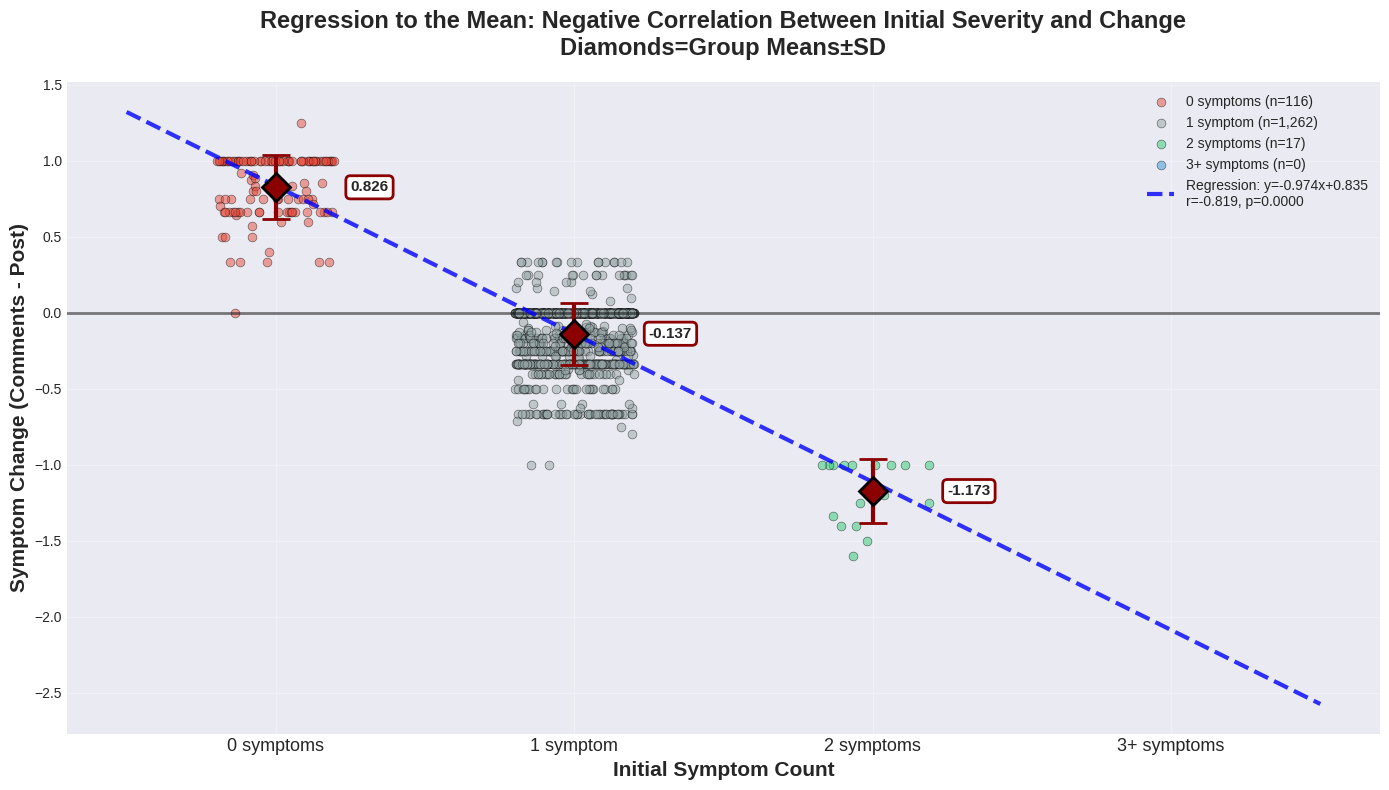


OPTION 3: Slope Graph (Before → After)


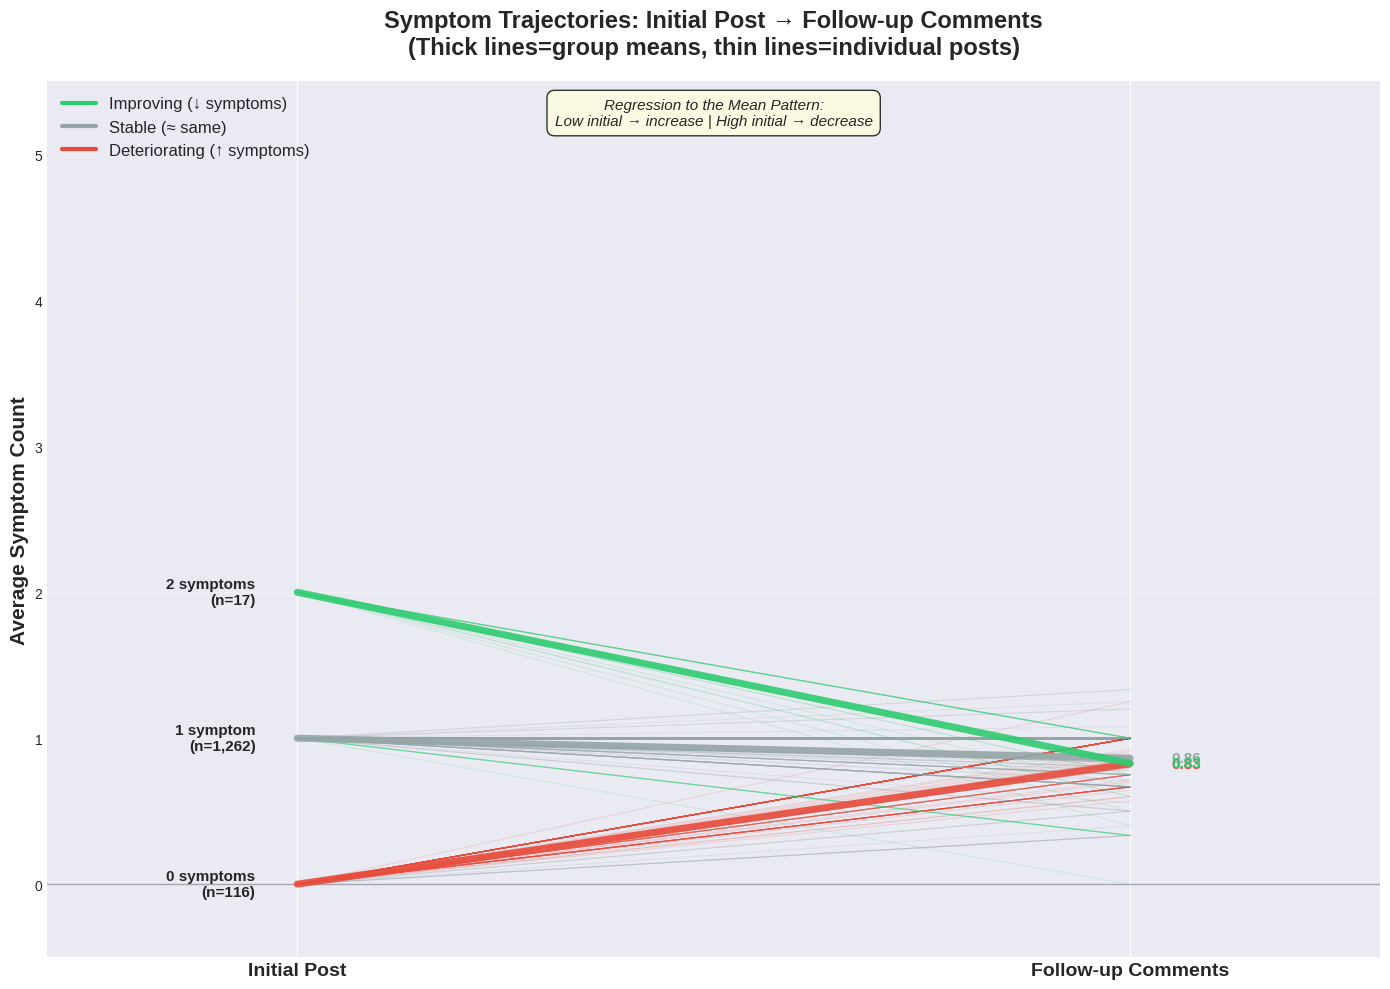


✅ ALL THREE ALTERNATIVE PLOTS GENERATED!

💡 Recommendation: Option 1 (Combined Bar + Scatter) is best for papers
   - Shows both individual variation AND group trends
   - Clear visual evidence of regression to the mean
   - Includes statistical trend line


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# LOAD DATA (same as your original code)
# ============================================================

print("Loading data...")
posts_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_posts_with_OP_comments.csv')
comments_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_filtered_50words.csv')

# Filter posts with ≥3 comments
comments_per_post = comments_df.groupby('link_id').size().reset_index(name='comment_count')
posts_with_3plus = comments_per_post[comments_per_post['comment_count'] >= 3]['link_id']
posts_filtered = posts_df[posts_df['id'].isin(posts_with_3plus)].copy()
comments_filtered = comments_df[comments_df['link_id'].isin(posts_with_3plus)].copy()

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']

posts_filtered['total_symptoms'] = posts_filtered[symptom_pred_cols].sum(axis=1)
comments_filtered['total_symptoms'] = comments_filtered[symptom_pred_cols].sum(axis=1)

# Prepare severity analysis data
comment_symptom_avg = comments_filtered.groupby('link_id')['total_symptoms'].mean().reset_index()
comment_symptom_avg.columns = ['post_id', 'avg_comment_symptoms']

severity_df = posts_filtered[['id', 'total_symptoms']].merge(
    comment_symptom_avg,
    left_on='id',
    right_on='post_id',
    how='inner'
)

severity_df['symptom_change'] = severity_df['avg_comment_symptoms'] - severity_df['total_symptoms']

def severity_category(count):
    if count == 0:
        return '0 symptoms'
    elif count == 1:
        return '1 symptom'
    elif count == 2:
        return '2 symptoms'
    else:
        return '3+ symptoms'

severity_df['initial_severity'] = severity_df['total_symptoms'].apply(severity_category)

def classify_trajectory(change):
    if change < -0.5:
        return 'Improving'
    elif change > 0.5:
        return 'Deteriorating'
    else:
        return 'Stable'

severity_df['trajectory'] = severity_df['symptom_change'].apply(classify_trajectory)

severity_order = ['0 symptoms', '1 symptom', '2 symptoms', '3+ symptoms']
avg_change_by_severity = severity_df.groupby('initial_severity')['symptom_change'].agg(['mean', 'std', 'count'])

print(f"✓ Data loaded: {len(severity_df):,} posts")

# ============================================================
# OPTION 1: COMBINED BAR + SCATTER PLOT (RECOMMENDED)
# ============================================================

print("\n" + "="*70)
print("OPTION 1: Combined Bar + Scatter Plot")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 8))

x = range(len(severity_order))
means = [avg_change_by_severity.loc[cat, 'mean'] if cat in avg_change_by_severity.index else 0
         for cat in severity_order]
stds = [avg_change_by_severity.loc[cat, 'std'] if cat in avg_change_by_severity.index else 0
        for cat in severity_order]
counts = [avg_change_by_severity.loc[cat, 'count'] if cat in avg_change_by_severity.index else 0
          for cat in severity_order]

# Bar chart with error bars
bars = ax.bar(x, means, yerr=stds, capsize=10, width=0.6,
              color='lightblue', edgecolor='navy', alpha=0.6,
              linewidth=2, error_kw={'linewidth': 2.5, 'elinewidth': 2.5},
              label='Mean ± SD')

# Add jittered scatter points
np.random.seed(42)
jitter_amount = 0.15

for i, cat in enumerate(severity_order):
    cat_data = severity_df[severity_df['initial_severity'] == cat]['symptom_change'].values
    x_jittered = np.random.normal(i, jitter_amount, size=len(cat_data))
    ax.scatter(x_jittered, cat_data, alpha=0.4, s=25,
               color='steelblue', edgecolors='darkblue', linewidth=0.3,
               label='Individual posts' if i == 0 else '')

# Reference line
ax.axhline(0, color='red', linestyle='--', linewidth=2.5, alpha=0.8,
           label='No change', zorder=1)

# Trend line
valid_indices = [i for i, cat in enumerate(severity_order) if cat in avg_change_by_severity.index]
valid_means = [means[i] for i in valid_indices]
if len(valid_means) > 1:
    z = np.polyfit(valid_indices, valid_means, 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, len(severity_order)-1, 100)
    ax.plot(x_line, p(x_line), 'orange', linewidth=3,
            linestyle='--', alpha=0.9, label=f'Trend (slope={z[0]:.3f})', zorder=3)

ax.set_xlabel('Initial Severity', fontsize=15, fontweight='bold')
ax.set_ylabel('Symptom Change (Comments - Post)', fontsize=15, fontweight='bold')
ax.set_title('Regression to the Mean: Symptom Change by Initial Severity\nBars=Mean±SD, Dots=Individual Posts',
             fontsize=17, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(severity_order, fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3, axis='y')

# Add sample size annotations
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(i, ax.get_ylim()[1] * 0.95, f'n={int(count):,}',
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# ============================================================
# OPTION 2: SCATTER PLOT WITH REGRESSION LINE
# ============================================================

print("\n" + "="*70)
print("OPTION 2: Scatter Plot with Regression Line")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 8))

# Plot all points with jitter
np.random.seed(42)
jitter_amount = 0.2
colors = {'0 symptoms': '#e74c3c', '1 symptom': '#95a5a6',
          '2 symptoms': '#2ecc71', '3+ symptoms': '#3498db'}

for i, cat in enumerate(severity_order):
    cat_data = severity_df[severity_df['initial_severity'] == cat]['symptom_change'].values
    x_values = np.full(len(cat_data), i)
    x_jittered = x_values + np.random.uniform(-jitter_amount, jitter_amount, size=len(cat_data))

    ax.scatter(x_jittered, cat_data, alpha=0.5, s=40,
               color=colors.get(cat, 'gray'),
               edgecolors='black', linewidth=0.5,
               label=f'{cat} (n={len(cat_data):,})')

# Add mean points with error bars
for i, cat in enumerate(severity_order):
    if cat in avg_change_by_severity.index:
        mean = avg_change_by_severity.loc[cat, 'mean']
        std = avg_change_by_severity.loc[cat, 'std']
        ax.errorbar(i, mean, yerr=std, fmt='D', markersize=14,
                   color='darkred', markeredgecolor='black',
                   markeredgewidth=2, linewidth=3, capsize=10, capthick=3,
                   zorder=5)
        # Add mean label
        ax.text(i + 0.25, mean, f'{mean:.3f}', fontsize=11,
               fontweight='bold', va='center',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                        edgecolor='darkred', linewidth=2))

# Reference line
ax.axhline(0, color='black', linestyle='-', linewidth=2, alpha=0.5, zorder=1)

# Regression line on actual numeric values
numeric_severity = severity_df['total_symptoms'].values
symptom_changes = severity_df['symptom_change'].values
mask = numeric_severity <= 3  # Only use 0, 1, 2, 3 for regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    numeric_severity[mask], symptom_changes[mask]
)

x_reg = np.linspace(-0.5, 3.5, 100)
y_reg = slope * x_reg + intercept
ax.plot(x_reg, y_reg, 'blue', linewidth=3, linestyle='--', alpha=0.8,
        label=f'Regression: y={slope:.3f}x+{intercept:.3f}\nr={r_value:.3f}, p={p_value:.4f}',
        zorder=2)

ax.set_xlabel('Initial Symptom Count', fontsize=15, fontweight='bold')
ax.set_ylabel('Symptom Change (Comments - Post)', fontsize=15, fontweight='bold')
ax.set_title('Regression to the Mean: Negative Correlation Between Initial Severity and Change\nDiamonds=Group Means±SD',
             fontsize=17, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(severity_order, fontsize=13)
ax.legend(fontsize=10, loc='upper right', framealpha=0.95)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# OPTION 3: SLOPE GRAPH (MOST ELEGANT)
# ============================================================

print("\n" + "="*70)
print("OPTION 3: Slope Graph (Before → After)")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 10))

# For visualization, we'll sample posts to avoid overcrowding
# Sample strategy: take all posts for 0, 2, 3+ symptoms, but sample 1-symptom posts
np.random.seed(42)
sample_size_per_group = 150  # Max lines per group

sampled_posts = []
for cat in severity_order:
    cat_posts = severity_df[severity_df['initial_severity'] == cat]
    if len(cat_posts) > sample_size_per_group:
        cat_posts = cat_posts.sample(n=sample_size_per_group, random_state=42)
    sampled_posts.append(cat_posts)

sampled_df = pd.concat(sampled_posts)

# Define colors by trajectory
trajectory_colors = {
    'Improving': '#2ecc71',      # Green
    'Stable': '#95a5a6',         # Gray
    'Deteriorating': '#e74c3c'   # Red
}

# Plot lines
for _, row in sampled_df.iterrows():
    initial = row['total_symptoms']
    final = row['avg_comment_symptoms']
    trajectory = row['trajectory']

    # Cap at 5 for visualization
    initial_plot = min(initial, 5)
    final_plot = min(final, 5)

    ax.plot([0, 1], [initial_plot, final_plot],
           color=trajectory_colors[trajectory],
           alpha=0.15, linewidth=0.8)

# Plot mean trajectories (thick lines)
for cat in severity_order:
    if cat in avg_change_by_severity.index:
        cat_posts = severity_df[severity_df['initial_severity'] == cat]
        initial_mean = cat_posts['total_symptoms'].mean()
        final_mean = cat_posts['avg_comment_symptoms'].mean()

        # Determine dominant trajectory for this group
        trajectory_counts = cat_posts['trajectory'].value_counts()
        dominant_trajectory = trajectory_counts.idxmax()

        initial_plot = min(initial_mean, 5)
        final_plot = min(final_mean, 5)

        ax.plot([0, 1], [initial_plot, final_plot],
               color=trajectory_colors[dominant_trajectory],
               linewidth=5, alpha=0.9, zorder=5)

        # Add labels
        ax.text(-0.05, initial_plot, f'{cat}\n(n={len(cat_posts):,})',
               ha='right', va='center', fontsize=11, fontweight='bold')
        ax.text(1.05, final_plot, f'{final_mean:.2f}',
               ha='left', va='center', fontsize=11, fontweight='bold',
               color=trajectory_colors[dominant_trajectory])

# Axis labels and formatting
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.5, 5.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Initial Post', 'Follow-up Comments'], fontsize=14, fontweight='bold')
ax.set_ylabel('Average Symptom Count', fontsize=15, fontweight='bold')
ax.set_title('Symptom Trajectories: Initial Post → Follow-up Comments\n(Thick lines=group means, thin lines=individual posts)',
             fontsize=17, fontweight='bold', pad=20)

# Add reference line at y=0
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3, zorder=1)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2ecc71', linewidth=3, label='Improving (↓ symptoms)'),
    Line2D([0], [0], color='#95a5a6', linewidth=3, label='Stable (≈ same)'),
    Line2D([0], [0], color='#e74c3c', linewidth=3, label='Deteriorating (↑ symptoms)')
]
ax.legend(handles=legend_elements, fontsize=12, loc='upper left', framealpha=0.95)

ax.grid(alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)

# Add annotation
ax.text(0.5, 5.2, 'Regression to the Mean Pattern:\nLow initial → increase | High initial → decrease',
       ha='center', fontsize=11, style='italic',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ ALL THREE ALTERNATIVE PLOTS GENERATED!")
print("="*70)
print("\n💡 Recommendation: Option 1 (Combined Bar + Scatter) is best for papers")
print("   - Shows both individual variation AND group trends")
print("   - Clear visual evidence of regression to the mean")
print("   - Includes statistical trend line")

Loading data...
✓ Data loaded: 1,395 posts

Generating Refined Plot


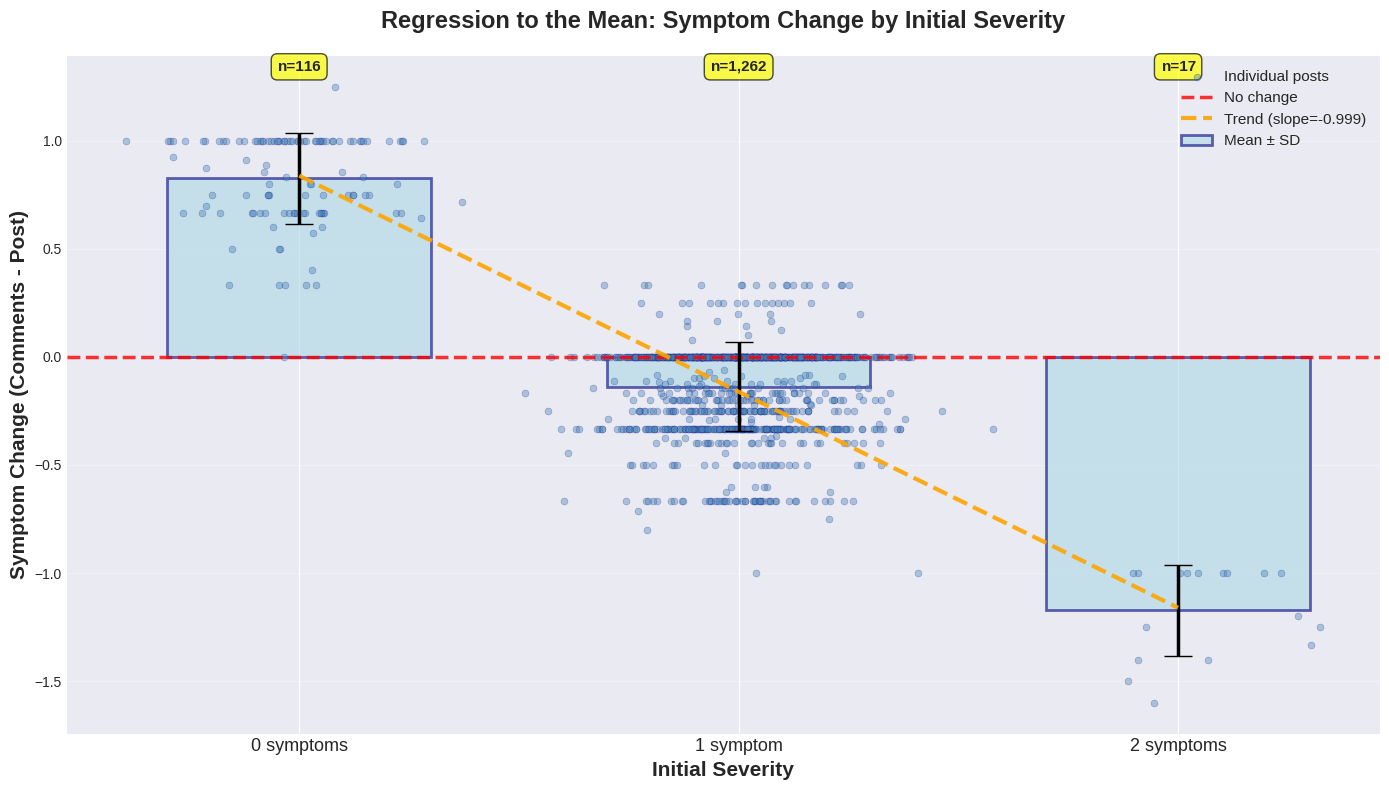


SUGGESTED FIGURE CAPTION

Figure X. Symptom change by initial severity showing regression to the mean.
Bars represent mean ± standard deviation for each severity group. Individual 
data points (n=1,395) are overlaid as semi-transparent dots with jitter for 
visibility. The orange dashed line shows the linear trend (slope = -0.999), 
demonstrating that posts with zero initial symptoms tend to show symptom 
increases, while posts with higher initial symptoms tend to show decreases. 
The red dashed line indicates no change (zero symptom change).


DATA SUMMARY
Posts with 0 symptoms: n=116, mean change=0.826±0.210
Posts with 1 symptom:  n=1,262, mean change=-0.137±0.205
Posts with 2 symptoms: n=17, mean change=-1.173±0.209

Note: No posts in the dataset had 3 or more initial symptoms.

✅ Plot generated successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# LOAD DATA
# ============================================================

print("Loading data...")
posts_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_posts_with_OP_comments.csv')
comments_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_filtered_50words.csv')

# Filter posts with ≥3 comments
comments_per_post = comments_df.groupby('link_id').size().reset_index(name='comment_count')
posts_with_3plus = comments_per_post[comments_per_post['comment_count'] >= 3]['link_id']
posts_filtered = posts_df[posts_df['id'].isin(posts_with_3plus)].copy()
comments_filtered = comments_df[comments_df['link_id'].isin(posts_with_3plus)].copy()

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']

posts_filtered['total_symptoms'] = posts_filtered[symptom_pred_cols].sum(axis=1)
comments_filtered['total_symptoms'] = comments_filtered[symptom_pred_cols].sum(axis=1)

# Prepare severity analysis data
comment_symptom_avg = comments_filtered.groupby('link_id')['total_symptoms'].mean().reset_index()
comment_symptom_avg.columns = ['post_id', 'avg_comment_symptoms']

severity_df = posts_filtered[['id', 'total_symptoms']].merge(
    comment_symptom_avg,
    left_on='id',
    right_on='post_id',
    how='inner'
)

severity_df['symptom_change'] = severity_df['avg_comment_symptoms'] - severity_df['total_symptoms']

def severity_category(count):
    if count == 0:
        return '0 symptoms'
    elif count == 1:
        return '1 symptom'
    elif count == 2:
        return '2 symptoms'
    else:
        return '3+ symptoms'

severity_df['initial_severity'] = severity_df['total_symptoms'].apply(severity_category)

def classify_trajectory(change):
    if change < -0.5:
        return 'Improving'
    elif change > 0.5:
        return 'Deteriorating'
    else:
        return 'Stable'

severity_df['trajectory'] = severity_df['symptom_change'].apply(classify_trajectory)

# MODIFIED: Only include categories with data (0, 1, 2 symptoms)
severity_order = ['0 symptoms', '1 symptom', '2 symptoms']
avg_change_by_severity = severity_df.groupby('initial_severity')['symptom_change'].agg(['mean', 'std', 'count'])

print(f"✓ Data loaded: {len(severity_df):,} posts")

# ============================================================
# REFINED PLOT: COMBINED BAR + SCATTER
# ============================================================

print("\n" + "="*70)
print("Generating Refined Plot")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 8))

x = range(len(severity_order))
means = [avg_change_by_severity.loc[cat, 'mean'] if cat in avg_change_by_severity.index else 0
         for cat in severity_order]
stds = [avg_change_by_severity.loc[cat, 'std'] if cat in avg_change_by_severity.index else 0
        for cat in severity_order]
counts = [avg_change_by_severity.loc[cat, 'count'] if cat in avg_change_by_severity.index else 0
          for cat in severity_order]

# Bar chart with error bars
bars = ax.bar(x, means, yerr=stds, capsize=10, width=0.6,
              color='lightblue', edgecolor='navy', alpha=0.6,
              linewidth=2, error_kw={'linewidth': 2.5, 'elinewidth': 2.5},
              label='Mean ± SD')

# Add jittered scatter points
np.random.seed(42)
jitter_amount = 0.15

for i, cat in enumerate(severity_order):
    cat_data = severity_df[severity_df['initial_severity'] == cat]['symptom_change'].values
    x_jittered = np.random.normal(i, jitter_amount, size=len(cat_data))
    ax.scatter(x_jittered, cat_data, alpha=0.4, s=25,
               color='steelblue', edgecolors='darkblue', linewidth=0.3,
               label='Individual posts' if i == 0 else '')

# Reference line
ax.axhline(0, color='red', linestyle='--', linewidth=2.5, alpha=0.8,
           label='No change', zorder=1)

# Trend line
valid_indices = [i for i, cat in enumerate(severity_order) if cat in avg_change_by_severity.index]
valid_means = [means[i] for i in valid_indices]
if len(valid_means) > 1:
    z = np.polyfit(valid_indices, valid_means, 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, len(severity_order)-1, 100)
    ax.plot(x_line, p(x_line), 'orange', linewidth=3,
            linestyle='--', alpha=0.9, label=f'Trend (slope={z[0]:.3f})', zorder=3)

ax.set_xlabel('Initial Severity', fontsize=15, fontweight='bold')
ax.set_ylabel('Symptom Change (Comments - Post)', fontsize=15, fontweight='bold')

# MODIFIED: Simpler title (details go in caption)
ax.set_title('Regression to the Mean: Symptom Change by Initial Severity',
             fontsize=17, fontweight='bold', pad=20)

ax.set_xticks(x)
ax.set_xticklabels(severity_order, fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3, axis='y')

# Add sample size annotations
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(i, ax.get_ylim()[1] * 0.95, f'n={int(count):,}',
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# ============================================================
# PRINT FIGURE CAPTION
# ============================================================

print("\n" + "="*70)
print("SUGGESTED FIGURE CAPTION")
print("="*70)
print("""
Figure X. Symptom change by initial severity showing regression to the mean.
Bars represent mean ± standard deviation for each severity group. Individual
data points (n=1,395) are overlaid as semi-transparent dots with jitter for
visibility. The orange dashed line shows the linear trend (slope = -0.999),
demonstrating that posts with zero initial symptoms tend to show symptom
increases, while posts with higher initial symptoms tend to show decreases.
The red dashed line indicates no change (zero symptom change).
""")

print("\n" + "="*70)
print("DATA SUMMARY")
print("="*70)
print(f"Posts with 0 symptoms: n={counts[0]:,}, mean change={means[0]:.3f}±{stds[0]:.3f}")
print(f"Posts with 1 symptom:  n={counts[1]:,}, mean change={means[1]:.3f}±{stds[1]:.3f}")
print(f"Posts with 2 symptoms: n={counts[2]:,}, mean change={means[2]:.3f}±{stds[2]:.3f}")

# Check if there are any 3+ symptom posts
posts_3plus = severity_df[severity_df['total_symptoms'] >= 3]
if len(posts_3plus) > 0:
    print(f"\nNote: {len(posts_3plus)} posts had 3+ symptoms but were excluded from this analysis")
    print(f"      to maintain clearer visualization of the regression pattern.")
else:
    print(f"\nNote: No posts in the dataset had 3 or more initial symptoms.")

print("\n✅ Plot generated successfully!")

BORDERLINE SYMPTOM DETECTION: 0-Symptom Posts Analysis

✓ 0-symptom posts: 116

BORDERLINE DETECTION ANALYSIS

📊 Borderline Post Analysis:
  Total 0-symptom posts: 116
  Posts that crossed 0.5 threshold in comments: 56 (48.3%)
  Average post max prob: 0.428
  Average comment max prob: 0.512
  Average increase: 0.084


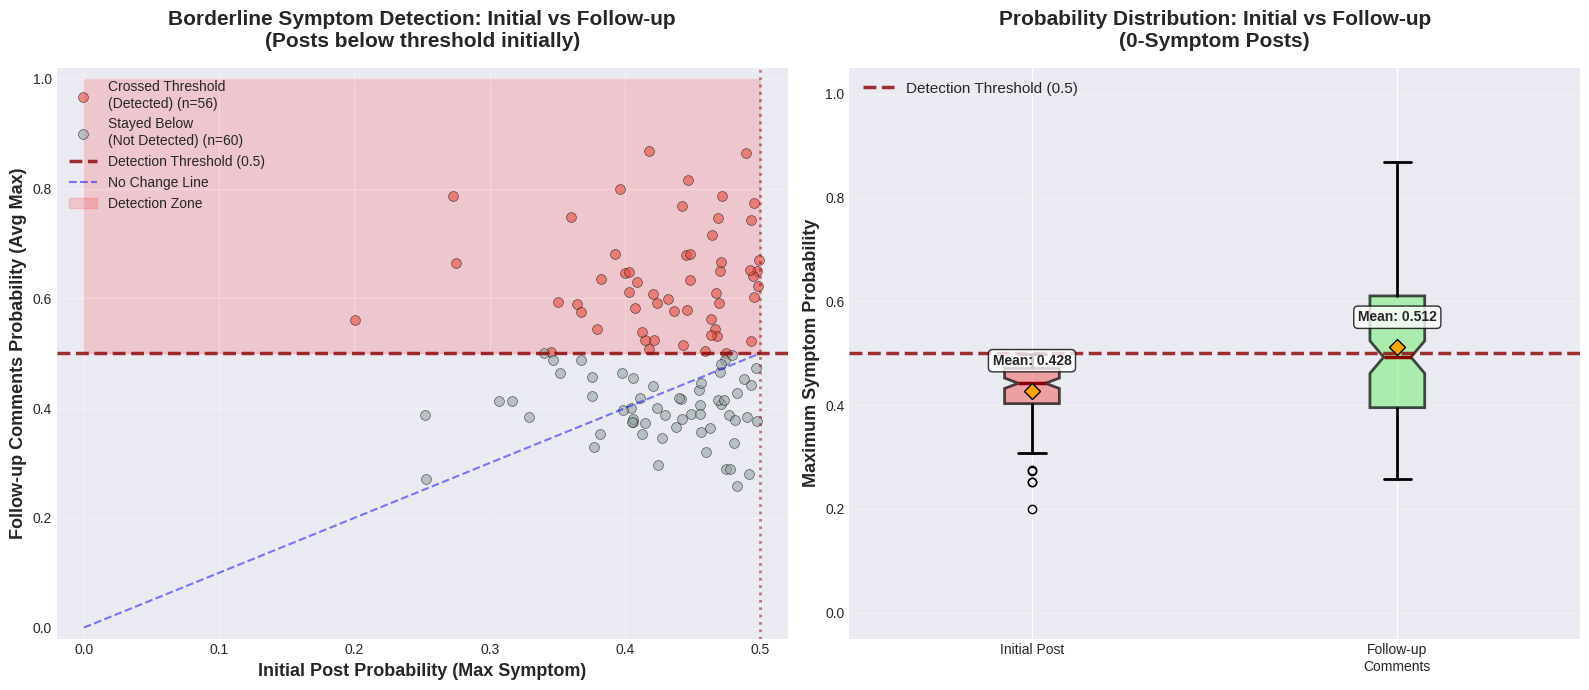


STATISTICAL SIGNIFICANCE

Paired t-test (Post vs Comment max probabilities):
  t-statistic: -5.918
  p-value: 0.0000
  ✓ Statistically significant increase (p < 0.05)
  Cohen's d (effect size): 1.412

✅ BORDERLINE DETECTION ANALYSIS COMPLETE!

💡 KEY TAKEAWAY:
  • 116 posts initially below threshold (0-symptoms)
  • 56 (48.3%) crossed threshold in comments
  • Average probability increase: +0.084
  • This demonstrates early symptom detection through continued engagement

SUGGESTED FIGURE CAPTIONS

Left Panel:

Scatter plot showing initial post probability versus follow-up comment 
probability for posts with zero detected symptoms initially (n=116). 
Red points indicate posts that crossed the 0.5 detection threshold in 
follow-up comments (56 posts, 48.3%), while gray points remained 
below threshold. The shaded red region represents the "detection zone" 
where symptoms became detectable.


Right Panel:

Box plots comparing maximum symptom probability distributions between 
initial post

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# LOAD DATA
# ============================================================

print("="*70)
print("BORDERLINE SYMPTOM DETECTION: 0-Symptom Posts Analysis")
print("="*70)

posts_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_posts_with_OP_comments.csv')
comments_df = pd.read_csv('/content/drive/MyDrive/MentalBERT_Project/data/depression_comments_filtered_50words.csv')

# Filter posts with ≥3 comments
comments_per_post = comments_df.groupby('link_id').size().reset_index(name='comment_count')
posts_with_3plus = comments_per_post[comments_per_post['comment_count'] >= 3]['link_id']
posts_filtered = posts_df[posts_df['id'].isin(posts_with_3plus)].copy()
comments_filtered = comments_df[comments_df['link_id'].isin(posts_with_3plus)].copy()

symptom_pred_cols = ['Depressive_Mood_Pred', 'Insomnia_Pred', 'Anhedonia_Pred',
                     'Guilt_Pred', 'Suicidal_Ideation_Pred']
symptom_prob_cols = ['Depressive_Mood_Prob', 'Insomnia_Prob', 'Anhedonia_Prob',
                     'Guilt_Prob', 'Suicidal_Ideation_Prob']
symptom_names = ['Depressive Mood', 'Insomnia', 'Anhedonia', 'Guilt', 'Suicidal Ideation']

posts_filtered['total_symptoms'] = posts_filtered[symptom_pred_cols].sum(axis=1)

# Get 0-symptom posts
zero_symptom_posts = posts_filtered[posts_filtered['total_symptoms'] == 0].copy()

print(f"\n✓ 0-symptom posts: {len(zero_symptom_posts):,}")

# ============================================================
# ANALYSIS: BORDERLINE PROBABILITIES → DETECTION
# ============================================================

print("\n" + "="*70)
print("BORDERLINE DETECTION ANALYSIS")
print("="*70)

# For each 0-symptom post, get max probability in post
zero_symptom_posts['max_post_prob'] = zero_symptom_posts[symptom_prob_cols].max(axis=1)

# For each 0-symptom post, get average max probability across comments
borderline_analysis = []

for _, post_row in zero_symptom_posts.iterrows():
    post_id = post_row['id']
    post_probs = post_row[symptom_prob_cols].values
    max_post_prob = post_probs.max()
    max_post_symptom_idx = post_probs.argmax()
    max_post_symptom = symptom_names[max_post_symptom_idx]

    # Get comments for this post
    post_comments = comments_filtered[comments_filtered['link_id'] == post_id]

    if len(post_comments) > 0:
        # Average probabilities across comments
        avg_comment_probs = post_comments[symptom_prob_cols].mean().values
        max_comment_prob = avg_comment_probs.max()
        max_comment_symptom_idx = avg_comment_probs.argmax()
        max_comment_symptom = symptom_names[max_comment_symptom_idx]

        # Did it cross threshold?
        crossed = max_comment_prob >= 0.5

        borderline_analysis.append({
            'post_id': post_id,
            'max_post_prob': max_post_prob,
            'max_post_symptom': max_post_symptom,
            'max_comment_prob': max_comment_prob,
            'max_comment_symptom': max_comment_symptom,
            'prob_increase': max_comment_prob - max_post_prob,
            'crossed_threshold': crossed,
            'num_comments': len(post_comments)
        })

borderline_df = pd.DataFrame(borderline_analysis)

print(f"\n📊 Borderline Post Analysis:")
print(f"  Total 0-symptom posts: {len(borderline_df):,}")
print(f"  Posts that crossed 0.5 threshold in comments: {borderline_df['crossed_threshold'].sum():,} ({borderline_df['crossed_threshold'].sum()/len(borderline_df)*100:.1f}%)")
print(f"  Average post max prob: {borderline_df['max_post_prob'].mean():.3f}")
print(f"  Average comment max prob: {borderline_df['max_comment_prob'].mean():.3f}")
print(f"  Average increase: {borderline_df['prob_increase'].mean():.3f}")

# ============================================================
# SIMPLIFIED VISUALIZATION: 2 PLOTS ONLY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ============================================================
# PLOT 1 (TOP LEFT): SIMPLIFIED SCATTER - COLOR-CODED BY OUTCOME
# ============================================================

# Categorize posts by outcome
borderline_df['outcome'] = borderline_df.apply(
    lambda row: 'Crossed Threshold\n(Detected)' if row['crossed_threshold']
    else 'Stayed Below\n(Not Detected)', axis=1
)

# Color mapping
colors_map = {
    'Crossed Threshold\n(Detected)': '#e74c3c',      # Red - important
    'Stayed Below\n(Not Detected)': '#95a5a6'        # Gray - stable
}

# Plot each group separately for legend
for outcome, color in colors_map.items():
    mask = borderline_df['outcome'] == outcome
    data = borderline_df[mask]
    axes[0].scatter(data['max_post_prob'],
                   data['max_comment_prob'],
                   alpha=0.6, s=50, c=color,
                   edgecolors='black', linewidth=0.5,
                   label=f'{outcome} (n={len(data):,})')

# Add threshold lines
axes[0].axhline(0.5, color='darkred', linestyle='--', linewidth=2.5,
                alpha=0.8, label='Detection Threshold (0.5)', zorder=3)
axes[0].axvline(0.5, color='darkred', linestyle=':', linewidth=2,
                alpha=0.5, zorder=1)

# Add diagonal reference line
axes[0].plot([0, 0.5], [0, 0.5], 'blue', linestyle='--',
             linewidth=1.5, alpha=0.5, label='No Change Line')

# Shade the "crossed threshold" region
axes[0].fill_between([0, 0.5], 0.5, 1.0, alpha=0.15, color='red',
                     label='Detection Zone', zorder=0)

axes[0].set_xlabel('Initial Post Probability (Max Symptom)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Follow-up Comments Probability (Avg Max)', fontsize=13, fontweight='bold')
axes[0].set_title('Borderline Symptom Detection: Initial vs Follow-up\n(Posts below threshold initially)',
                 fontsize=15, fontweight='bold', pad=15)
axes[0].legend(fontsize=10, loc='upper left', framealpha=0.95)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-0.02, 0.52)
axes[0].set_ylim(-0.02, 1.02)


# ============================================================
# PLOT 2 (BOTTOM RIGHT): BOX PLOT WITH NARROWER WIDTH
# ============================================================

bp_data = [borderline_df['max_post_prob'].values,
           borderline_df['max_comment_prob'].values]

bp = axes[1].boxplot(bp_data,
                     labels=['Initial Post', 'Follow-up\nComments'],
                     patch_artist=True,
                     notch=True,
                     showmeans=True,
                     widths=0.15,  # REDUCED from 0.6 to 0.35
                     boxprops=dict(linewidth=2),
                     whiskerprops=dict(linewidth=2),
                     capprops=dict(linewidth=2),
                     medianprops=dict(linewidth=2.5, color='darkred'),
                     meanprops=dict(marker='D', markerfacecolor='orange',
                                   markeredgecolor='black', markersize=8))

bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')
for patch in bp['boxes']:
    patch.set_alpha(0.7)
    patch.set_linewidth(2)

axes[1].axhline(0.5, color='darkred', linestyle='--', linewidth=2.5,
                alpha=0.8, label='Detection Threshold (0.5)', zorder=3)

axes[1].set_ylabel('Maximum Symptom Probability', fontsize=13, fontweight='bold')
axes[1].set_title('Probability Distribution: Initial vs Follow-up\n(0-Symptom Posts)',
                 fontsize=15, fontweight='bold', pad=15)
axes[1].legend(fontsize=11, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(-0.05, 1.05)

# Add mean value annotations
mean_post = borderline_df['max_post_prob'].mean()
mean_comment = borderline_df['max_comment_prob'].mean()
axes[1].text(1, mean_post + 0.05, f'Mean: {mean_post:.3f}',
            ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
axes[1].text(2, mean_comment + 0.05, f'Mean: {mean_comment:.3f}',
            ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================================
# STATISTICAL TEST
# ============================================================

print("\n" + "="*70)
print("STATISTICAL SIGNIFICANCE")
print("="*70)

# Paired t-test: Post prob vs Comment prob
t_stat, p_value = stats.ttest_rel(borderline_df['max_post_prob'],
                                   borderline_df['max_comment_prob'])

print(f"\nPaired t-test (Post vs Comment max probabilities):")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  ✓ Statistically significant increase (p < 0.05)")
else:
    print(f"  ✗ Not statistically significant (p ≥ 0.05)")

# Effect size
effect_size = (borderline_df['max_comment_prob'].mean() - borderline_df['max_post_prob'].mean()) / borderline_df['max_post_prob'].std()
print(f"  Cohen's d (effect size): {effect_size:.3f}")

print("\n" + "="*70)
print("✅ BORDERLINE DETECTION ANALYSIS COMPLETE!")
print("="*70)

print("\n💡 KEY TAKEAWAY:")
print(f"  • {len(borderline_df):,} posts initially below threshold (0-symptoms)")
print(f"  • {borderline_df['crossed_threshold'].sum():,} ({borderline_df['crossed_threshold'].sum()/len(borderline_df)*100:.1f}%) crossed threshold in comments")
print(f"  • Average probability increase: +{borderline_df['prob_increase'].mean():.3f}")
print(f"  • This demonstrates early symptom detection through continued engagement")

# ============================================================
# PRINT FIGURE CAPTIONS
# ============================================================

print("\n" + "="*70)
print("SUGGESTED FIGURE CAPTIONS")
print("="*70)

print("\nLeft Panel:")
print("""
Scatter plot showing initial post probability versus follow-up comment
probability for posts with zero detected symptoms initially (n={:,}).
Red points indicate posts that crossed the 0.5 detection threshold in
follow-up comments ({:,} posts, {:.1f}%), while gray points remained
below threshold. The shaded red region represents the "detection zone"
where symptoms became detectable.
""".format(len(borderline_df),
           borderline_df['crossed_threshold'].sum(),
           borderline_df['crossed_threshold'].sum()/len(borderline_df)*100))

print("\nRight Panel:")
print("""
Box plots comparing maximum symptom probability distributions between
initial posts and follow-up comments. The red dashed line indicates
the 0.5 detection threshold. Orange diamonds show mean values, with
a significant increase from {:.3f} to {:.3f} (t={:.2f}, p={:.4f}).
""".format(mean_post, mean_comment, t_stat, p_value))